# Federated vs Centralized Training Comparison

This notebook demonstrates a comparison between **Federated Learning (FL)** and **Centralized Training** for a binary classification task using PyTorch.

The routines here are condensed for clarity but preserve full functionality:
- **Federated Training**: Clients train locally and share model weights for aggregation via `FedAvg`.
- **Centralized Training**: A single model is trained on all combined data as a baseline.
- **Evaluation Metrics**: F1-score, precision, recall, and loss are logged and visualized.

---


## Imports

In [1]:
from torch.utils.data import DataLoader, TensorDataset, random_split
from gensim.models    import Word2Vec
import torch.nn.functional as F
import torch.nn as nn
import torch

import matplotlib.pyplot as plt
from collections import Counter
import numpy as np
from tqdm import tqdm
from evaluation import all_metrics

import math
import json
import os
import copy

# Optional: to ensure reproducibility
torch.manual_seed(42)

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


## Data Loading and JSON Utilities

This section defines:
- `load_data()` — loads tensors from disk (`../Data/X_type.pt`, `../Data/Y_type.pt`)  
  and returns a PyTorch `DataLoader` for the chosen split.
- `save_json()` and `load_json()` — simple JSON I/O helpers for saving and loading experiment logs.


In [2]:
# Load Data

def load_data(split: str) -> DataLoader:
    """
    Load preprocessed tensor data for a given split.

    Args:
        split (str): One of {'train', 'val', 'test'}.

    Returns:
        DataLoader: A DataLoader wrapping the corresponding dataset.
    """
    X_data = torch.load(os.path.join("..", "Data", f"X_{split}.pt"))
    Y_data = torch.load(os.path.join("..", "Data", f"Y_{split}.pt"))

    return DataLoader(
        TensorDataset(X_data, Y_data),
        batch_size=32,
        shuffle=False,
        pin_memory=True
    )

In [3]:
# JSON I/O Utils

def save_json(data: dict, filepath: str) -> None:
    """
    Save a Python dictionary to a JSON file.

    Args:
        data (dict): Data to be saved.
        filepath (str): Destination file path.
    """
    with open(filepath, mode="w+") as f:
        json.dump(data, fp=f, indent=2)


def load_json(filepath: str) -> dict:
    """
    Load JSON data from a file.

    Args:
        filepath (str): Path to the JSON file.

    Returns:
        dict: Loaded data.
    """
    with open(filepath, mode="r") as f:
        return json.load(f)

## Model Definition — ConvAttnPool

This section defines the **ConvAttnPool** model, which combines:
- **Convolutional layers** for feature extraction,
- **Attention pooling** to capture weighted feature importance,
- And a **final classifier** for binary prediction.

A key modification (as noted earlier) is the inclusion of the **embedding table** within the model itself for modularity.


In [4]:
# Model Architecture

class ConvAttnPool(nn.Module):
    """
    Convolution + Attention Pooling model using a pretrained Word2Vec embedding table.

    Args:
        table_path (str): Path to the pretrained Word2Vec model (.w2v file).
        label_space (int): Number of output labels/classes.
        num_of_filters (int): Number of convolutional filters.
        kernel_size (int): Kernel size for the Conv1d layer.
        drop_out (float): Dropout probability.

    Attributes:
        embed (nn.Embedding): Embedding layer initialized from pretrained vectors.
        conv (nn.Conv1d): Convolutional feature extractor.
        U (nn.Linear): Linear layer for attention projection.
        final (nn.Linear): Linear layer for classification weights.
        embed_drop (nn.Dropout): Dropout applied after embeddings.
    """

    def __init__(self, table_path: str, label_space: int = 50, num_of_filters: int = 10, kernel_size: int = 3, drop_out: float = 0.2):
        super().__init__()

        # Load pretrained Word2Vec model
        model = Word2Vec.load(table_path)
        vocab_size, embed_d = model.wv.vectors.shape

        # Prepare embedding table (append a zero vector for padding index)
        embed_table = torch.from_numpy(model.wv.vectors).float()
        embed_table = torch.cat([embed_table, torch.zeros((1, embed_d))], dim=0)

        # Embedding layer
        self.embed = nn.Embedding.from_pretrained(embeddings=embed_table, padding_idx=vocab_size)
        self.embed_drop = nn.Dropout(p=drop_out)

        # Convolutional feature extractor
        self.conv = nn.Conv1d(
            in_channels=embed_d,
            out_channels=num_of_filters,
            kernel_size=kernel_size,
            padding=kernel_size // 2
        )

        # Attention and output layers
        self.U = nn.Linear(num_of_filters, label_space)
        self.final = nn.Linear(num_of_filters, label_space)

        # Store embedding dimension for reference
        self.embedding_size = embed_d

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Forward pass.

        Args:
            x (torch.Tensor): Input tensor of token indices with shape (batch_size, seq_len).

        Returns:
            tuple:
                y (torch.Tensor): Logits for each label (batch_size, label_space).
                alpha (torch.Tensor): Attention weights (batch_size, label_space, seq_len).
        """
        x = self.embed(x)                # (B, L, embed_d)
        x = self.embed_drop(x)
        x = x.transpose(1, 2)            # (B, embed_d, L)
        x = torch.tanh(self.conv(x).transpose(1, 2))  # (B, L, num_of_filters)

        alpha = F.softmax(self.U.weight.matmul(x.transpose(1, 2)), dim=2)  # (B, label_space, L)
        m = alpha.matmul(x)             # (B, label_space, num_of_filters)
        y = self.final.weight.mul(m).sum(dim=2).add(self.final.bias)       # (B, label_space)

        return y, alpha

In [5]:
# Model Factory

def GenerateModel(table_path: str, num_of_filters: int = 15, kernel_size: int = 5) -> ConvAttnPool:
    """
    Factory function to create a ConvAttnPool model with standard hyperparameters.

    Args:
        table_path (str): Path to the pretrained Word2Vec model.
        num_of_filters (int): Number of convolutional filters.
        kernel_size (int): Kernel size for Conv1d.

    Returns:
        ConvAttnPool: Initialized model instance.
    """
    return ConvAttnPool(
        table_path=table_path,
        drop_out=0.2,
        num_of_filters=num_of_filters,
        label_space=50,
        kernel_size=kernel_size
    )


# Example: Instantiate the model
model = GenerateModel(table_path=os.path.join("..", "Model", "processed_full.w2v"))
model

ConvAttnPool(
  (embed): Embedding(150854, 100, padding_idx=150853)
  (embed_drop): Dropout(p=0.2, inplace=False)
  (conv): Conv1d(100, 15, kernel_size=(5,), stride=(1,), padding=(2,))
  (U): Linear(in_features=15, out_features=50, bias=True)
  (final): Linear(in_features=15, out_features=50, bias=True)
)

## Federated Learning Components

This section defines the two core routines of the federated learning process:

1. **`FedAvg`** — performs *federated averaging* by combining model weights from multiple clients into a single global model.
2. **`client_update`** — trains a model locally on one client’s data for a fixed number of epochs.

Together, they form the backbone of the **federated training loop**, where multiple clients train in parallel and periodically synchronize with the global model.


### Federated Averaging (Parameter Dictionary Form)

This version of **FedAvg** operates directly on dictionaries of tensors rather than full model objects.

Each client provides a dictionary of parameters (e.g., layer weights).  
The function stacks corresponding parameters across clients and computes their element-wise mean to update the global parameters.

This approach:
- Avoids unnecessary deep copies of entire models.
- Keeps aggregation efficient and transparent.


In [6]:
# FedAvg - working with parameter dictionary rather than deepcopy

def FedAvg(global_model: dict, client_state_dicts: list[dict]) -> dict:
    """
    Perform Federated Averaging (FedAvg) on parameter dictionaries.

    Args:
        global_model (dict): Global model parameter dictionary (in-place update).
        client_state_dicts (list[dict]): List of parameter dictionaries from clients.

    Returns:
        dict: Updated global parameter dictionary (averaged across clients).
    """
    for key in global_model.keys():
        # Stack corresponding parameters from all clients and take mean
        stacked = torch.stack(
            [client_dict[key].float() for client_dict in client_state_dicts],
            dim=0
        )
        global_model[key] = torch.mean(stacked, dim=0)
    return global_model

In [7]:
# Example of Fed Averaging

g_param = {
    "layer1": torch.zeros(size=(4, 4))
}

# Simulate 3 clients with random local parameters
c_param = [
    {"layer1": torch.randint(low=0, high=10, size=(4, 4))}
    for _ in range(3)
]

print("🧱 Global Model (Before Aggregation):\n", g_param["layer1"])
print("\nClient Models:")
for i, client in enumerate(c_param, start=1):
    print(f"Client {i}:\n", client["layer1"])

# Perform federated averaging
g_param = FedAvg(global_model=g_param, client_state_dicts=c_param)

print("\n🌐 Global Model (After FedAvg):\n", g_param["layer1"])


🧱 Global Model (Before Aggregation):
 tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])

Client Models:
Client 1:
 tensor([[6, 2, 9, 9],
        [2, 5, 2, 6],
        [6, 3, 0, 3],
        [0, 7, 1, 2]])
Client 2:
 tensor([[9, 6, 8, 8],
        [0, 4, 7, 8],
        [7, 9, 0, 5],
        [0, 1, 7, 9]])
Client 3:
 tensor([[8, 3, 4, 3],
        [5, 1, 7, 6],
        [4, 9, 3, 8],
        [0, 4, 6, 9]])

🌐 Global Model (After FedAvg):
 tensor([[7.6667, 3.6667, 7.0000, 6.6667],
        [2.3333, 3.3333, 5.3333, 6.6667],
        [5.6667, 7.0000, 1.0000, 5.3333],
        [0.0000, 4.0000, 4.6667, 6.6667]])


### Client Update Routine

Each client performs local training on its own dataset for a fixed number of epochs.  
After training, the function returns:
- The **final local loss** for logging.
- The **updated model parameters** (`state_dict`) to be sent back to the server.

This implementation uses:
- **Adam optimizer** with β = (0.9, 0.99)
- **Binary Cross-Entropy with Logits** loss (`BCEWithLogitsLoss`)


In [8]:
# fix multi label collapsing to all 0s problem by having positive class weighting
def compute_pos_weight(train_loader, n_labels):
    import torch
    pos = torch.zeros(n_labels)
    total = 0
    for _, y in train_loader:
        pos += y.sum(dim=0)
        total += y.shape[0]
    neg = total - pos
    return (neg / pos.clamp_min(1.0)).float()

In [9]:
def client_update(
    model: nn.Module,
    train_loader: DataLoader,
    epochs: int = 1,
    lr: float = 0.1,
    device: str = "cpu"
) -> tuple[float, dict]:
    """
    Perform local training for a single client using weighted BCE loss.

    Args:
        model (nn.Module): Model to train.
        train_loader (DataLoader): Client's local dataset.
        epochs (int): Number of local training epochs (default: 1).
        lr (float): Learning rate for Adam optimizer (default: 0.1).
        device (str): Computation device ('cpu' or 'cuda').

    Returns:
        tuple:
            - float: Final loss value from the last batch.
            - dict: Trained model's state_dict after local updates.
    """
    model.to(device)
    model.train()

    # ---- Compute pos_weight (to handle imbalance) ----
    n_labels = train_loader.dataset[0][1].shape[0]
    pos_weight = compute_pos_weight(train_loader, n_labels).to(device)

    # ---- Optimizer and Loss ----
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, betas=(0.9, 0.99))
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    # ---- Local Training ----
    for _ in range(epochs):
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            preds, _ = model(X_batch)
            loss = loss_fn(preds, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    return loss.item(), model.state_dict()
def client_update(
    model: nn.Module,
    train_loader: DataLoader,
    epochs: int = 1,
    lr: float = 0.1,
    device: str = "cpu"
) -> tuple[float, dict]:
    """
    Perform local training for a single client using weighted BCE loss.

    Args:
        model (nn.Module): Model to train.
        train_loader (DataLoader): Client's local dataset.
        epochs (int): Number of local training epochs (default: 1).
        lr (float): Learning rate for Adam optimizer (default: 0.1).
        device (str): Computation device ('cpu' or 'cuda').

    Returns:
        tuple:
            - float: Final loss value from the last batch.
            - dict: Trained model's state_dict after local updates.
    """
    model.to(device)
    model.train()

    # ---- Compute pos_weight (to handle imbalance) ----
    n_labels = train_loader.dataset[0][1].shape[0]
    pos_weight = compute_pos_weight(train_loader, n_labels).to(device)

    # ---- Optimizer and Loss ----
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, betas=(0.9, 0.99))
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    # ---- Local Training ----
    for _ in range(epochs):
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            preds, _ = model(X_batch)
            loss = loss_fn(preds, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    return loss.item(), model.state_dict()


In [10]:
# Example of local client update

train_loader = load_data(split="train")

local_loss, local_params = client_update(
    model=model,
    train_loader=train_loader,
    epochs=1,
    device="cpu"
)

print(f"📉 Local Training Loss: {local_loss:.4f}")
print("🔧 Example Parameter (embed.weight):\n", local_params["embed.weight"])


📉 Local Training Loss: 0.8488
🔧 Example Parameter (embed.weight):
 tensor([[ 1.3710e+00, -1.1058e+00,  2.0421e+00,  ..., -2.6081e+00,
          9.1003e-01,  8.2254e-01],
        [ 1.5817e+00, -4.5227e-01,  4.5332e-01,  ...,  1.7618e-01,
          7.6717e-01,  1.1082e+00],
        [ 6.9607e-01,  6.6233e-01, -8.9618e-01,  ..., -4.3699e-01,
          7.8535e-01,  1.9697e+00],
        ...,
        [ 7.2904e-03, -9.4383e-04, -2.5926e-02,  ...,  1.3076e-02,
         -2.7830e-02,  1.5075e-02],
        [ 5.7946e-03,  3.3857e-03,  2.6939e-02,  ..., -1.9374e-02,
          2.0232e-02,  1.2402e-02],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00]])


## Federated Training — Full Experiment Pipeline

This section coordinates the **federated learning process**:
1. Initializes global and client models.
2. Splits the dataset into client partitions.
3. Iteratively performs:
   - Local training (`client_update`)
   - Model aggregation (`FedAvg`)
   - Periodic evaluation and checkpointing

Metrics are saved incrementally to `../History/logs/metric_history.json`, and the best models (by AUC and F1) are checkpointed.


In [11]:
# Config

config = {
    "batch_size": 32,
    "lr": 0.002,
    "n_filters": 21,
    "window_size": 6,
    "epochs": 3,            #how many times clint will go through its own local dataset each round
    "rounds": 100           #for centralized, this is the epochs
}

model_param_path = os.path.join("..", "Model", "processed_full.w2v")

Global train size: torch.Size([6453, 50])
Client 1 size: torch.Size([2130, 50])
Client 2 size: torch.Size([2129, 50])
Client 3 size: torch.Size([2194, 50])


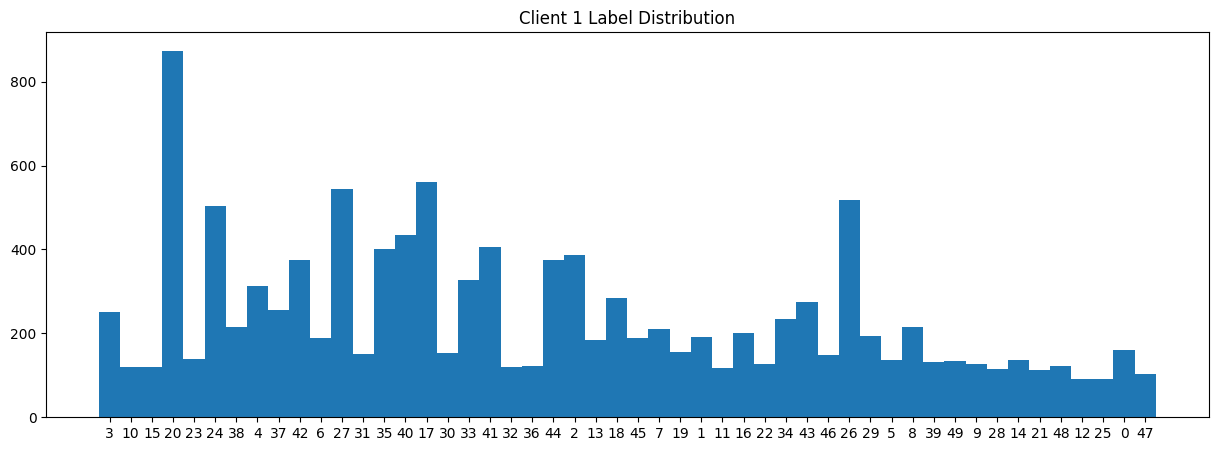

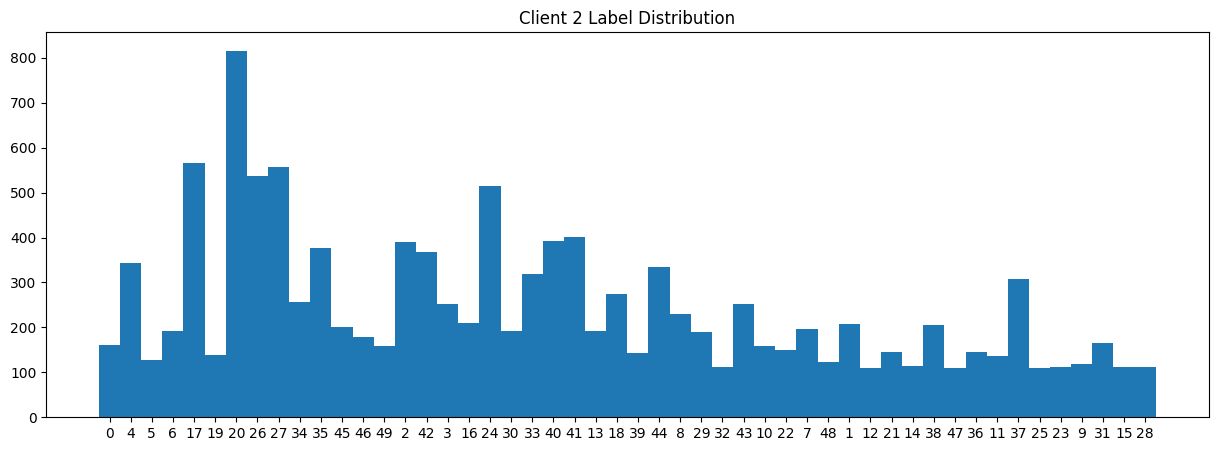

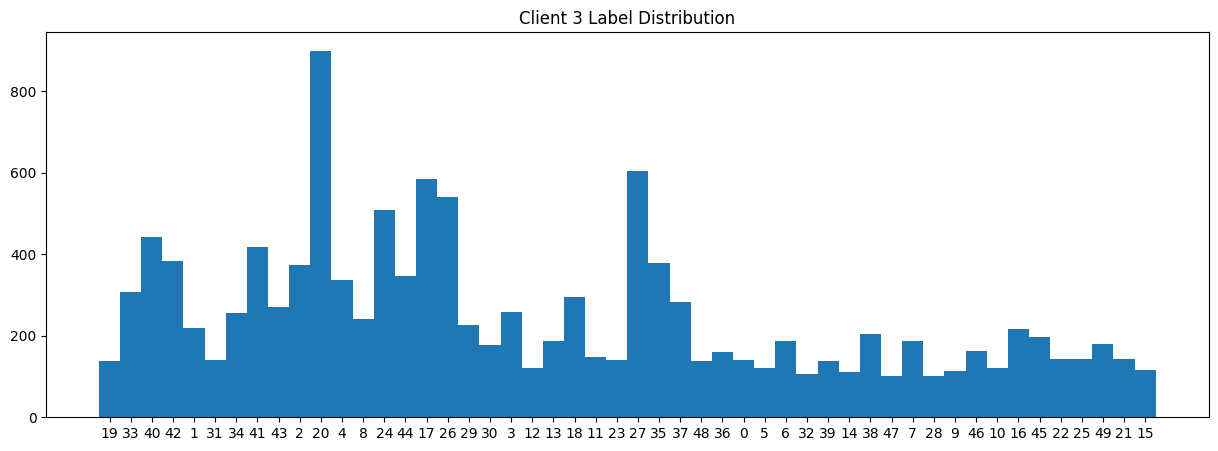

In [12]:
# Client data partitioning

# Load full training data
X_train = torch.load(os.path.join("..", "Data", "X_train.pt"))
Y_train = torch.load(os.path.join("..", "Data", "Y_train.pt"))
train_dataset = TensorDataset(X_train, Y_train)

# Split dataset into three clients
c1, c2, c3 = random_split(train_dataset, lengths=[0.33, 0.33, 0.34])
c_loaders = [
    DataLoader(c, batch_size=config["batch_size"], shuffle=True)
    for c in [c1, c2, c3]
]

# Display data distribution
print(f"Global train size: {train_dataset.tensors[1].shape}")
for i, c in enumerate([c1, c2, c3], start=1):
    print(f"Client {i} size: {Y_train[c.indices].shape}")

# Plot label distributions for each client
for idx, c in enumerate([c1, c2, c3]):
    all_codes = [code for instance in Y_train[c.indices]
                 for code in torch.where(instance > 0)[0].tolist()]
    counts = Counter(all_codes)
    labels, values = zip(*counts.items())

    plt.figure(figsize=(15, 5))
    plt.title(f"Client {idx + 1} Label Distribution")
    plt.bar(range(len(labels)), values, 1)
    plt.xticks(range(len(labels)), labels)
    plt.show()

In [13]:
# Model intialization

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Global_Model = GenerateModel(
    table_path=model_param_path,
    num_of_filters=config["n_filters"],
    kernel_size=config["window_size"]
).to(device)

client = GenerateModel(
    table_path=model_param_path,
    num_of_filters=config["n_filters"],
    kernel_size=config["window_size"]
).to(device)

val_loader = load_data(split="val")

# ---- Optional but recommended: bias init for fairness ----
n_labels = val_loader.dataset[0][1].shape[0]
pos_weight = compute_pos_weight(train_loader, n_labels).to(device)

with torch.no_grad():
    p = pos_weight / (pos_weight + 1.0)
    prior_logit = torch.log(p / (1 - p))
    Global_Model.final.bias.copy_(prior_logit.clamp(-10, 10))
    client.final.bias.copy_(prior_logit.clamp(-10, 10))  # for symmetry

Using device: cuda


In [14]:
# Auto tuning to find best threshold

@torch.no_grad()
def find_best_threshold(model: nn.Module, data_loader: DataLoader, device: torch.device):
    """
    Sweeps multiple thresholds on the validation set to find the one 
    that maximizes F1_micro.

    Returns:
        tuple (best_f1, best_threshold)
    """
    model.eval()
    all_pred_raw = torch.empty(0, dtype=torch.float32, device=device)
    all_labels = torch.empty(0, dtype=torch.float32, device=device)

    for X_batch, y_batch in data_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        preds, _ = model(X_batch)
        all_pred_raw = torch.cat([all_pred_raw, preds], dim=0)
        all_labels = torch.cat([all_labels, y_batch], dim=0)

    best_f1, best_thr = 0.0, 0.1
    for t in [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]:
        preds_t = (torch.sigmoid(all_pred_raw) >= t).long()
        m = all_metrics(
            yhat=preds_t.cpu().numpy(),
            y=all_labels.cpu().numpy(),
            yhat_raw=all_pred_raw.cpu().numpy()
        )
        if m["f1_micro"] > best_f1:
            best_f1, best_thr = m["f1_micro"], t

    return best_f1, best_thr


In [ ]:
@torch.no_grad()
def eval_model(model: nn.Module, device: torch.device, data_loader: DataLoader, tune_threshold=False, fixed_thr=0.3, sigmoid=False):
    """
    Evaluate model performance on a given dataset using BCEWithLogitsLoss.
    Supports both fixed and dynamic (tuned) threshold evaluation.
    """
    model.eval()
    model.to(device)

    loss_fn = nn.BCEWithLogitsLoss()
    all_pred_raw = torch.empty(0, dtype=torch.float32, device=device)
    all_labels = torch.empty(0, dtype=torch.float32, device=device)
    total_loss = 0.0

    # ---- Forward pass ----
    for X_batch, y_batch in data_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        preds, _ = model(X_batch)
        loss = loss_fn(preds, y_batch)
        total_loss += loss.item()

        all_pred_raw = torch.cat([all_pred_raw, preds], dim=0)
        all_labels = torch.cat([all_labels, y_batch], dim=0)

    avg_loss = total_loss / len(data_loader)

    # ---- Diagnostics: logit + sigmoid range ----
    logit_min, logit_max = all_pred_raw.min().item(), all_pred_raw.max().item()
    sigmoid_vals = torch.sigmoid(all_pred_raw)
    print(f"[Eval Debug] Logit range: {logit_min:.2f} to {logit_max:.2f} | "
          f"Sigmoid mean={sigmoid_vals.mean():.3f}, std={sigmoid_vals.std():.3f}")

    # Optional visualization (uncomment if needed)
    if sigmoid:
        plt.hist(sigmoid_vals.cpu().numpy().flatten(), bins=50)
        plt.title("Sigmoid Output Distribution")
        plt.xlabel("Predicted Probability")
        plt.ylabel("Count")
        plt.show()

    # ---- Fixed threshold predictions ----
    pred_labels = (sigmoid_vals >= fixed_thr).long()
    metrics = all_metrics(
        yhat=pred_labels.cpu().numpy(),
        y=all_labels.cpu().numpy(),
        yhat_raw=all_pred_raw.cpu().numpy()
    )

    # ---- Optionally find best threshold ----
    best_f1, best_thr = metrics["f1_micro"], fixed_thr
    if tune_threshold:
        best_f1, best_thr = find_best_threshold(model, data_loader, device)

    # ---- Avg predicted labels per sample ----
    avg_pred_labels = pred_labels.sum(dim=1).float().mean().item()

    # ---- Print evaluation summary ----
    print(f"[Eval] Avg loss={avg_loss:.4f} | F1_micro={metrics['f1_micro']:.4f} | "
          f"Best_F1={best_f1:.4f} @ thr={best_thr:.2f} | "
          f"Avg labels/sample={avg_pred_labels:.2f}")

    # ---- Store for history ----
    metrics["best_f1_micro"] = best_f1
    metrics["best_thr"] = best_thr

    return avg_loss, metrics


In [16]:
# Federated history setup

history = {
    "local_loss": {0: [], 1: [], 2: []},
    "global_loss": [],
    "global_metrics": []
}

max_auc_macro = 0.0
max_f1_micro = 0.0

  0%|          | 0/100 [00:00<?, ?it/s]

[Eval Debug] Logit range: -1.84 to 2.21 | Sigmoid mean=0.499, std=0.071


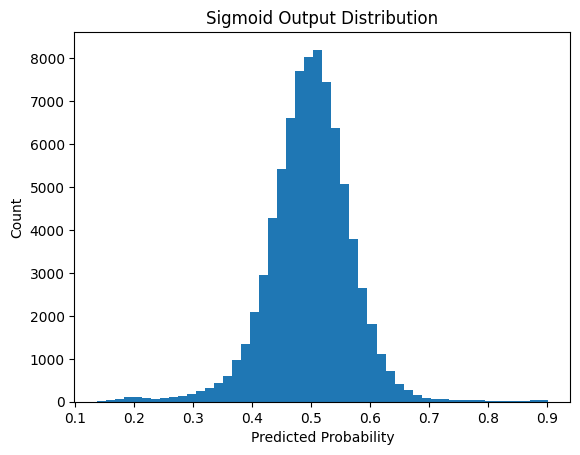

[Eval] Avg loss=0.6885 | F1_micro=0.2069 | Best_F1=0.2069 @ thr=0.30 | Avg labels/sample=49.41


  1%|          | 1/100 [00:12<21:01, 12.74s/it]

Round 1/100 | Avg Local Loss: 1.1243 | Global Val Loss: 0.6885 | F1_micro: 0.2069 | Best_F1: 0.2069 (thr=0.30)
[Eval Debug] Logit range: -3.43 to 2.27 | Sigmoid mean=0.452, std=0.139


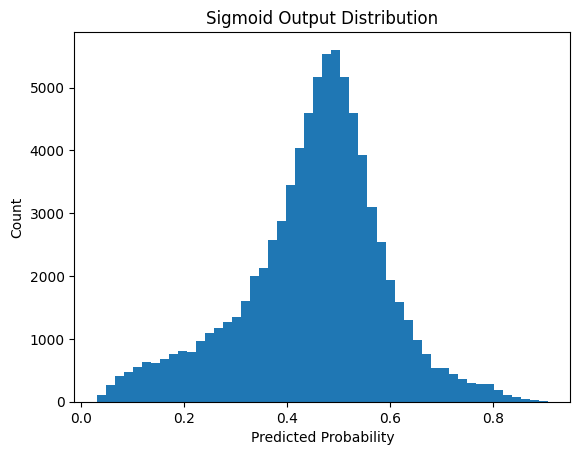

[Eval] Avg loss=0.6087 | F1_micro=0.2309 | Best_F1=0.2309 @ thr=0.30 | Avg labels/sample=43.15


  2%|▏         | 2/100 [00:23<18:50, 11.53s/it]

Round 2/100 | Avg Local Loss: 1.0599 | Global Val Loss: 0.6087 | F1_micro: 0.2309 | Best_F1: 0.2309 (thr=0.30)
[Eval Debug] Logit range: -5.57 to 3.70 | Sigmoid mean=0.440, std=0.204


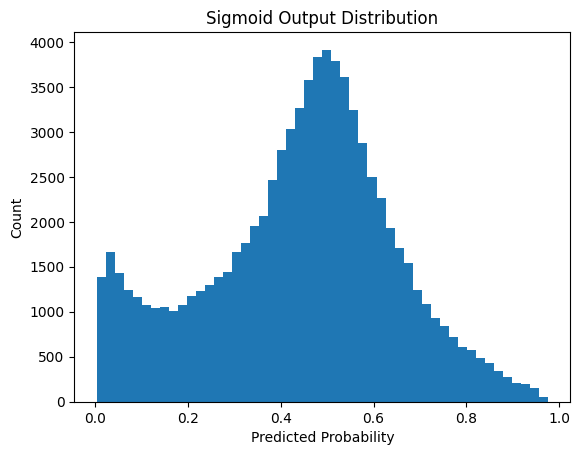

[Eval] Avg loss=0.5958 | F1_micro=0.2536 | Best_F1=0.2536 @ thr=0.30 | Avg labels/sample=38.17


  3%|▎         | 3/100 [00:34<18:00, 11.14s/it]

Round 3/100 | Avg Local Loss: 1.0057 | Global Val Loss: 0.5958 | F1_micro: 0.2536 | Best_F1: 0.2536 (thr=0.30)
[Eval Debug] Logit range: -6.61 to 4.69 | Sigmoid mean=0.411, std=0.234


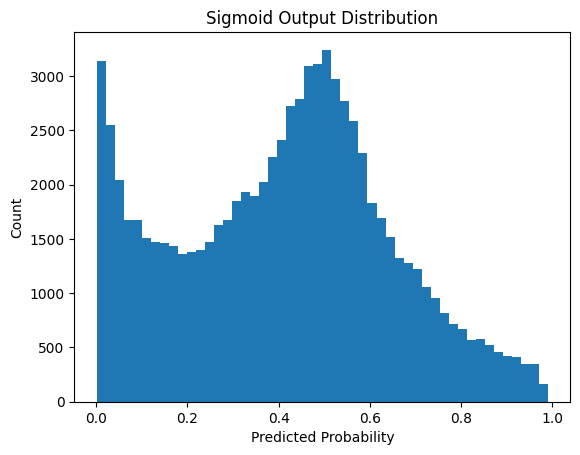

[Eval] Avg loss=0.5549 | F1_micro=0.2773 | Best_F1=0.2773 @ thr=0.30 | Avg labels/sample=33.87


  4%|▍         | 4/100 [00:44<17:33, 10.97s/it]

Round 4/100 | Avg Local Loss: 1.0050 | Global Val Loss: 0.5549 | F1_micro: 0.2773 | Best_F1: 0.2773 (thr=0.30)
[Eval Debug] Logit range: -7.65 to 5.28 | Sigmoid mean=0.381, std=0.255


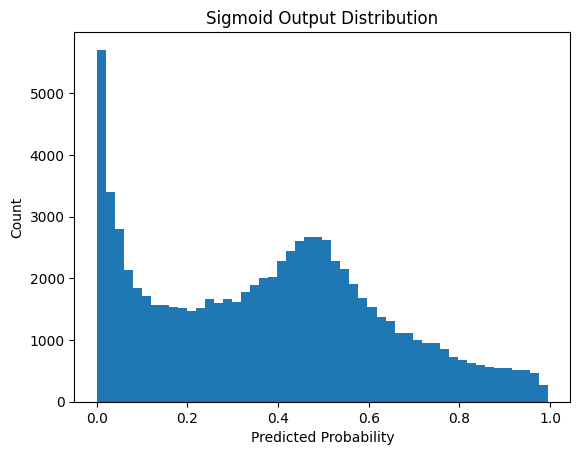

[Eval] Avg loss=0.5145 | F1_micro=0.3009 | Best_F1=0.3009 @ thr=0.30 | Avg labels/sample=30.28


  5%|▌         | 5/100 [00:55<17:11, 10.86s/it]

Round 5/100 | Avg Local Loss: 0.9926 | Global Val Loss: 0.5145 | F1_micro: 0.3009 | Best_F1: 0.3009 (thr=0.30)
[Eval Debug] Logit range: -8.19 to 6.03 | Sigmoid mean=0.398, std=0.278


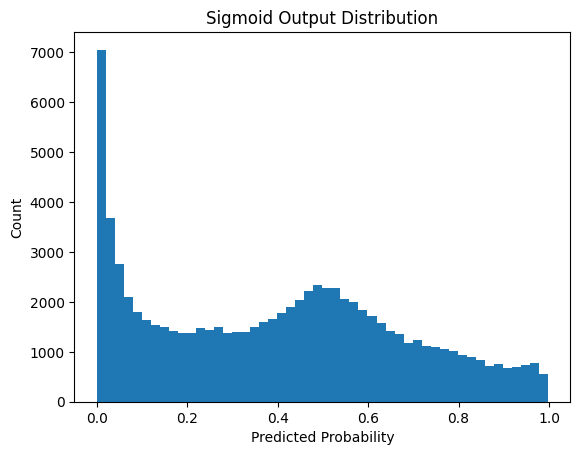

[Eval] Avg loss=0.5486 | F1_micro=0.3046 | Best_F1=0.3046 @ thr=0.30 | Avg labels/sample=30.14


  6%|▌         | 6/100 [01:06<16:56, 10.81s/it]

Round 6/100 | Avg Local Loss: 0.9421 | Global Val Loss: 0.5486 | F1_micro: 0.3046 | Best_F1: 0.3046 (thr=0.30)
[Eval Debug] Logit range: -8.54 to 6.46 | Sigmoid mean=0.379, std=0.285


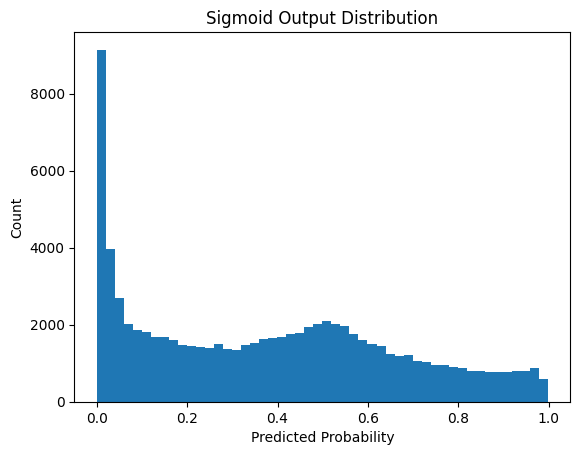

[Eval] Avg loss=0.5242 | F1_micro=0.3184 | Best_F1=0.3184 @ thr=0.30 | Avg labels/sample=28.27


  7%|▋         | 7/100 [01:16<16:44, 10.80s/it]

Round 7/100 | Avg Local Loss: 0.8193 | Global Val Loss: 0.5242 | F1_micro: 0.3184 | Best_F1: 0.3184 (thr=0.30)
[Eval Debug] Logit range: -9.68 to 6.69 | Sigmoid mean=0.363, std=0.291


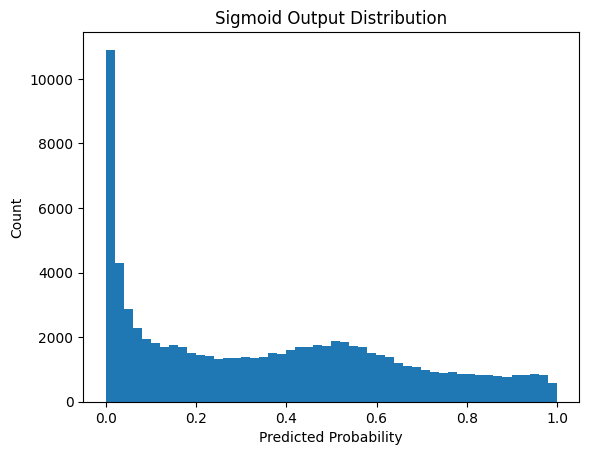

[Eval] Avg loss=0.5000 | F1_micro=0.3307 | Best_F1=0.3307 @ thr=0.30 | Avg labels/sample=26.63


  8%|▊         | 8/100 [01:27<16:35, 10.82s/it]

Round 8/100 | Avg Local Loss: 0.9259 | Global Val Loss: 0.5000 | F1_micro: 0.3307 | Best_F1: 0.3307 (thr=0.30)
[Eval Debug] Logit range: -11.03 to 7.07 | Sigmoid mean=0.364, std=0.300


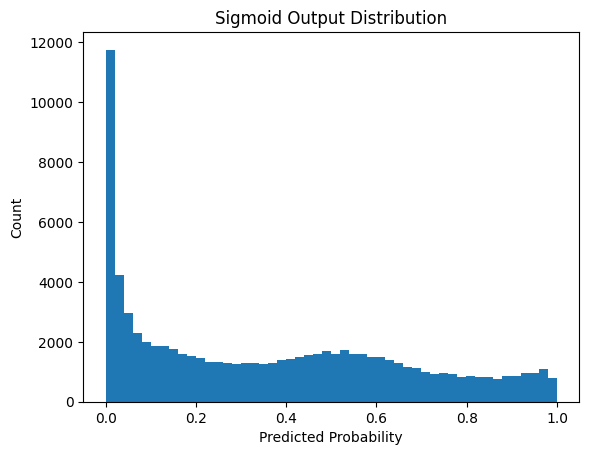

[Eval] Avg loss=0.5092 | F1_micro=0.3356 | Best_F1=0.3356 @ thr=0.30 | Avg labels/sample=26.12


  9%|▉         | 9/100 [01:38<16:22, 10.80s/it]

Round 9/100 | Avg Local Loss: 0.8023 | Global Val Loss: 0.5092 | F1_micro: 0.3356 | Best_F1: 0.3356 (thr=0.30)
[Eval Debug] Logit range: -10.96 to 7.55 | Sigmoid mean=0.351, std=0.301


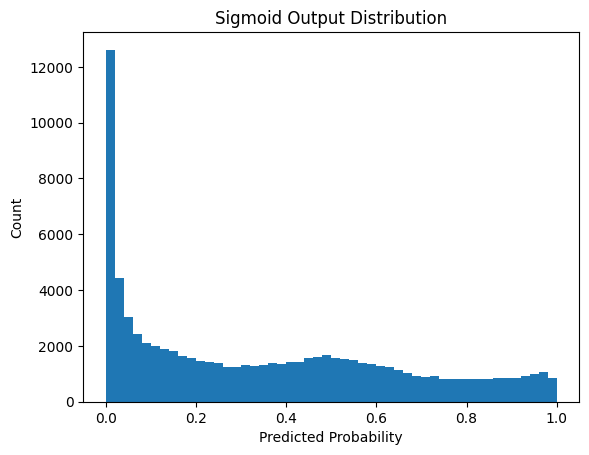

[Eval] Avg loss=0.4874 | F1_micro=0.3460 | Best_F1=0.3460 @ thr=0.30 | Avg labels/sample=25.04


 10%|█         | 10/100 [01:49<16:12, 10.81s/it]

Round 10/100 | Avg Local Loss: 0.8200 | Global Val Loss: 0.4874 | F1_micro: 0.3460 | Best_F1: 0.3460 (thr=0.30)
[Eval Debug] Logit range: -10.70 to 8.37 | Sigmoid mean=0.344, std=0.303


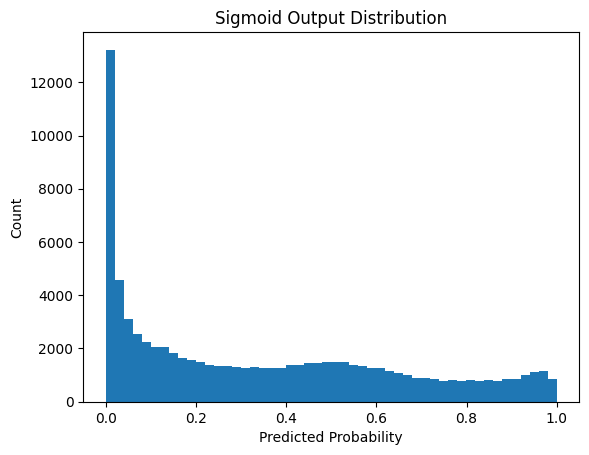

[Eval] Avg loss=0.4792 | F1_micro=0.3555 | Best_F1=0.3555 @ thr=0.30 | Avg labels/sample=24.16


 11%|█         | 11/100 [02:00<16:03, 10.82s/it]

Round 11/100 | Avg Local Loss: 0.7917 | Global Val Loss: 0.4792 | F1_micro: 0.3555 | Best_F1: 0.3555 (thr=0.30)
[Eval Debug] Logit range: -10.80 to 8.02 | Sigmoid mean=0.333, std=0.305


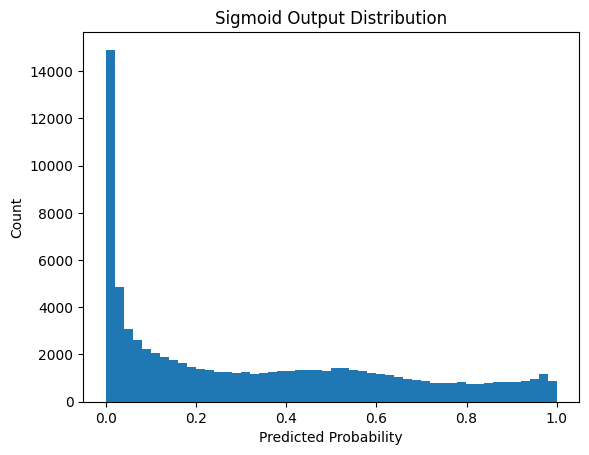

[Eval] Avg loss=0.4648 | F1_micro=0.3624 | Best_F1=0.3624 @ thr=0.30 | Avg labels/sample=23.34


 12%|█▏        | 12/100 [02:11<15:53, 10.83s/it]

Round 12/100 | Avg Local Loss: 0.7267 | Global Val Loss: 0.4648 | F1_micro: 0.3624 | Best_F1: 0.3624 (thr=0.30)
[Eval Debug] Logit range: -11.67 to 8.51 | Sigmoid mean=0.336, std=0.309


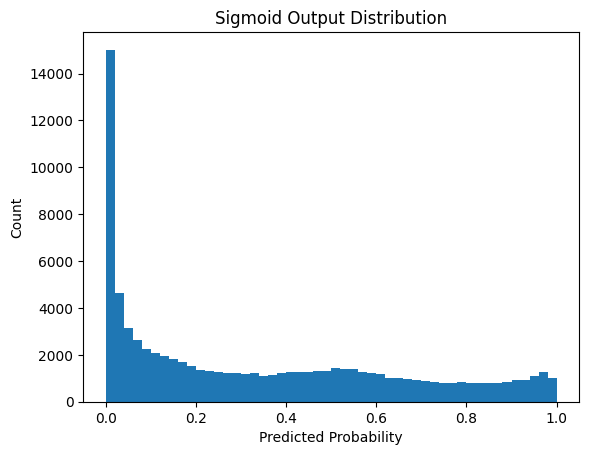

[Eval] Avg loss=0.4710 | F1_micro=0.3643 | Best_F1=0.3643 @ thr=0.30 | Avg labels/sample=23.25


 13%|█▎        | 13/100 [02:21<15:41, 10.82s/it]

Round 13/100 | Avg Local Loss: 0.7810 | Global Val Loss: 0.4710 | F1_micro: 0.3643 | Best_F1: 0.3643 (thr=0.30)
[Eval Debug] Logit range: -11.96 to 9.56 | Sigmoid mean=0.343, std=0.314


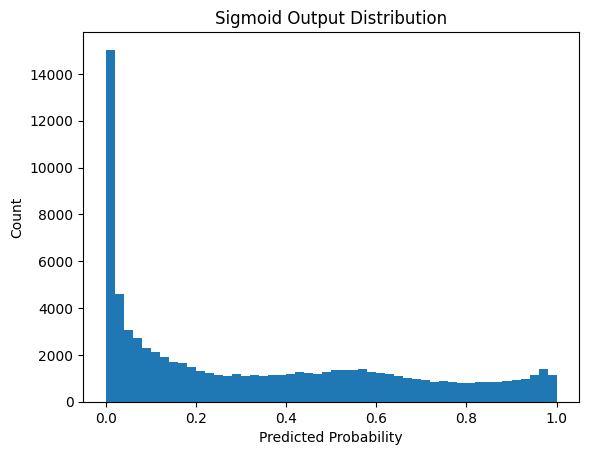

[Eval] Avg loss=0.4858 | F1_micro=0.3613 | Best_F1=0.3613 @ thr=0.30 | Avg labels/sample=23.62


 14%|█▍        | 14/100 [02:32<15:28, 10.80s/it]

Round 14/100 | Avg Local Loss: 0.8149 | Global Val Loss: 0.4858 | F1_micro: 0.3613 | Best_F1: 0.3613 (thr=0.30)
[Eval Debug] Logit range: -11.72 to 9.62 | Sigmoid mean=0.326, std=0.311


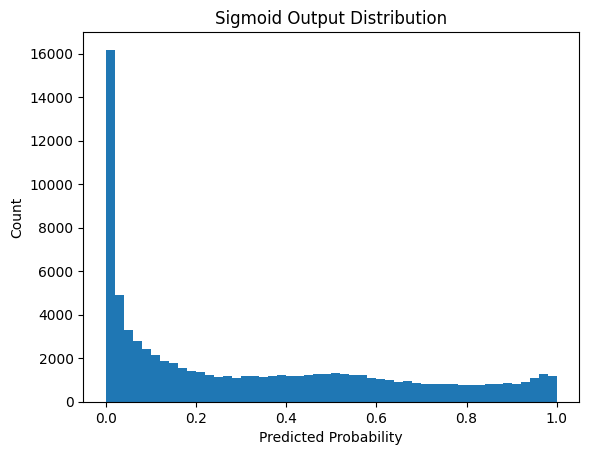

[Eval] Avg loss=0.4623 | F1_micro=0.3715 | Best_F1=0.3715 @ thr=0.30 | Avg labels/sample=22.48


 15%|█▌        | 15/100 [02:43<15:17, 10.79s/it]

Round 15/100 | Avg Local Loss: 0.7548 | Global Val Loss: 0.4623 | F1_micro: 0.3715 | Best_F1: 0.3715 (thr=0.30)
[Eval Debug] Logit range: -11.59 to 9.56 | Sigmoid mean=0.333, std=0.315


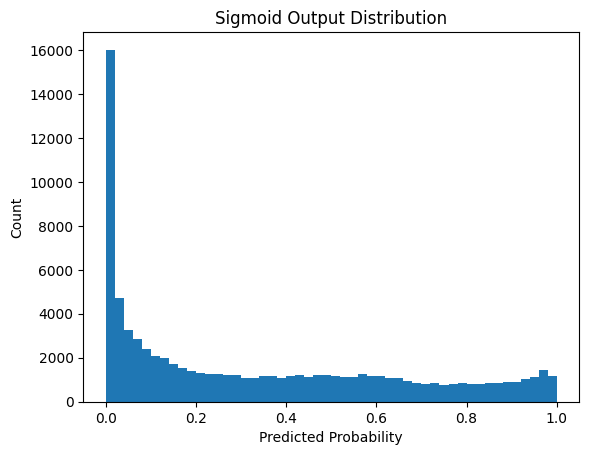

 16%|█▌        | 16/100 [02:54<15:07, 10.80s/it]

[Eval] Avg loss=0.4703 | F1_micro=0.3710 | Best_F1=0.3710 @ thr=0.30 | Avg labels/sample=22.61
Round 16/100 | Avg Local Loss: 0.8633 | Global Val Loss: 0.4703 | F1_micro: 0.3710 | Best_F1: 0.3710 (thr=0.30)
[Eval Debug] Logit range: -12.29 to 9.49 | Sigmoid mean=0.324, std=0.315


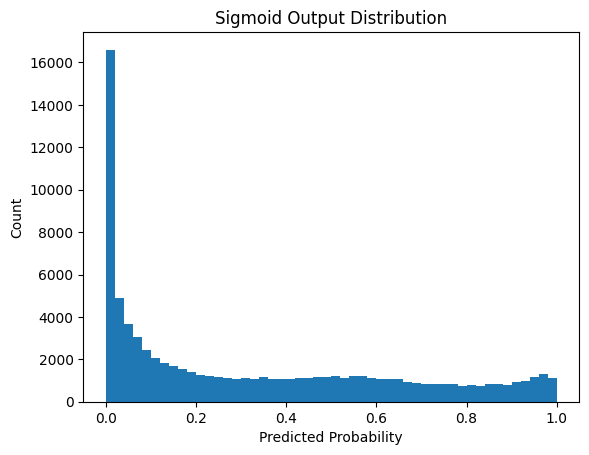

[Eval] Avg loss=0.4576 | F1_micro=0.3765 | Best_F1=0.3765 @ thr=0.30 | Avg labels/sample=22.05


 17%|█▋        | 17/100 [03:05<15:07, 10.93s/it]

Round 17/100 | Avg Local Loss: 0.6687 | Global Val Loss: 0.4576 | F1_micro: 0.3765 | Best_F1: 0.3765 (thr=0.30)
[Eval Debug] Logit range: -12.85 to 10.30 | Sigmoid mean=0.321, std=0.315


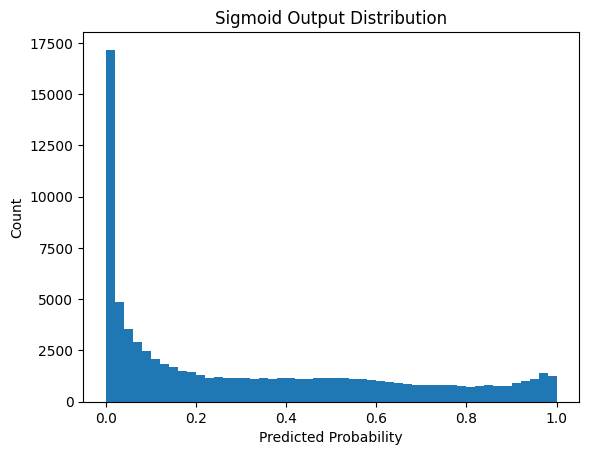

[Eval] Avg loss=0.4573 | F1_micro=0.3792 | Best_F1=0.3792 @ thr=0.30 | Avg labels/sample=21.78


 18%|█▊        | 18/100 [03:17<15:12, 11.13s/it]

Round 18/100 | Avg Local Loss: 0.7559 | Global Val Loss: 0.4573 | F1_micro: 0.3792 | Best_F1: 0.3792 (thr=0.30)
[Eval Debug] Logit range: -12.63 to 10.98 | Sigmoid mean=0.326, std=0.317


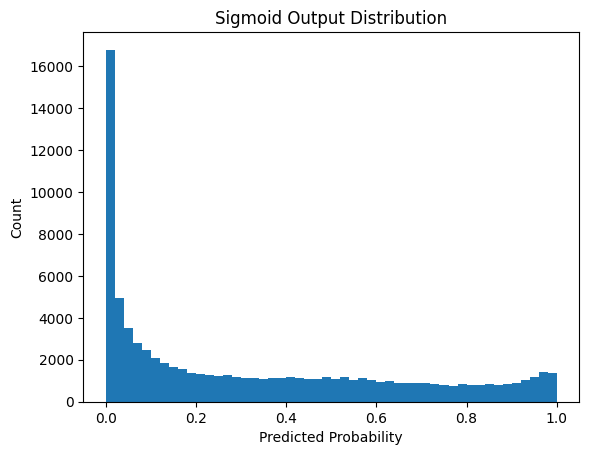

[Eval] Avg loss=0.4640 | F1_micro=0.3793 | Best_F1=0.3793 @ thr=0.30 | Avg labels/sample=21.95


 19%|█▉        | 19/100 [03:28<15:00, 11.12s/it]

Round 19/100 | Avg Local Loss: 0.7379 | Global Val Loss: 0.4640 | F1_micro: 0.3793 | Best_F1: 0.3793 (thr=0.30)
[Eval Debug] Logit range: -13.69 to 10.36 | Sigmoid mean=0.316, std=0.318


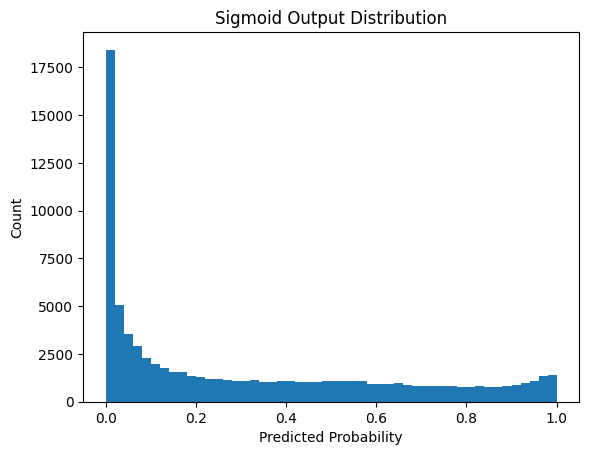

[Eval] Avg loss=0.4511 | F1_micro=0.3859 | Best_F1=0.3859 @ thr=0.30 | Avg labels/sample=21.24


 20%|██        | 20/100 [03:39<14:51, 11.14s/it]

Round 20/100 | Avg Local Loss: 0.7780 | Global Val Loss: 0.4511 | F1_micro: 0.3859 | Best_F1: 0.3859 (thr=0.30)
[Eval Debug] Logit range: -12.98 to 10.06 | Sigmoid mean=0.312, std=0.317


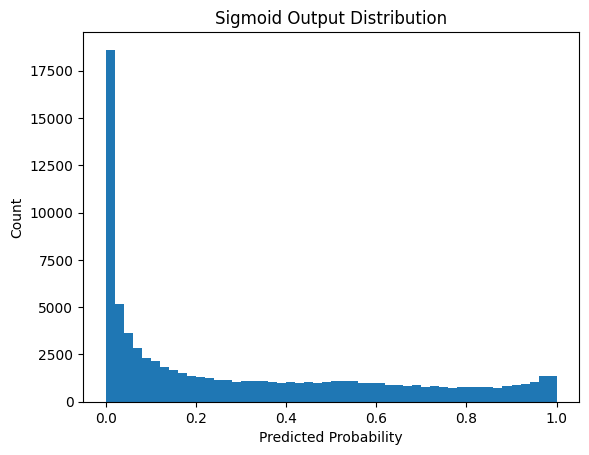

[Eval] Avg loss=0.4437 | F1_micro=0.3897 | Best_F1=0.3897 @ thr=0.30 | Avg labels/sample=20.91


 21%|██        | 21/100 [03:50<14:42, 11.16s/it]

Round 21/100 | Avg Local Loss: 0.8550 | Global Val Loss: 0.4437 | F1_micro: 0.3897 | Best_F1: 0.3897 (thr=0.30)
[Eval Debug] Logit range: -14.40 to 10.88 | Sigmoid mean=0.322, std=0.320


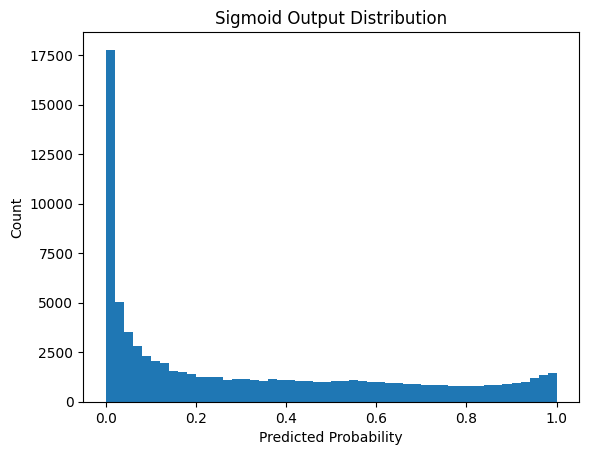

 22%|██▏       | 22/100 [04:01<14:24, 11.08s/it]

[Eval] Avg loss=0.4572 | F1_micro=0.3829 | Best_F1=0.3829 @ thr=0.30 | Avg labels/sample=21.56
Round 22/100 | Avg Local Loss: 0.7456 | Global Val Loss: 0.4572 | F1_micro: 0.3829 | Best_F1: 0.3829 (thr=0.30)
[Eval Debug] Logit range: -14.01 to 10.59 | Sigmoid mean=0.321, std=0.323


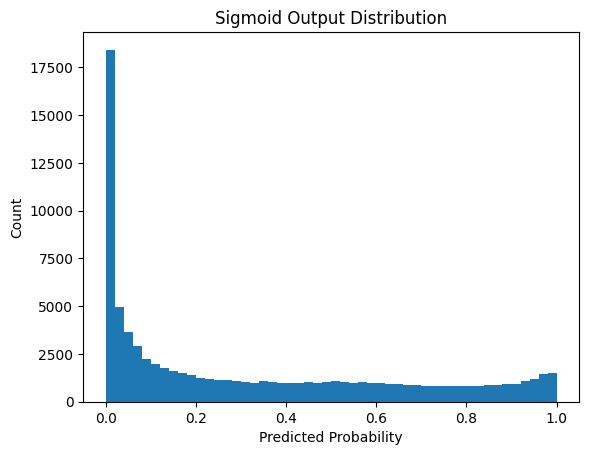

 23%|██▎       | 23/100 [04:12<14:09, 11.03s/it]

[Eval] Avg loss=0.4604 | F1_micro=0.3864 | Best_F1=0.3864 @ thr=0.30 | Avg labels/sample=21.35
Round 23/100 | Avg Local Loss: 0.7125 | Global Val Loss: 0.4604 | F1_micro: 0.3864 | Best_F1: 0.3864 (thr=0.30)
[Eval Debug] Logit range: -13.55 to 10.78 | Sigmoid mean=0.318, std=0.323


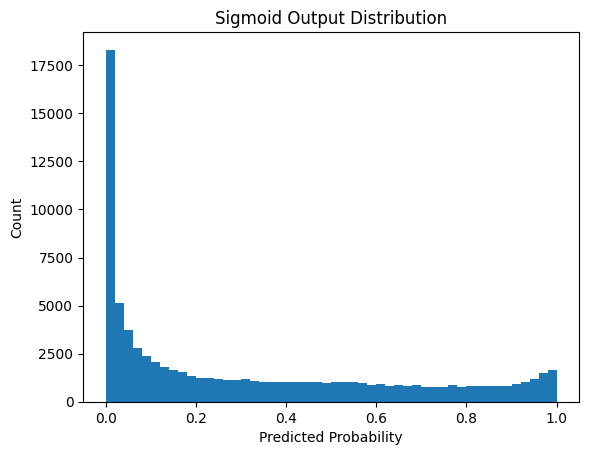

[Eval] Avg loss=0.4569 | F1_micro=0.3903 | Best_F1=0.3903 @ thr=0.30 | Avg labels/sample=21.04


 24%|██▍       | 24/100 [04:23<13:58, 11.03s/it]

Round 24/100 | Avg Local Loss: 0.8161 | Global Val Loss: 0.4569 | F1_micro: 0.3903 | Best_F1: 0.3903 (thr=0.30)
[Eval Debug] Logit range: -14.01 to 11.29 | Sigmoid mean=0.325, std=0.324


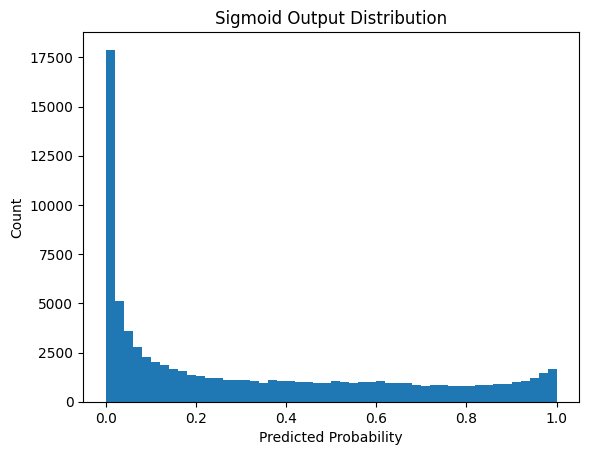

[Eval] Avg loss=0.4685 | F1_micro=0.3846 | Best_F1=0.3846 @ thr=0.30 | Avg labels/sample=21.51


 25%|██▌       | 25/100 [04:34<13:44, 10.99s/it]

Round 25/100 | Avg Local Loss: 0.7848 | Global Val Loss: 0.4685 | F1_micro: 0.3846 | Best_F1: 0.3846 (thr=0.30)
[Eval Debug] Logit range: -13.70 to 11.81 | Sigmoid mean=0.304, std=0.318


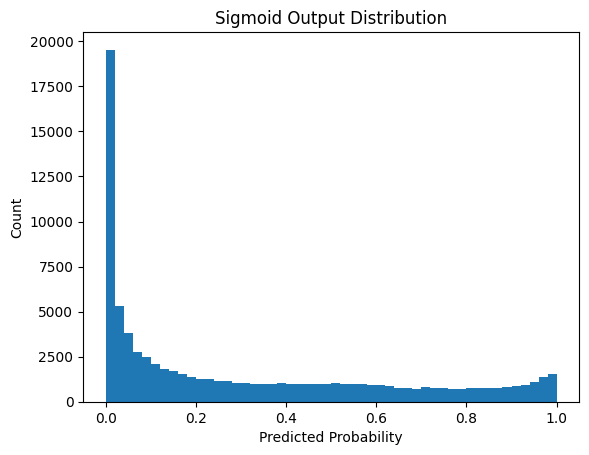

[Eval] Avg loss=0.4328 | F1_micro=0.4011 | Best_F1=0.4011 @ thr=0.30 | Avg labels/sample=20.07


 26%|██▌       | 26/100 [04:45<13:37, 11.04s/it]

Round 26/100 | Avg Local Loss: 0.7455 | Global Val Loss: 0.4328 | F1_micro: 0.4011 | Best_F1: 0.4011 (thr=0.30)
[Eval Debug] Logit range: -13.48 to 11.85 | Sigmoid mean=0.318, std=0.326


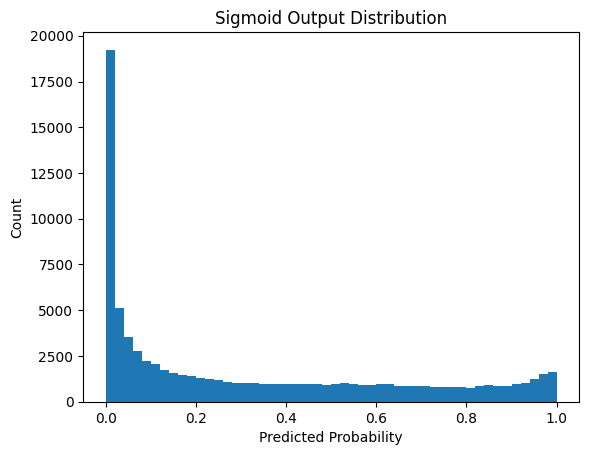

 27%|██▋       | 27/100 [04:56<13:25, 11.04s/it]

[Eval] Avg loss=0.4585 | F1_micro=0.3919 | Best_F1=0.3919 @ thr=0.30 | Avg labels/sample=20.90
Round 27/100 | Avg Local Loss: 0.8215 | Global Val Loss: 0.4585 | F1_micro: 0.3919 | Best_F1: 0.3919 (thr=0.30)
[Eval Debug] Logit range: -14.85 to 10.83 | Sigmoid mean=0.309, std=0.322


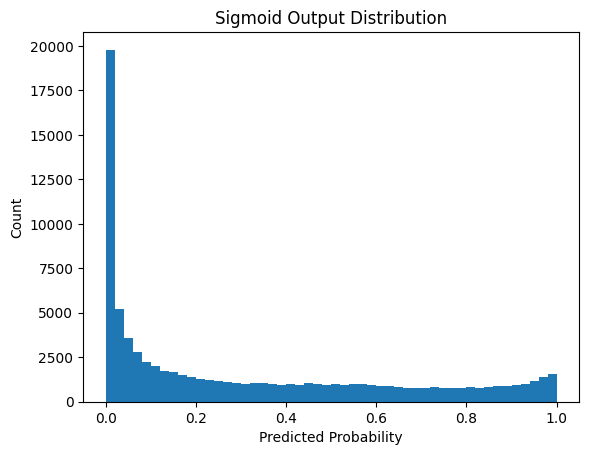

[Eval] Avg loss=0.4406 | F1_micro=0.3976 | Best_F1=0.3976 @ thr=0.30 | Avg labels/sample=20.40


 28%|██▊       | 28/100 [05:07<13:12, 11.01s/it]

Round 28/100 | Avg Local Loss: 0.7645 | Global Val Loss: 0.4406 | F1_micro: 0.3976 | Best_F1: 0.3976 (thr=0.30)
[Eval Debug] Logit range: -14.48 to 11.19 | Sigmoid mean=0.304, std=0.321


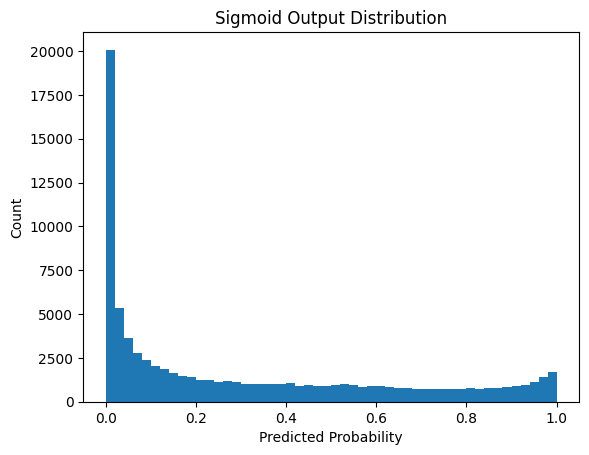

[Eval] Avg loss=0.4360 | F1_micro=0.4036 | Best_F1=0.4036 @ thr=0.30 | Avg labels/sample=19.91


 29%|██▉       | 29/100 [05:18<13:04, 11.04s/it]

Round 29/100 | Avg Local Loss: 0.7705 | Global Val Loss: 0.4360 | F1_micro: 0.4036 | Best_F1: 0.4036 (thr=0.30)
[Eval Debug] Logit range: -14.57 to 10.40 | Sigmoid mean=0.304, std=0.322


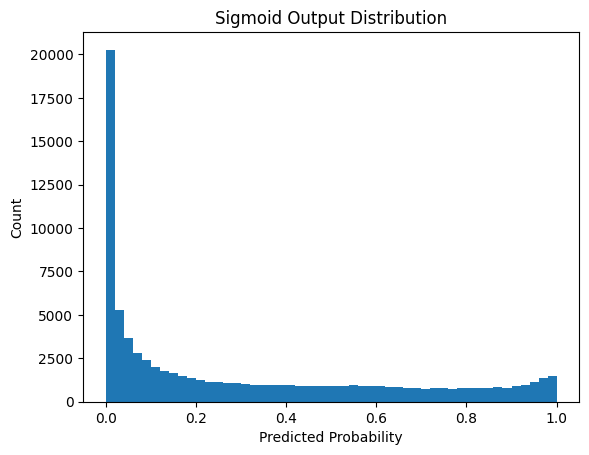

[Eval] Avg loss=0.4343 | F1_micro=0.4031 | Best_F1=0.4031 @ thr=0.30 | Avg labels/sample=19.97


 30%|███       | 30/100 [05:29<12:59, 11.13s/it]

Round 30/100 | Avg Local Loss: 0.7607 | Global Val Loss: 0.4343 | F1_micro: 0.4031 | Best_F1: 0.4031 (thr=0.30)
[Eval Debug] Logit range: -15.57 to 10.92 | Sigmoid mean=0.304, std=0.324


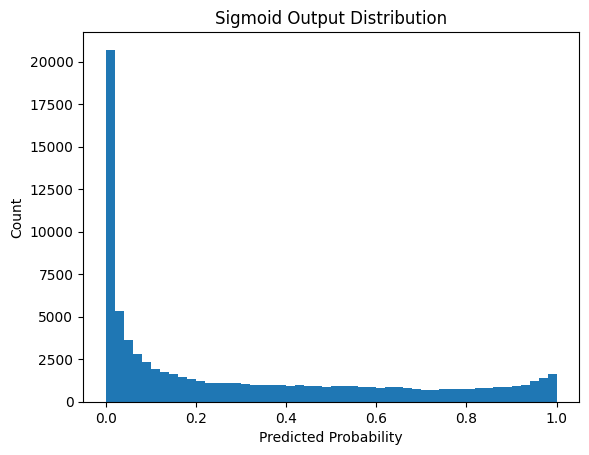

[Eval] Avg loss=0.4344 | F1_micro=0.4053 | Best_F1=0.4053 @ thr=0.30 | Avg labels/sample=19.90


 31%|███       | 31/100 [05:41<13:00, 11.31s/it]

Round 31/100 | Avg Local Loss: 0.7863 | Global Val Loss: 0.4344 | F1_micro: 0.4053 | Best_F1: 0.4053 (thr=0.30)
[Eval Debug] Logit range: -15.74 to 11.79 | Sigmoid mean=0.303, std=0.323


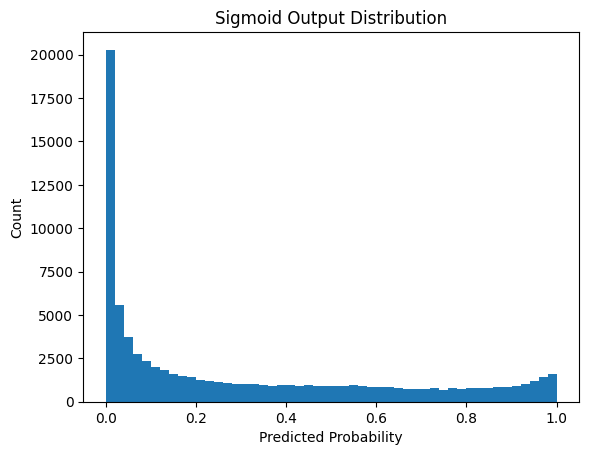

[Eval] Avg loss=0.4356 | F1_micro=0.4060 | Best_F1=0.4060 @ thr=0.30 | Avg labels/sample=19.80


 32%|███▏      | 32/100 [05:53<12:51, 11.35s/it]

Round 32/100 | Avg Local Loss: 0.7454 | Global Val Loss: 0.4356 | F1_micro: 0.4060 | Best_F1: 0.4060 (thr=0.30)
[Eval Debug] Logit range: -14.50 to 11.13 | Sigmoid mean=0.306, std=0.326


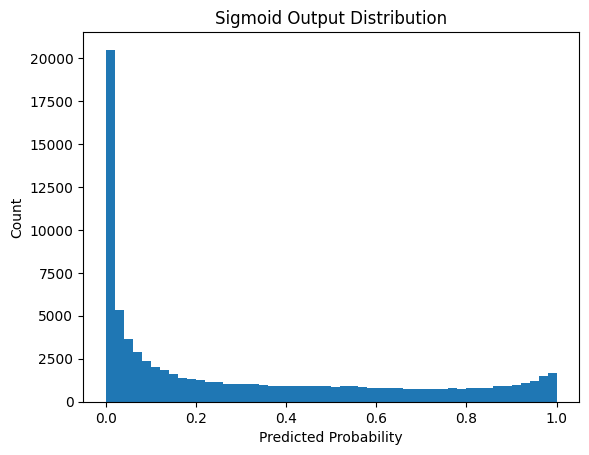

 33%|███▎      | 33/100 [06:04<12:40, 11.36s/it]

[Eval] Avg loss=0.4418 | F1_micro=0.4047 | Best_F1=0.4047 @ thr=0.30 | Avg labels/sample=19.91
Round 33/100 | Avg Local Loss: 0.7512 | Global Val Loss: 0.4418 | F1_micro: 0.4047 | Best_F1: 0.4047 (thr=0.30)
[Eval Debug] Logit range: -14.93 to 10.45 | Sigmoid mean=0.307, std=0.326


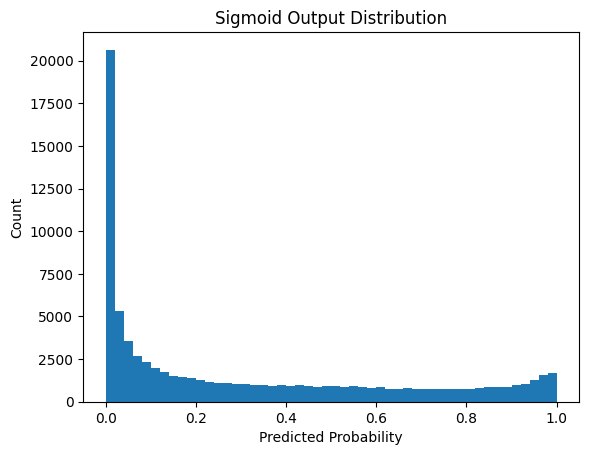

 34%|███▍      | 34/100 [06:15<12:28, 11.33s/it]

[Eval] Avg loss=0.4441 | F1_micro=0.4045 | Best_F1=0.4045 @ thr=0.30 | Avg labels/sample=20.01
Round 34/100 | Avg Local Loss: 0.7386 | Global Val Loss: 0.4441 | F1_micro: 0.4045 | Best_F1: 0.4045 (thr=0.30)
[Eval Debug] Logit range: -15.14 to 10.15 | Sigmoid mean=0.296, std=0.323


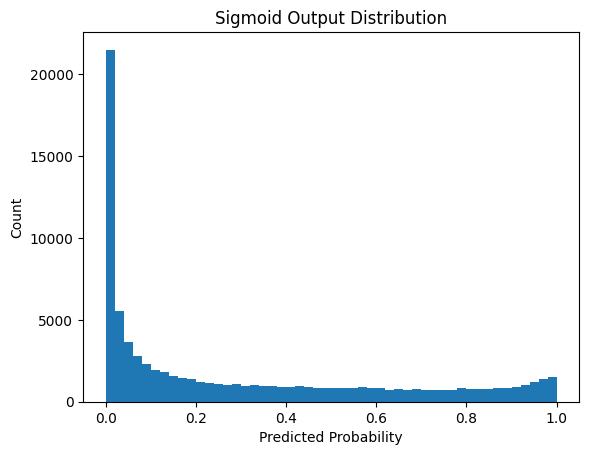

[Eval] Avg loss=0.4224 | F1_micro=0.4133 | Best_F1=0.4133 @ thr=0.30 | Avg labels/sample=19.28


 35%|███▌      | 35/100 [06:27<12:15, 11.31s/it]

Round 35/100 | Avg Local Loss: 0.7549 | Global Val Loss: 0.4224 | F1_micro: 0.4133 | Best_F1: 0.4133 (thr=0.30)
[Eval Debug] Logit range: -14.90 to 10.58 | Sigmoid mean=0.302, std=0.326


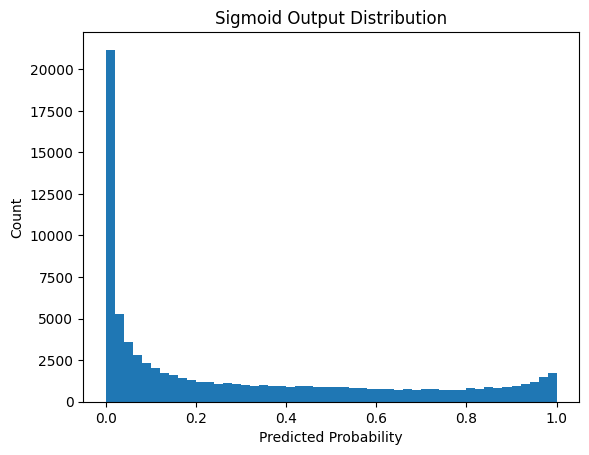

 36%|███▌      | 36/100 [06:37<11:55, 11.18s/it]

[Eval] Avg loss=0.4376 | F1_micro=0.4101 | Best_F1=0.4101 @ thr=0.30 | Avg labels/sample=19.59
Round 36/100 | Avg Local Loss: 0.7990 | Global Val Loss: 0.4376 | F1_micro: 0.4101 | Best_F1: 0.4101 (thr=0.30)
[Eval Debug] Logit range: -14.79 to 11.39 | Sigmoid mean=0.298, std=0.323


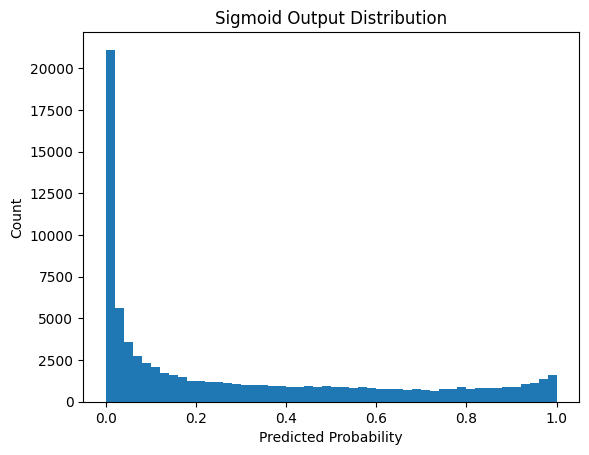

[Eval] Avg loss=0.4260 | F1_micro=0.4130 | Best_F1=0.4130 @ thr=0.30 | Avg labels/sample=19.42


 37%|███▋      | 37/100 [06:48<11:38, 11.09s/it]

Round 37/100 | Avg Local Loss: 0.7426 | Global Val Loss: 0.4260 | F1_micro: 0.4130 | Best_F1: 0.4130 (thr=0.30)
[Eval Debug] Logit range: -14.71 to 11.09 | Sigmoid mean=0.296, std=0.325


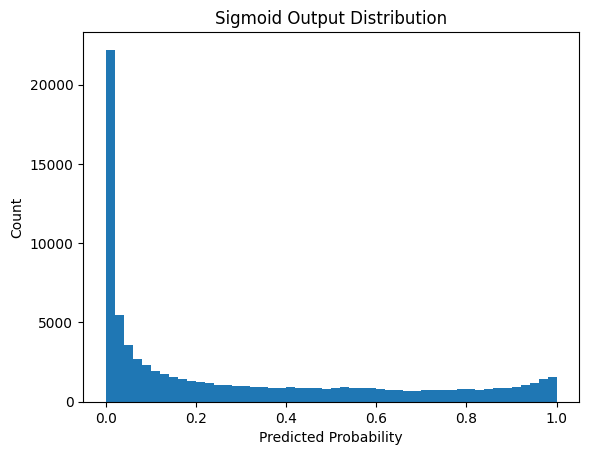

[Eval] Avg loss=0.4246 | F1_micro=0.4141 | Best_F1=0.4141 @ thr=0.30 | Avg labels/sample=19.21


 38%|███▊      | 38/100 [06:59<11:23, 11.02s/it]

Round 38/100 | Avg Local Loss: 0.6644 | Global Val Loss: 0.4246 | F1_micro: 0.4141 | Best_F1: 0.4141 (thr=0.30)
[Eval Debug] Logit range: -14.70 to 11.26 | Sigmoid mean=0.298, std=0.326


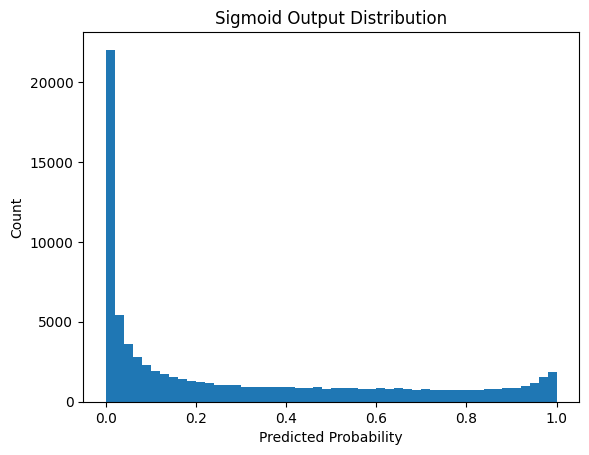

 39%|███▉      | 39/100 [07:10<11:07, 10.94s/it]

[Eval] Avg loss=0.4308 | F1_micro=0.4136 | Best_F1=0.4136 @ thr=0.30 | Avg labels/sample=19.26
Round 39/100 | Avg Local Loss: 0.7211 | Global Val Loss: 0.4308 | F1_micro: 0.4136 | Best_F1: 0.4136 (thr=0.30)
[Eval Debug] Logit range: -15.06 to 11.30 | Sigmoid mean=0.301, std=0.327


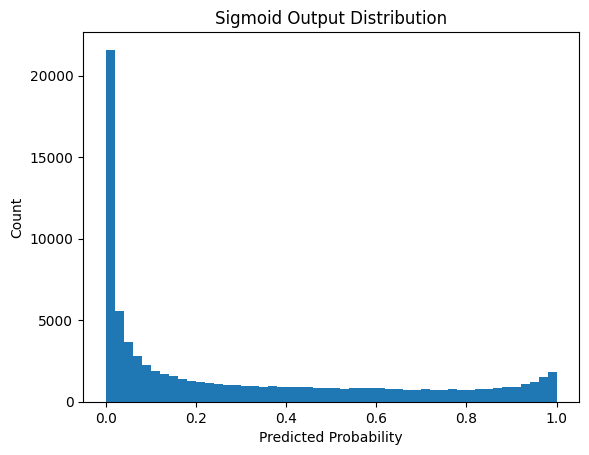

 40%|████      | 40/100 [07:21<10:56, 10.93s/it]

[Eval] Avg loss=0.4349 | F1_micro=0.4104 | Best_F1=0.4104 @ thr=0.30 | Avg labels/sample=19.48
Round 40/100 | Avg Local Loss: 0.7598 | Global Val Loss: 0.4349 | F1_micro: 0.4104 | Best_F1: 0.4104 (thr=0.30)
[Eval Debug] Logit range: -15.62 to 10.93 | Sigmoid mean=0.296, std=0.325


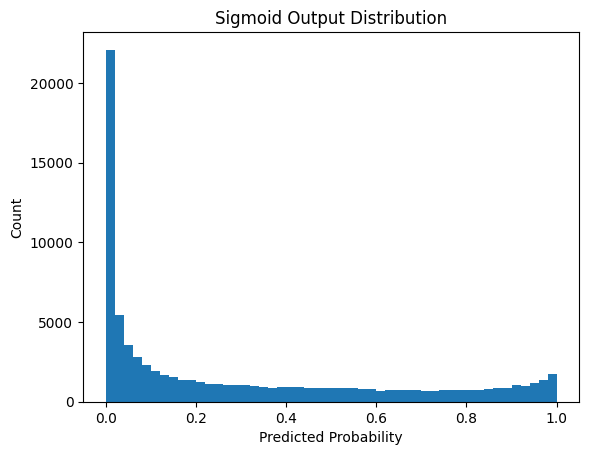

[Eval] Avg loss=0.4253 | F1_micro=0.4144 | Best_F1=0.4144 @ thr=0.30 | Avg labels/sample=19.21


 41%|████      | 41/100 [07:32<10:45, 10.94s/it]

Round 41/100 | Avg Local Loss: 0.7581 | Global Val Loss: 0.4253 | F1_micro: 0.4144 | Best_F1: 0.4144 (thr=0.30)
[Eval Debug] Logit range: -16.36 to 11.14 | Sigmoid mean=0.297, std=0.325


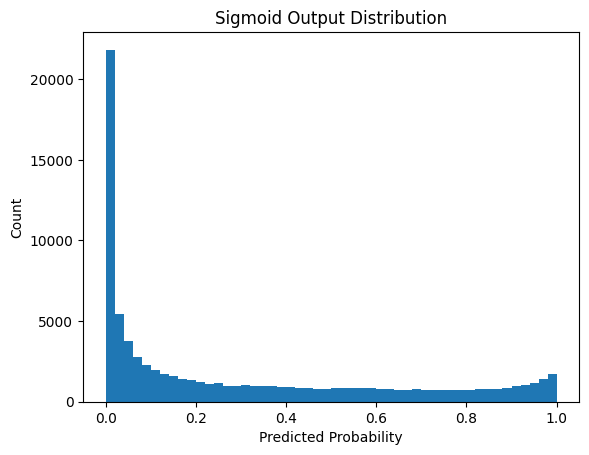

[Eval] Avg loss=0.4269 | F1_micro=0.4129 | Best_F1=0.4129 @ thr=0.30 | Avg labels/sample=19.23


 42%|████▏     | 42/100 [07:43<10:33, 10.91s/it]

Round 42/100 | Avg Local Loss: 0.8028 | Global Val Loss: 0.4269 | F1_micro: 0.4129 | Best_F1: 0.4129 (thr=0.30)
[Eval Debug] Logit range: -16.65 to 12.13 | Sigmoid mean=0.297, std=0.327


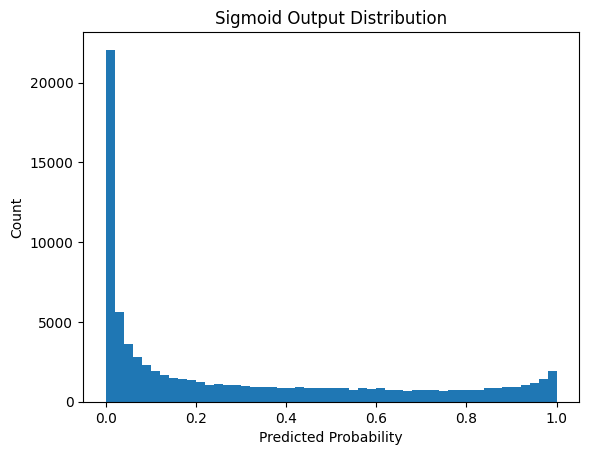

[Eval] Avg loss=0.4323 | F1_micro=0.4159 | Best_F1=0.4159 @ thr=0.30 | Avg labels/sample=19.15


 43%|████▎     | 43/100 [07:53<10:20, 10.88s/it]

Round 43/100 | Avg Local Loss: 0.8630 | Global Val Loss: 0.4323 | F1_micro: 0.4159 | Best_F1: 0.4159 (thr=0.30)
[Eval Debug] Logit range: -16.37 to 11.81 | Sigmoid mean=0.293, std=0.325


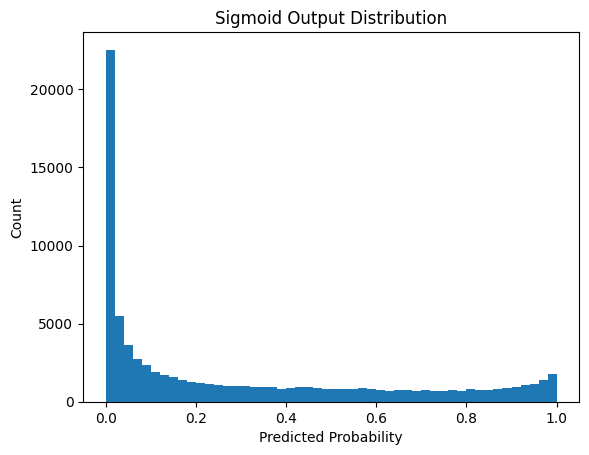

[Eval] Avg loss=0.4221 | F1_micro=0.4180 | Best_F1=0.4180 @ thr=0.30 | Avg labels/sample=18.96


 44%|████▍     | 44/100 [08:04<10:09, 10.89s/it]

Round 44/100 | Avg Local Loss: 0.7217 | Global Val Loss: 0.4221 | F1_micro: 0.4180 | Best_F1: 0.4180 (thr=0.30)
[Eval Debug] Logit range: -16.67 to 11.36 | Sigmoid mean=0.296, std=0.328


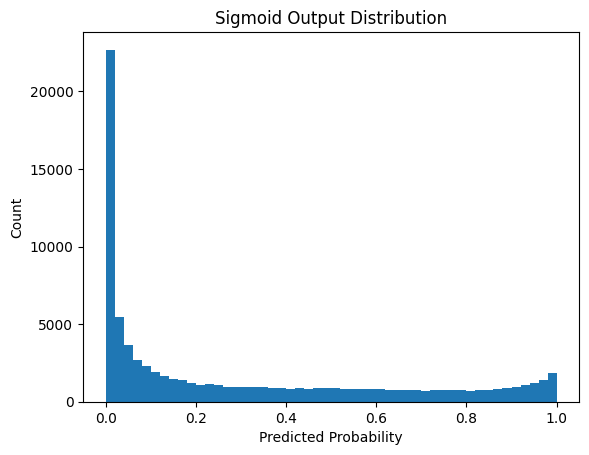

[Eval] Avg loss=0.4300 | F1_micro=0.4140 | Best_F1=0.4140 @ thr=0.30 | Avg labels/sample=19.20


 45%|████▌     | 45/100 [08:15<09:57, 10.87s/it]

Round 45/100 | Avg Local Loss: 0.7380 | Global Val Loss: 0.4300 | F1_micro: 0.4140 | Best_F1: 0.4140 (thr=0.30)
[Eval Debug] Logit range: -16.74 to 11.49 | Sigmoid mean=0.291, std=0.325


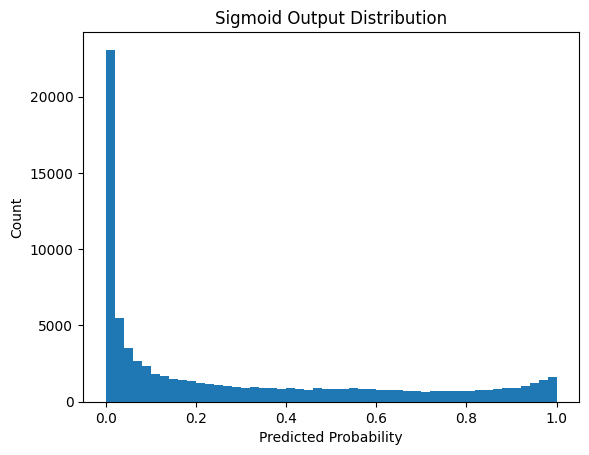

[Eval] Avg loss=0.4164 | F1_micro=0.4209 | Best_F1=0.4209 @ thr=0.30 | Avg labels/sample=18.80


 46%|████▌     | 46/100 [08:26<09:50, 10.93s/it]

Round 46/100 | Avg Local Loss: 0.6685 | Global Val Loss: 0.4164 | F1_micro: 0.4209 | Best_F1: 0.4209 (thr=0.30)
[Eval Debug] Logit range: -16.72 to 11.78 | Sigmoid mean=0.293, std=0.326


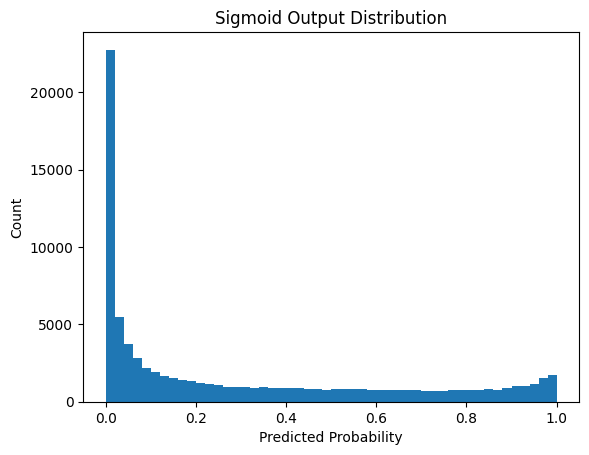

[Eval] Avg loss=0.4226 | F1_micro=0.4187 | Best_F1=0.4187 @ thr=0.30 | Avg labels/sample=18.92


 47%|████▋     | 47/100 [08:37<09:39, 10.94s/it]

Round 47/100 | Avg Local Loss: 0.7754 | Global Val Loss: 0.4226 | F1_micro: 0.4187 | Best_F1: 0.4187 (thr=0.30)
[Eval Debug] Logit range: -16.51 to 11.28 | Sigmoid mean=0.292, std=0.326


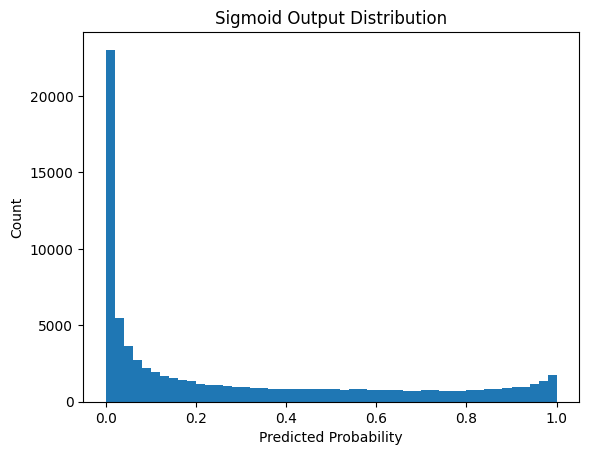

[Eval] Avg loss=0.4217 | F1_micro=0.4211 | Best_F1=0.4211 @ thr=0.30 | Avg labels/sample=18.75


 48%|████▊     | 48/100 [08:48<09:26, 10.90s/it]

Round 48/100 | Avg Local Loss: 0.6451 | Global Val Loss: 0.4217 | F1_micro: 0.4211 | Best_F1: 0.4211 (thr=0.30)
[Eval Debug] Logit range: -16.20 to 10.80 | Sigmoid mean=0.302, std=0.330


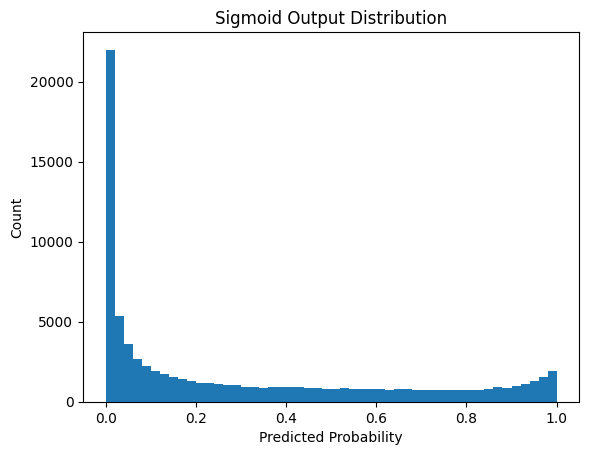

 49%|████▉     | 49/100 [08:59<09:14, 10.87s/it]

[Eval] Avg loss=0.4411 | F1_micro=0.4118 | Best_F1=0.4118 @ thr=0.30 | Avg labels/sample=19.41
Round 49/100 | Avg Local Loss: 0.8004 | Global Val Loss: 0.4411 | F1_micro: 0.4118 | Best_F1: 0.4118 (thr=0.30)
[Eval Debug] Logit range: -15.67 to 11.79 | Sigmoid mean=0.292, std=0.326


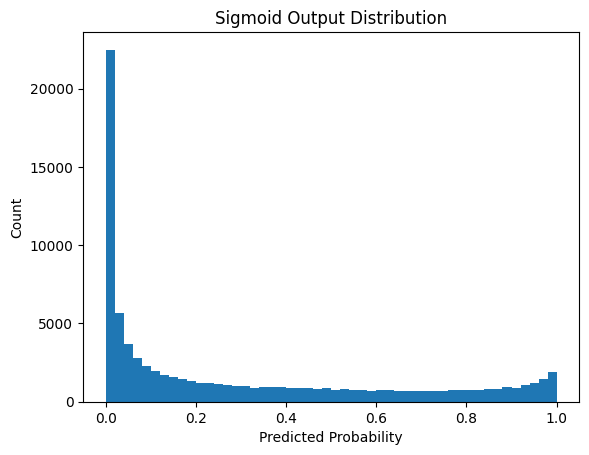

[Eval] Avg loss=0.4237 | F1_micro=0.4201 | Best_F1=0.4201 @ thr=0.30 | Avg labels/sample=18.75


 50%|█████     | 50/100 [09:09<09:00, 10.81s/it]

Round 50/100 | Avg Local Loss: 0.7563 | Global Val Loss: 0.4237 | F1_micro: 0.4201 | Best_F1: 0.4201 (thr=0.30)
[Eval Debug] Logit range: -15.48 to 12.37 | Sigmoid mean=0.293, std=0.327


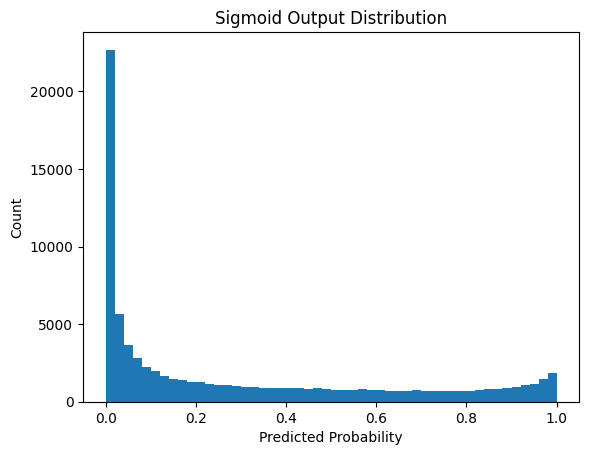

[Eval] Avg loss=0.4257 | F1_micro=0.4212 | Best_F1=0.4212 @ thr=0.30 | Avg labels/sample=18.78


 51%|█████     | 51/100 [09:20<08:49, 10.80s/it]

Round 51/100 | Avg Local Loss: 0.6649 | Global Val Loss: 0.4257 | F1_micro: 0.4212 | Best_F1: 0.4212 (thr=0.30)
[Eval Debug] Logit range: -16.32 to 12.11 | Sigmoid mean=0.293, std=0.329


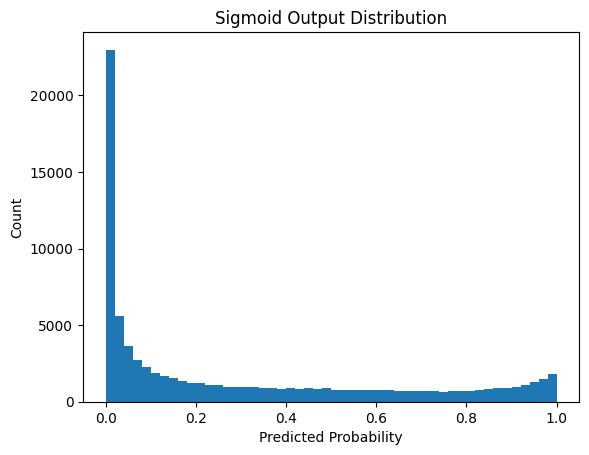

 52%|█████▏    | 52/100 [09:31<08:38, 10.80s/it]

[Eval] Avg loss=0.4256 | F1_micro=0.4215 | Best_F1=0.4215 @ thr=0.30 | Avg labels/sample=18.85
Round 52/100 | Avg Local Loss: 0.7696 | Global Val Loss: 0.4256 | F1_micro: 0.4215 | Best_F1: 0.4215 (thr=0.30)
[Eval Debug] Logit range: -16.20 to 11.43 | Sigmoid mean=0.292, std=0.328


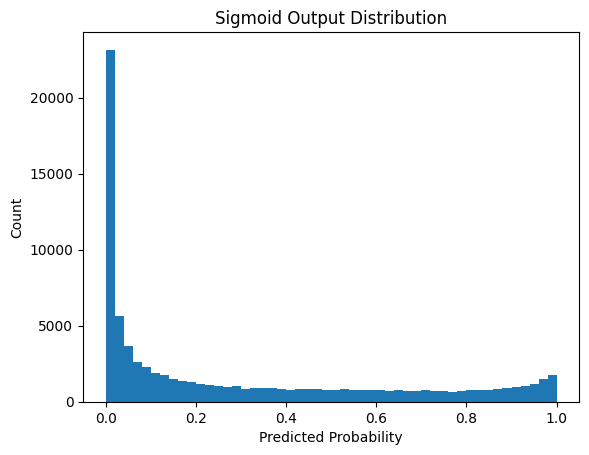

[Eval] Avg loss=0.4233 | F1_micro=0.4240 | Best_F1=0.4240 @ thr=0.30 | Avg labels/sample=18.71


 53%|█████▎    | 53/100 [09:42<08:29, 10.85s/it]

Round 53/100 | Avg Local Loss: 0.7573 | Global Val Loss: 0.4233 | F1_micro: 0.4240 | Best_F1: 0.4240 (thr=0.30)
[Eval Debug] Logit range: -15.91 to 11.14 | Sigmoid mean=0.290, std=0.327


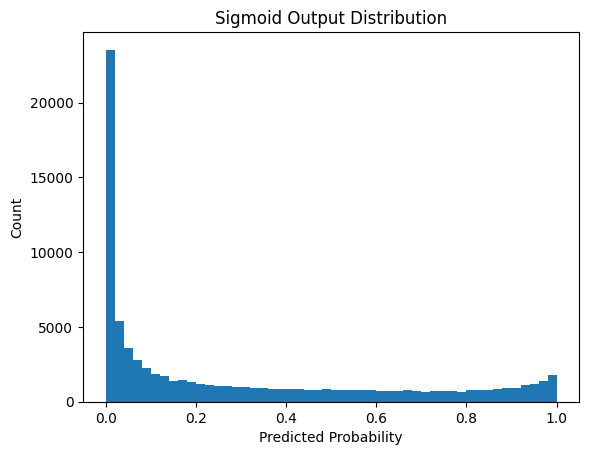

[Eval] Avg loss=0.4222 | F1_micro=0.4218 | Best_F1=0.4218 @ thr=0.30 | Avg labels/sample=18.61


 54%|█████▍    | 54/100 [09:53<08:16, 10.80s/it]

Round 54/100 | Avg Local Loss: 0.8266 | Global Val Loss: 0.4222 | F1_micro: 0.4218 | Best_F1: 0.4218 (thr=0.30)
[Eval Debug] Logit range: -16.16 to 12.79 | Sigmoid mean=0.293, std=0.329


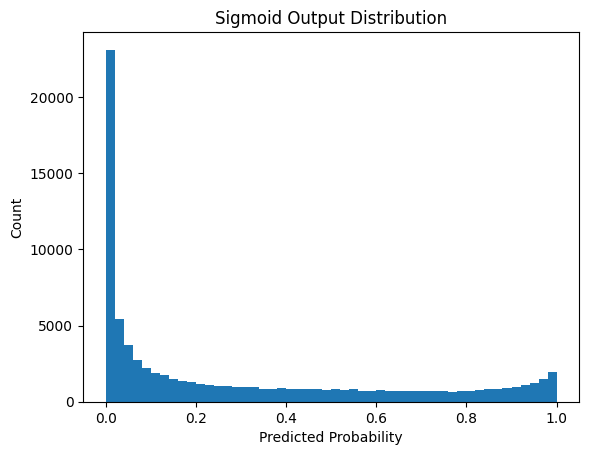

[Eval] Avg loss=0.4297 | F1_micro=0.4211 | Best_F1=0.4211 @ thr=0.30 | Avg labels/sample=18.76


 55%|█████▌    | 55/100 [10:03<08:04, 10.76s/it]

Round 55/100 | Avg Local Loss: 0.7878 | Global Val Loss: 0.4297 | F1_micro: 0.4211 | Best_F1: 0.4211 (thr=0.30)
[Eval Debug] Logit range: -16.69 to 11.89 | Sigmoid mean=0.292, std=0.329


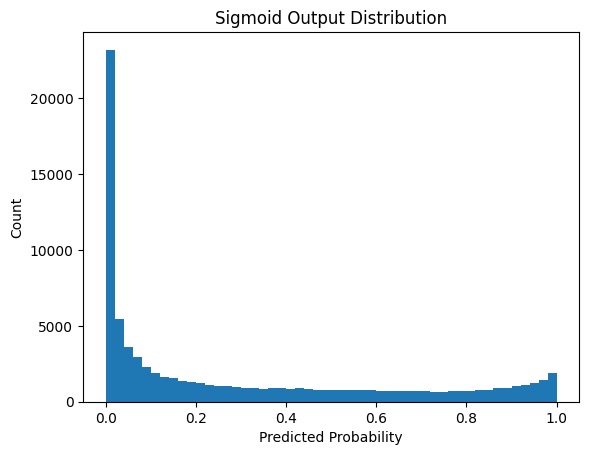

[Eval] Avg loss=0.4269 | F1_micro=0.4222 | Best_F1=0.4222 @ thr=0.30 | Avg labels/sample=18.61


 56%|█████▌    | 56/100 [10:14<07:51, 10.72s/it]

Round 56/100 | Avg Local Loss: 0.7282 | Global Val Loss: 0.4269 | F1_micro: 0.4222 | Best_F1: 0.4222 (thr=0.30)
[Eval Debug] Logit range: -16.04 to 11.88 | Sigmoid mean=0.291, std=0.329


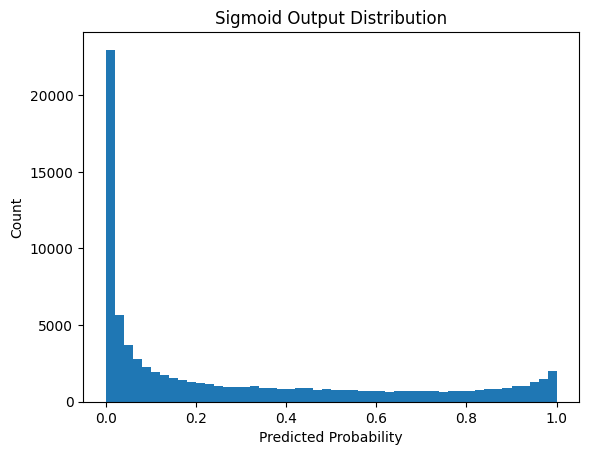

[Eval] Avg loss=0.4255 | F1_micro=0.4225 | Best_F1=0.4225 @ thr=0.30 | Avg labels/sample=18.62


 57%|█████▋    | 57/100 [10:25<07:40, 10.71s/it]

Round 57/100 | Avg Local Loss: 0.7611 | Global Val Loss: 0.4255 | F1_micro: 0.4225 | Best_F1: 0.4225 (thr=0.30)
[Eval Debug] Logit range: -17.18 to 11.82 | Sigmoid mean=0.290, std=0.329


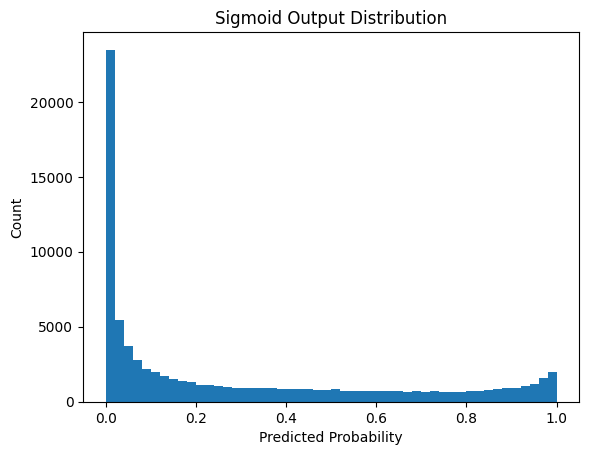

[Eval] Avg loss=0.4247 | F1_micro=0.4251 | Best_F1=0.4251 @ thr=0.30 | Avg labels/sample=18.52


 58%|█████▊    | 58/100 [10:35<07:30, 10.73s/it]

Round 58/100 | Avg Local Loss: 0.6443 | Global Val Loss: 0.4247 | F1_micro: 0.4251 | Best_F1: 0.4251 (thr=0.30)
[Eval Debug] Logit range: -17.97 to 11.91 | Sigmoid mean=0.290, std=0.329


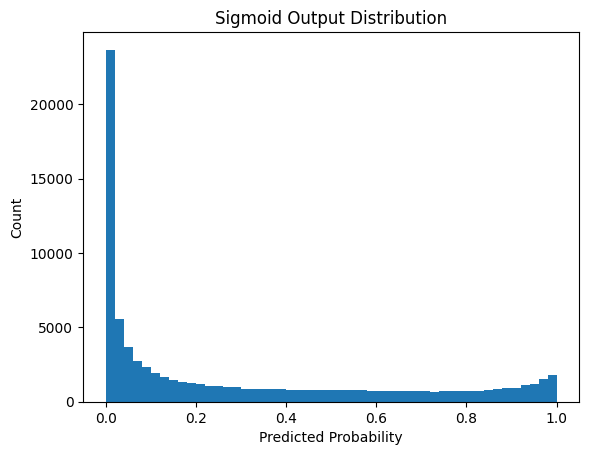

[Eval] Avg loss=0.4207 | F1_micro=0.4251 | Best_F1=0.4251 @ thr=0.30 | Avg labels/sample=18.53


 59%|█████▉    | 59/100 [10:46<07:23, 10.82s/it]

Round 59/100 | Avg Local Loss: 0.7021 | Global Val Loss: 0.4207 | F1_micro: 0.4251 | Best_F1: 0.4251 (thr=0.30)
[Eval Debug] Logit range: -18.45 to 11.64 | Sigmoid mean=0.289, std=0.328


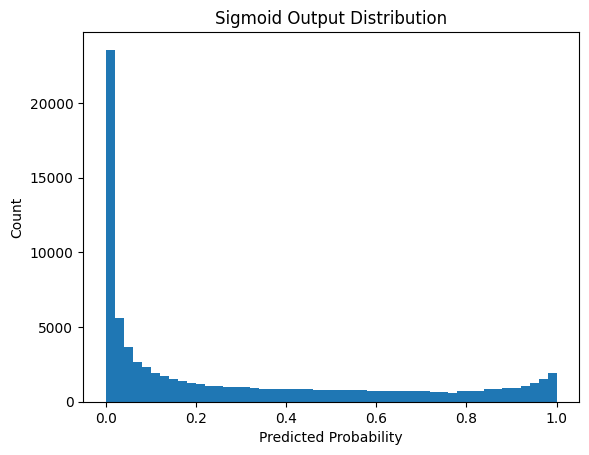

 60%|██████    | 60/100 [10:57<07:13, 10.83s/it]

[Eval] Avg loss=0.4217 | F1_micro=0.4256 | Best_F1=0.4256 @ thr=0.30 | Avg labels/sample=18.51
Round 60/100 | Avg Local Loss: 0.8716 | Global Val Loss: 0.4217 | F1_micro: 0.4256 | Best_F1: 0.4256 (thr=0.30)
[Eval Debug] Logit range: -17.77 to 11.47 | Sigmoid mean=0.296, std=0.332


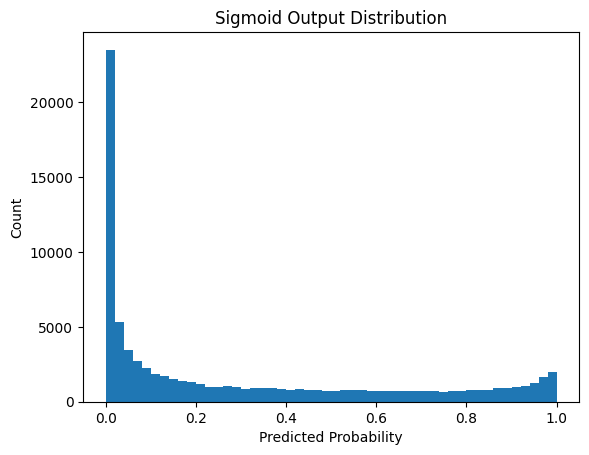

[Eval] Avg loss=0.4368 | F1_micro=0.4193 | Best_F1=0.4193 @ thr=0.30 | Avg labels/sample=18.89


 61%|██████    | 61/100 [11:08<07:02, 10.84s/it]

Round 61/100 | Avg Local Loss: 0.6940 | Global Val Loss: 0.4368 | F1_micro: 0.4193 | Best_F1: 0.4193 (thr=0.30)
[Eval Debug] Logit range: -17.79 to 11.69 | Sigmoid mean=0.286, std=0.329


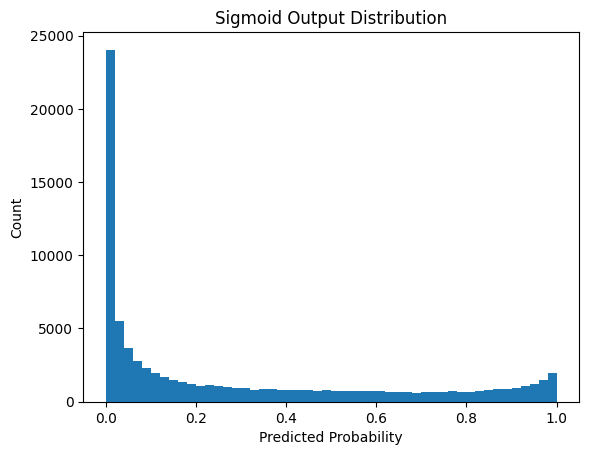

[Eval] Avg loss=0.4190 | F1_micro=0.4276 | Best_F1=0.4276 @ thr=0.30 | Avg labels/sample=18.22


 62%|██████▏   | 62/100 [11:19<06:53, 10.87s/it]

Round 62/100 | Avg Local Loss: 0.7618 | Global Val Loss: 0.4190 | F1_micro: 0.4276 | Best_F1: 0.4276 (thr=0.30)
[Eval Debug] Logit range: -16.48 to 11.86 | Sigmoid mean=0.276, std=0.325


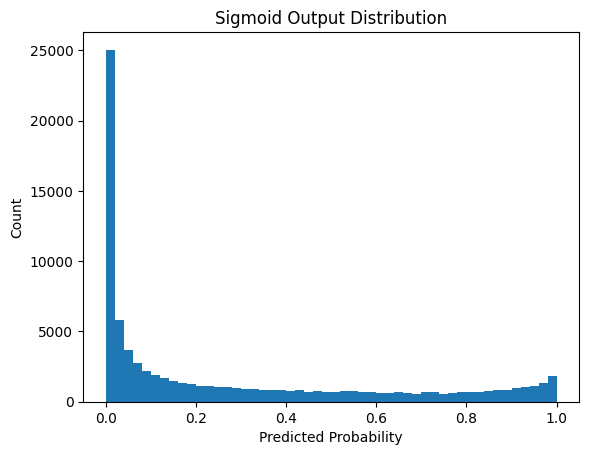

[Eval] Avg loss=0.3991 | F1_micro=0.4376 | Best_F1=0.4376 @ thr=0.30 | Avg labels/sample=17.51


 63%|██████▎   | 63/100 [11:30<06:46, 10.98s/it]

Round 63/100 | Avg Local Loss: 0.7293 | Global Val Loss: 0.3991 | F1_micro: 0.4376 | Best_F1: 0.4376 (thr=0.30)
[Eval Debug] Logit range: -17.67 to 12.85 | Sigmoid mean=0.283, std=0.326


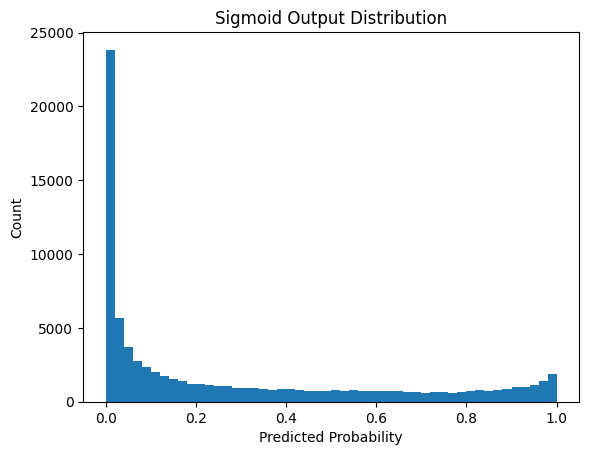

[Eval] Avg loss=0.4105 | F1_micro=0.4305 | Best_F1=0.4305 @ thr=0.30 | Avg labels/sample=18.05


 64%|██████▍   | 64/100 [11:41<06:34, 10.97s/it]

Round 64/100 | Avg Local Loss: 0.6494 | Global Val Loss: 0.4105 | F1_micro: 0.4305 | Best_F1: 0.4305 (thr=0.30)
[Eval Debug] Logit range: -17.33 to 12.22 | Sigmoid mean=0.287, std=0.329


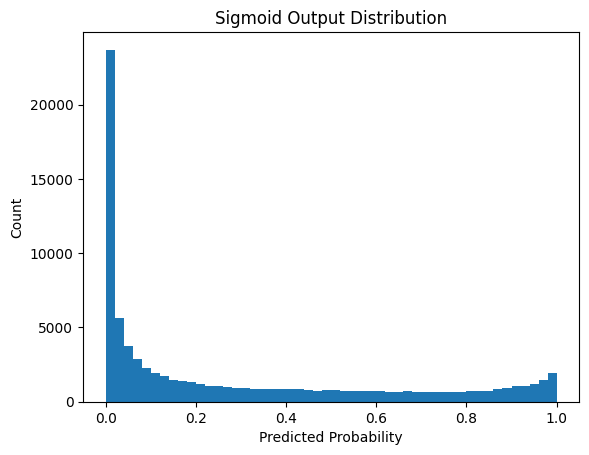

[Eval] Avg loss=0.4191 | F1_micro=0.4280 | Best_F1=0.4280 @ thr=0.30 | Avg labels/sample=18.24


 65%|██████▌   | 65/100 [11:52<06:25, 11.00s/it]

Round 65/100 | Avg Local Loss: 0.7462 | Global Val Loss: 0.4191 | F1_micro: 0.4280 | Best_F1: 0.4280 (thr=0.30)
[Eval Debug] Logit range: -16.87 to 12.36 | Sigmoid mean=0.286, std=0.329


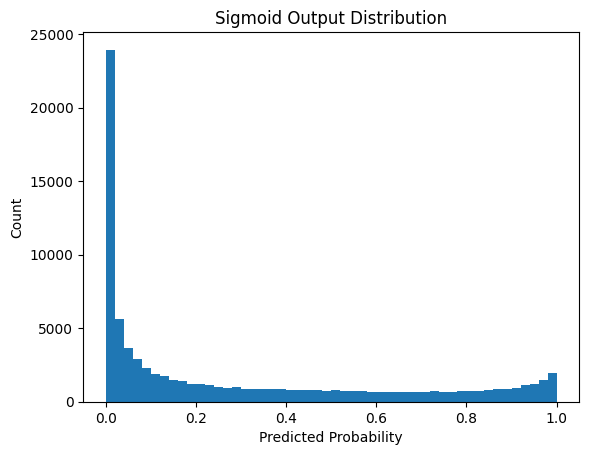

[Eval] Avg loss=0.4166 | F1_micro=0.4305 | Best_F1=0.4305 @ thr=0.30 | Avg labels/sample=18.18


 66%|██████▌   | 66/100 [12:03<06:12, 10.96s/it]

Round 66/100 | Avg Local Loss: 0.7411 | Global Val Loss: 0.4166 | F1_micro: 0.4305 | Best_F1: 0.4305 (thr=0.30)
[Eval Debug] Logit range: -18.39 to 13.01 | Sigmoid mean=0.292, std=0.330


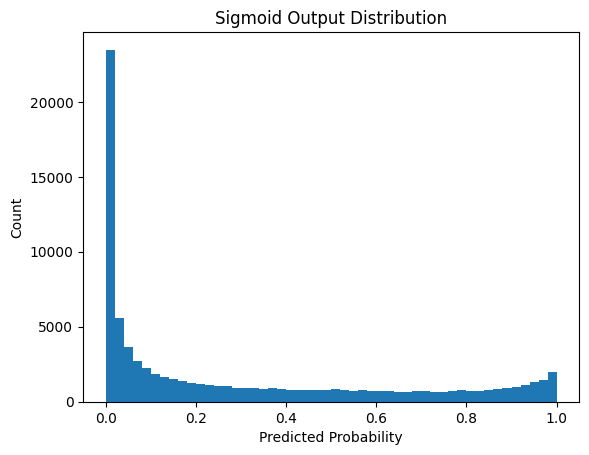

 67%|██████▋   | 67/100 [12:14<06:02, 10.97s/it]

[Eval] Avg loss=0.4277 | F1_micro=0.4229 | Best_F1=0.4229 @ thr=0.30 | Avg labels/sample=18.63
Round 67/100 | Avg Local Loss: 0.7014 | Global Val Loss: 0.4277 | F1_micro: 0.4229 | Best_F1: 0.4229 (thr=0.30)
[Eval Debug] Logit range: -18.66 to 13.39 | Sigmoid mean=0.286, std=0.329


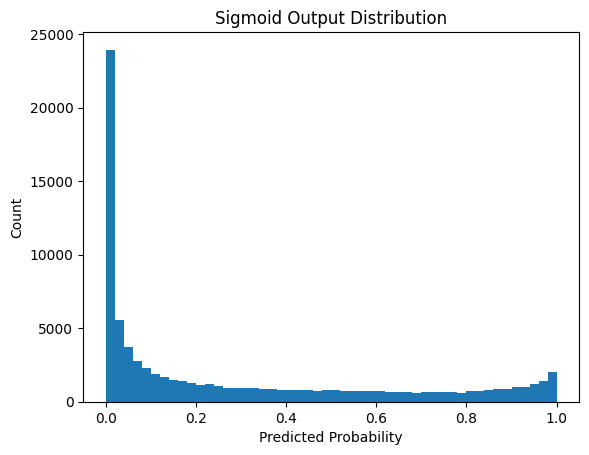

[Eval] Avg loss=0.4178 | F1_micro=0.4306 | Best_F1=0.4306 @ thr=0.30 | Avg labels/sample=18.18


 68%|██████▊   | 68/100 [12:25<05:51, 10.99s/it]

Round 68/100 | Avg Local Loss: 0.7671 | Global Val Loss: 0.4178 | F1_micro: 0.4306 | Best_F1: 0.4306 (thr=0.30)
[Eval Debug] Logit range: -17.51 to 12.95 | Sigmoid mean=0.290, std=0.331


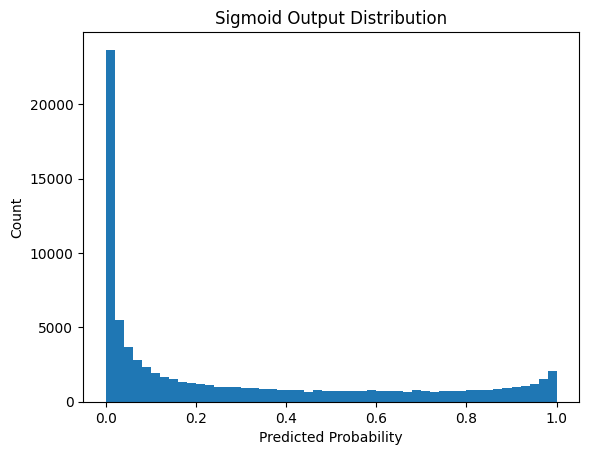

 69%|██████▉   | 69/100 [12:36<05:42, 11.05s/it]

[Eval] Avg loss=0.4261 | F1_micro=0.4277 | Best_F1=0.4277 @ thr=0.30 | Avg labels/sample=18.38
Round 69/100 | Avg Local Loss: 0.6295 | Global Val Loss: 0.4261 | F1_micro: 0.4277 | Best_F1: 0.4277 (thr=0.30)
[Eval Debug] Logit range: -16.34 to 11.89 | Sigmoid mean=0.285, std=0.329


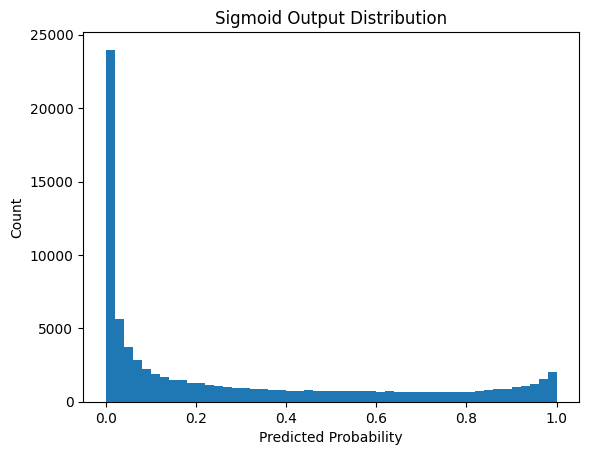

[Eval] Avg loss=0.4171 | F1_micro=0.4332 | Best_F1=0.4332 @ thr=0.30 | Avg labels/sample=17.97


 70%|███████   | 70/100 [12:47<05:30, 11.02s/it]

Round 70/100 | Avg Local Loss: 0.8359 | Global Val Loss: 0.4171 | F1_micro: 0.4332 | Best_F1: 0.4332 (thr=0.30)
[Eval Debug] Logit range: -16.94 to 11.66 | Sigmoid mean=0.283, std=0.328


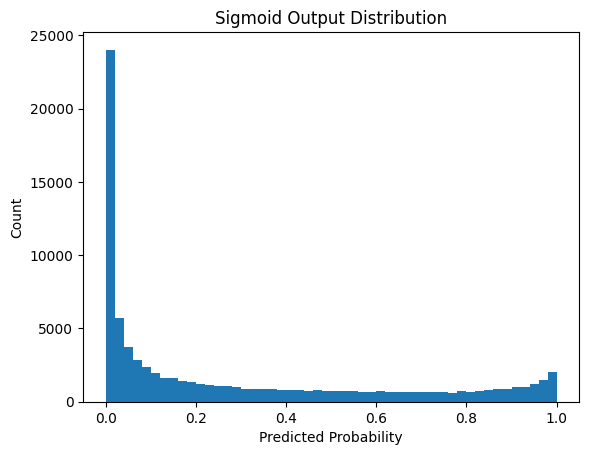

[Eval] Avg loss=0.4119 | F1_micro=0.4365 | Best_F1=0.4365 @ thr=0.30 | Avg labels/sample=17.80


 71%|███████   | 71/100 [12:58<05:18, 11.00s/it]

Round 71/100 | Avg Local Loss: 0.7016 | Global Val Loss: 0.4119 | F1_micro: 0.4365 | Best_F1: 0.4365 (thr=0.30)
[Eval Debug] Logit range: -17.50 to 12.31 | Sigmoid mean=0.279, std=0.326


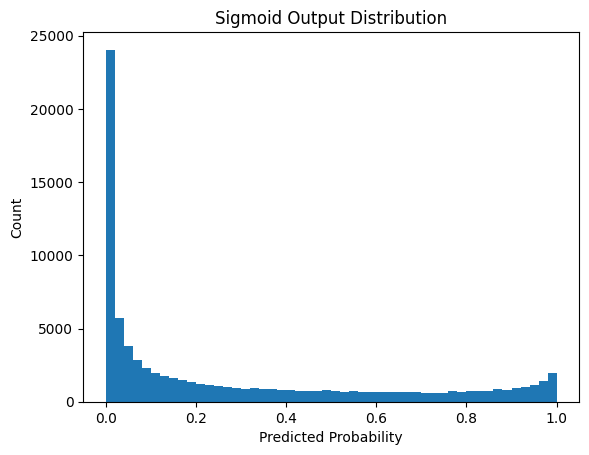

[Eval] Avg loss=0.4043 | F1_micro=0.4387 | Best_F1=0.4387 @ thr=0.30 | Avg labels/sample=17.59


 72%|███████▏  | 72/100 [13:09<05:07, 10.98s/it]

Round 72/100 | Avg Local Loss: 0.7035 | Global Val Loss: 0.4043 | F1_micro: 0.4387 | Best_F1: 0.4387 (thr=0.30)
[Eval Debug] Logit range: -18.31 to 12.36 | Sigmoid mean=0.283, std=0.327


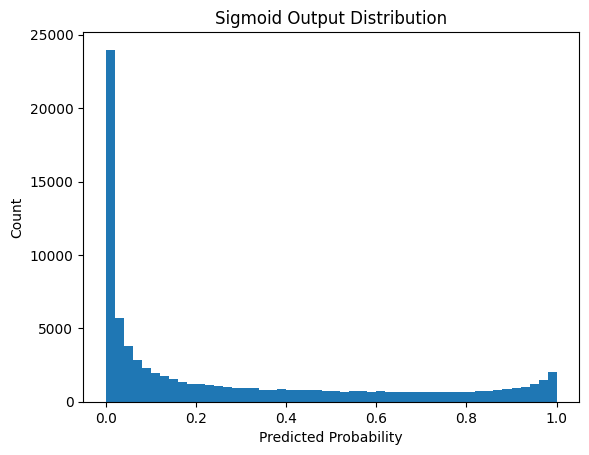

[Eval] Avg loss=0.4113 | F1_micro=0.4360 | Best_F1=0.4360 @ thr=0.30 | Avg labels/sample=17.82


 73%|███████▎  | 73/100 [13:20<04:55, 10.94s/it]

Round 73/100 | Avg Local Loss: 0.6988 | Global Val Loss: 0.4113 | F1_micro: 0.4360 | Best_F1: 0.4360 (thr=0.30)
[Eval Debug] Logit range: -18.70 to 11.65 | Sigmoid mean=0.285, std=0.329


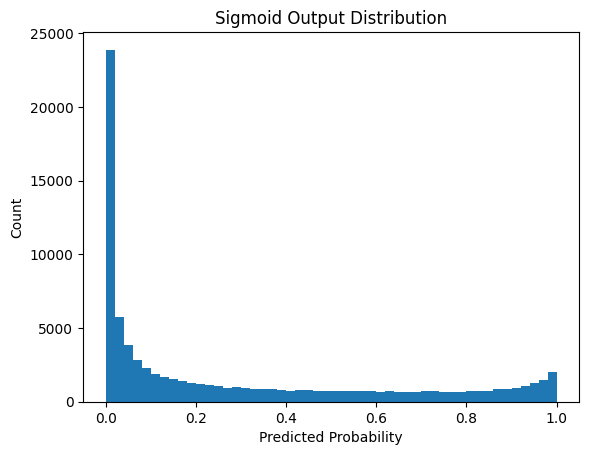

[Eval] Avg loss=0.4152 | F1_micro=0.4334 | Best_F1=0.4334 @ thr=0.30 | Avg labels/sample=18.02


 74%|███████▍  | 74/100 [13:31<04:42, 10.87s/it]

Round 74/100 | Avg Local Loss: 0.6895 | Global Val Loss: 0.4152 | F1_micro: 0.4334 | Best_F1: 0.4334 (thr=0.30)
[Eval Debug] Logit range: -15.90 to 12.91 | Sigmoid mean=0.284, std=0.328


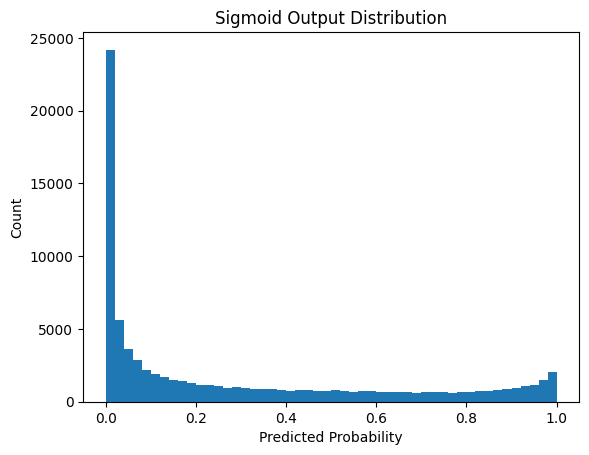

 75%|███████▌  | 75/100 [13:42<04:31, 10.87s/it]

[Eval] Avg loss=0.4142 | F1_micro=0.4326 | Best_F1=0.4326 @ thr=0.30 | Avg labels/sample=18.00
Round 75/100 | Avg Local Loss: 0.6207 | Global Val Loss: 0.4142 | F1_micro: 0.4326 | Best_F1: 0.4326 (thr=0.30)
[Eval Debug] Logit range: -19.11 to 12.55 | Sigmoid mean=0.280, std=0.328


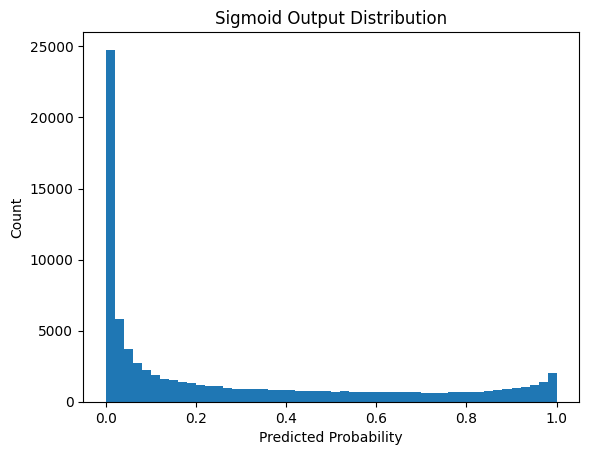

 76%|███████▌  | 76/100 [13:53<04:21, 10.88s/it]

[Eval] Avg loss=0.4097 | F1_micro=0.4350 | Best_F1=0.4350 @ thr=0.30 | Avg labels/sample=17.75
Round 76/100 | Avg Local Loss: 0.7642 | Global Val Loss: 0.4097 | F1_micro: 0.4350 | Best_F1: 0.4350 (thr=0.30)
[Eval Debug] Logit range: -19.75 to 12.46 | Sigmoid mean=0.284, std=0.329


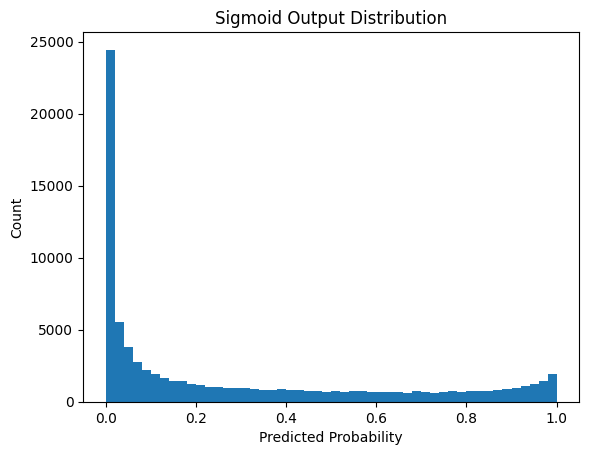

 77%|███████▋  | 77/100 [14:04<04:10, 10.90s/it]

[Eval] Avg loss=0.4162 | F1_micro=0.4308 | Best_F1=0.4308 @ thr=0.30 | Avg labels/sample=18.02
Round 77/100 | Avg Local Loss: 0.6937 | Global Val Loss: 0.4162 | F1_micro: 0.4308 | Best_F1: 0.4308 (thr=0.30)
[Eval Debug] Logit range: -19.05 to 12.63 | Sigmoid mean=0.286, std=0.331


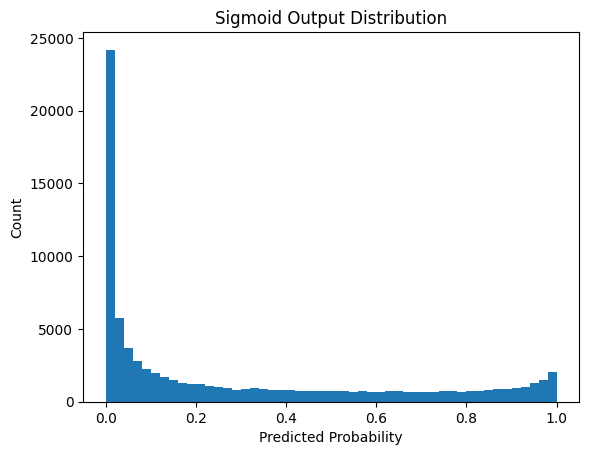

[Eval] Avg loss=0.4192 | F1_micro=0.4313 | Best_F1=0.4313 @ thr=0.30 | Avg labels/sample=18.15


 78%|███████▊  | 78/100 [14:15<04:00, 10.92s/it]

Round 78/100 | Avg Local Loss: 0.7129 | Global Val Loss: 0.4192 | F1_micro: 0.4313 | Best_F1: 0.4313 (thr=0.30)
[Eval Debug] Logit range: -20.30 to 12.23 | Sigmoid mean=0.284, std=0.330


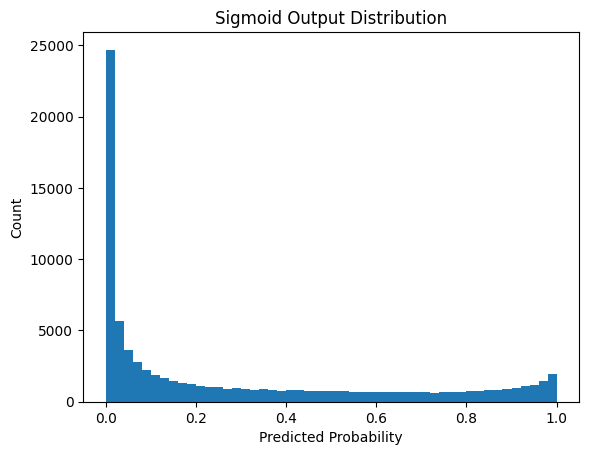

[Eval] Avg loss=0.4159 | F1_micro=0.4327 | Best_F1=0.4327 @ thr=0.30 | Avg labels/sample=18.01


 79%|███████▉  | 79/100 [14:26<03:50, 10.95s/it]

Round 79/100 | Avg Local Loss: 0.7056 | Global Val Loss: 0.4159 | F1_micro: 0.4327 | Best_F1: 0.4327 (thr=0.30)
[Eval Debug] Logit range: -17.92 to 12.56 | Sigmoid mean=0.286, std=0.332


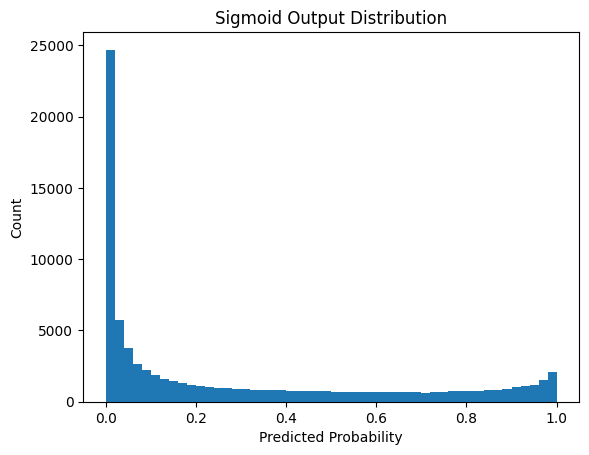

[Eval] Avg loss=0.4219 | F1_micro=0.4300 | Best_F1=0.4300 @ thr=0.30 | Avg labels/sample=18.10


 80%|████████  | 80/100 [14:37<03:39, 10.97s/it]

Round 80/100 | Avg Local Loss: 0.7991 | Global Val Loss: 0.4219 | F1_micro: 0.4300 | Best_F1: 0.4300 (thr=0.30)
[Eval Debug] Logit range: -19.17 to 12.25 | Sigmoid mean=0.285, std=0.331


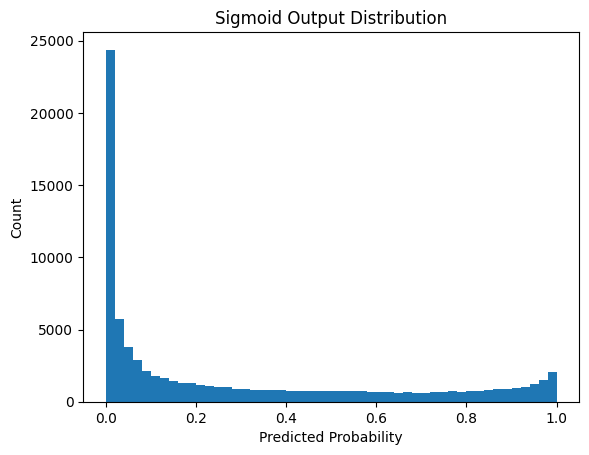

[Eval] Avg loss=0.4187 | F1_micro=0.4315 | Best_F1=0.4315 @ thr=0.30 | Avg labels/sample=18.03


 81%|████████  | 81/100 [14:48<03:30, 11.06s/it]

Round 81/100 | Avg Local Loss: 0.8093 | Global Val Loss: 0.4187 | F1_micro: 0.4315 | Best_F1: 0.4315 (thr=0.30)
[Eval Debug] Logit range: -18.91 to 12.39 | Sigmoid mean=0.279, std=0.329


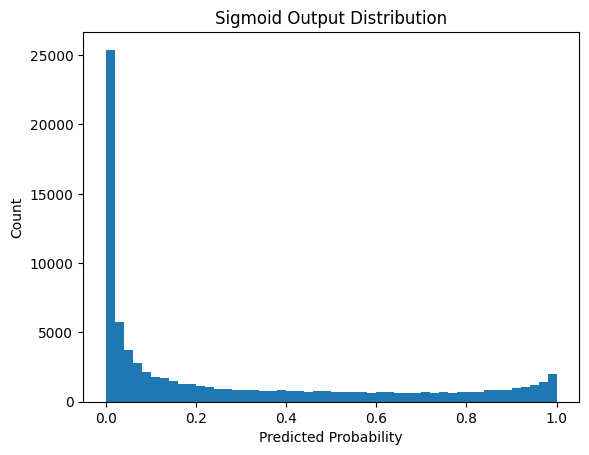

[Eval] Avg loss=0.4085 | F1_micro=0.4386 | Best_F1=0.4386 @ thr=0.30 | Avg labels/sample=17.60


 82%|████████▏ | 82/100 [14:59<03:19, 11.11s/it]

Round 82/100 | Avg Local Loss: 0.6595 | Global Val Loss: 0.4085 | F1_micro: 0.4386 | Best_F1: 0.4386 (thr=0.30)
[Eval Debug] Logit range: -18.75 to 12.18 | Sigmoid mean=0.285, std=0.332


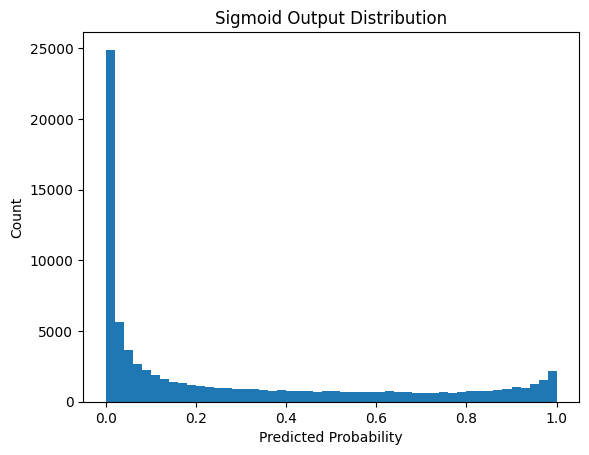

[Eval] Avg loss=0.4219 | F1_micro=0.4324 | Best_F1=0.4324 @ thr=0.30 | Avg labels/sample=18.07


 83%|████████▎ | 83/100 [15:10<03:08, 11.08s/it]

Round 83/100 | Avg Local Loss: 0.6317 | Global Val Loss: 0.4219 | F1_micro: 0.4324 | Best_F1: 0.4324 (thr=0.30)
[Eval Debug] Logit range: -16.82 to 12.47 | Sigmoid mean=0.281, std=0.331


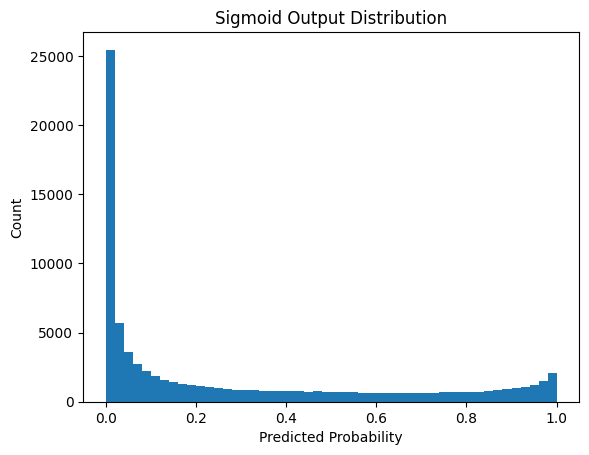

[Eval] Avg loss=0.4155 | F1_micro=0.4362 | Best_F1=0.4362 @ thr=0.30 | Avg labels/sample=17.76


 84%|████████▍ | 84/100 [15:21<02:57, 11.09s/it]

Round 84/100 | Avg Local Loss: 0.7116 | Global Val Loss: 0.4155 | F1_micro: 0.4362 | Best_F1: 0.4362 (thr=0.30)
[Eval Debug] Logit range: -17.45 to 12.51 | Sigmoid mean=0.284, std=0.331


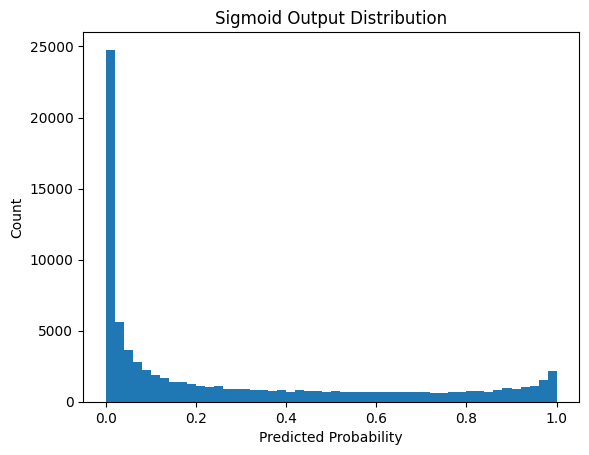

[Eval] Avg loss=0.4203 | F1_micro=0.4328 | Best_F1=0.4328 @ thr=0.30 | Avg labels/sample=17.93


 85%|████████▌ | 85/100 [15:32<02:46, 11.09s/it]

Round 85/100 | Avg Local Loss: 0.7360 | Global Val Loss: 0.4203 | F1_micro: 0.4328 | Best_F1: 0.4328 (thr=0.30)
[Eval Debug] Logit range: -19.54 to 12.25 | Sigmoid mean=0.280, std=0.329


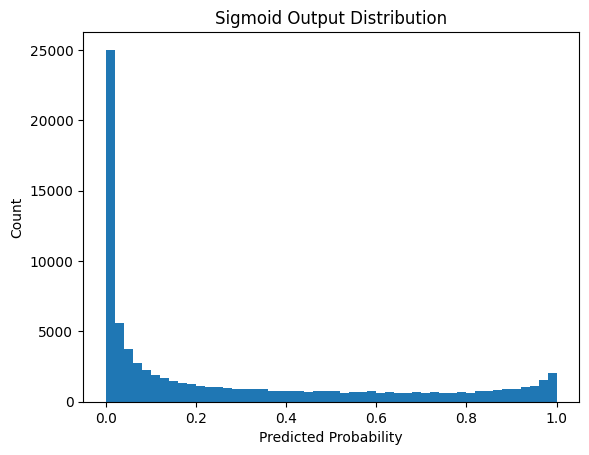

[Eval] Avg loss=0.4097 | F1_micro=0.4381 | Best_F1=0.4381 @ thr=0.30 | Avg labels/sample=17.68


 86%|████████▌ | 86/100 [15:44<02:35, 11.14s/it]

Round 86/100 | Avg Local Loss: 0.7719 | Global Val Loss: 0.4097 | F1_micro: 0.4381 | Best_F1: 0.4381 (thr=0.30)
[Eval Debug] Logit range: -16.65 to 12.80 | Sigmoid mean=0.281, std=0.331


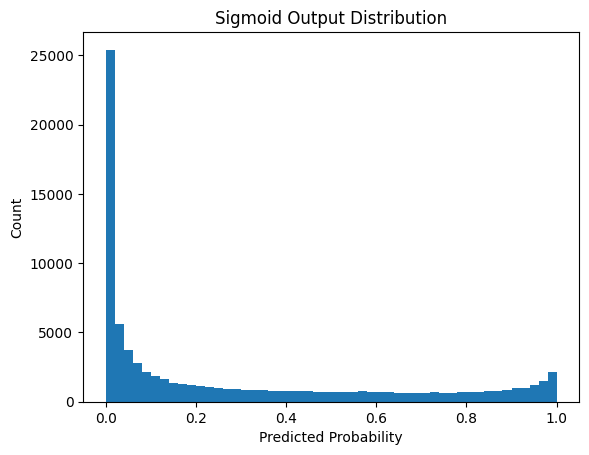

 87%|████████▋ | 87/100 [15:55<02:24, 11.15s/it]

[Eval] Avg loss=0.4155 | F1_micro=0.4372 | Best_F1=0.4372 @ thr=0.30 | Avg labels/sample=17.71
Round 87/100 | Avg Local Loss: 0.6916 | Global Val Loss: 0.4155 | F1_micro: 0.4372 | Best_F1: 0.4372 (thr=0.30)
[Eval Debug] Logit range: -16.49 to 13.17 | Sigmoid mean=0.282, std=0.330


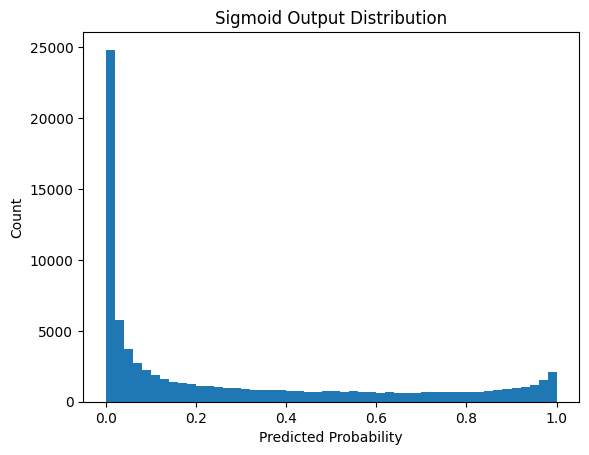

[Eval] Avg loss=0.4138 | F1_micro=0.4369 | Best_F1=0.4369 @ thr=0.30 | Avg labels/sample=17.80


 88%|████████▊ | 88/100 [16:06<02:13, 11.11s/it]

Round 88/100 | Avg Local Loss: 0.7405 | Global Val Loss: 0.4138 | F1_micro: 0.4369 | Best_F1: 0.4369 (thr=0.30)
[Eval Debug] Logit range: -17.60 to 13.12 | Sigmoid mean=0.286, std=0.331


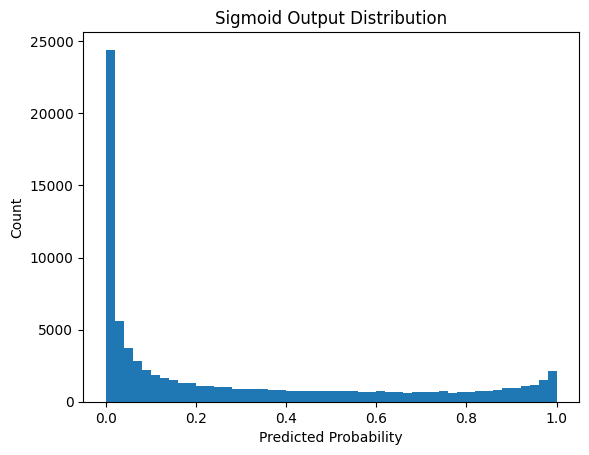

[Eval] Avg loss=0.4203 | F1_micro=0.4324 | Best_F1=0.4324 @ thr=0.30 | Avg labels/sample=18.05


 89%|████████▉ | 89/100 [16:17<02:01, 11.04s/it]

Round 89/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4203 | F1_micro: 0.4324 | Best_F1: 0.4324 (thr=0.30)
[Eval Debug] Logit range: -17.04 to 13.16 | Sigmoid mean=0.282, std=0.330


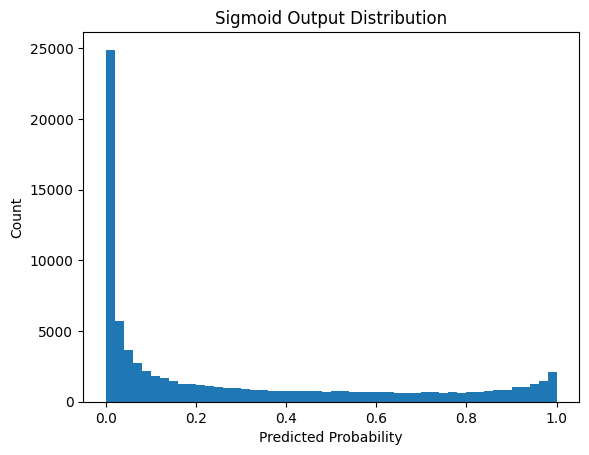

 90%|█████████ | 90/100 [16:28<01:50, 11.03s/it]

[Eval] Avg loss=0.4134 | F1_micro=0.4359 | Best_F1=0.4359 @ thr=0.30 | Avg labels/sample=17.73
Round 90/100 | Avg Local Loss: 0.6722 | Global Val Loss: 0.4134 | F1_micro: 0.4359 | Best_F1: 0.4359 (thr=0.30)
[Eval Debug] Logit range: -17.36 to 12.57 | Sigmoid mean=0.282, std=0.329


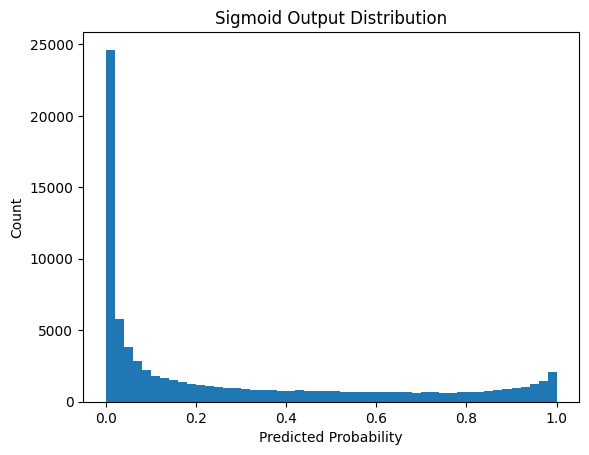

[Eval] Avg loss=0.4125 | F1_micro=0.4365 | Best_F1=0.4365 @ thr=0.30 | Avg labels/sample=17.74


 91%|█████████ | 91/100 [16:39<01:39, 11.06s/it]

Round 91/100 | Avg Local Loss: 0.7370 | Global Val Loss: 0.4125 | F1_micro: 0.4365 | Best_F1: 0.4365 (thr=0.30)
[Eval Debug] Logit range: -17.71 to 12.22 | Sigmoid mean=0.279, std=0.329


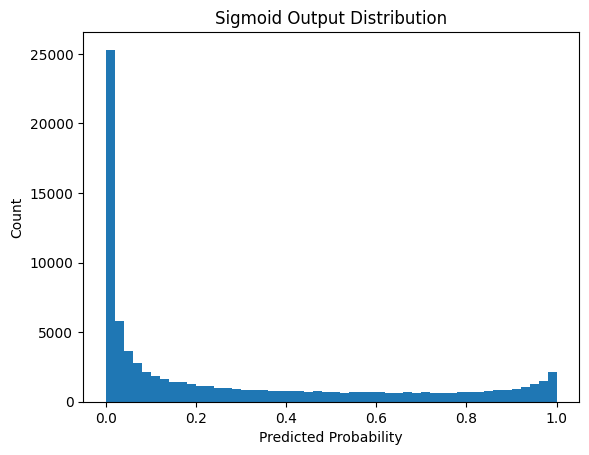

[Eval] Avg loss=0.4084 | F1_micro=0.4407 | Best_F1=0.4407 @ thr=0.30 | Avg labels/sample=17.55


 92%|█████████▏| 92/100 [16:50<01:28, 11.07s/it]

Round 92/100 | Avg Local Loss: 0.7673 | Global Val Loss: 0.4084 | F1_micro: 0.4407 | Best_F1: 0.4407 (thr=0.30)
[Eval Debug] Logit range: -16.28 to 12.78 | Sigmoid mean=0.280, std=0.329


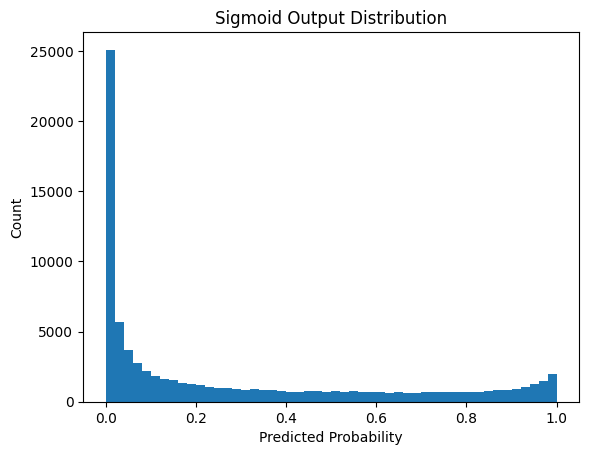

[Eval] Avg loss=0.4119 | F1_micro=0.4372 | Best_F1=0.4372 @ thr=0.30 | Avg labels/sample=17.67


 93%|█████████▎| 93/100 [17:01<01:17, 11.08s/it]

Round 93/100 | Avg Local Loss: 0.6948 | Global Val Loss: 0.4119 | F1_micro: 0.4372 | Best_F1: 0.4372 (thr=0.30)
[Eval Debug] Logit range: -16.55 to 12.29 | Sigmoid mean=0.283, std=0.331


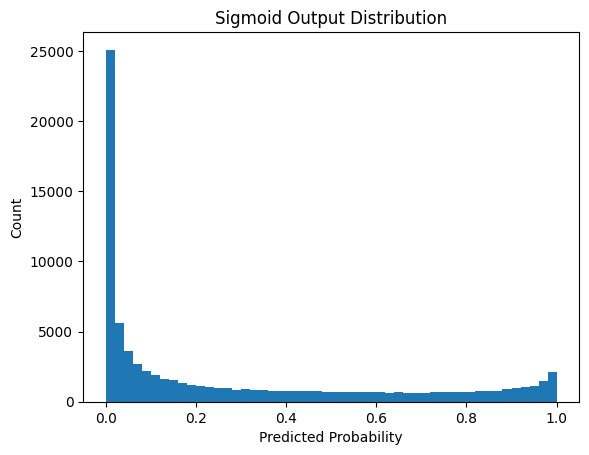

[Eval] Avg loss=0.4159 | F1_micro=0.4350 | Best_F1=0.4350 @ thr=0.30 | Avg labels/sample=17.90


 94%|█████████▍| 94/100 [17:12<01:05, 10.99s/it]

Round 94/100 | Avg Local Loss: 0.7722 | Global Val Loss: 0.4159 | F1_micro: 0.4350 | Best_F1: 0.4350 (thr=0.30)
[Eval Debug] Logit range: -18.49 to 12.03 | Sigmoid mean=0.282, std=0.329


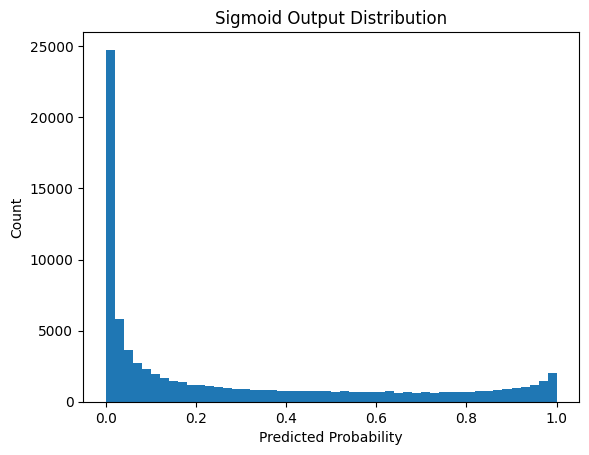

[Eval] Avg loss=0.4130 | F1_micro=0.4364 | Best_F1=0.4364 @ thr=0.30 | Avg labels/sample=17.79


 95%|█████████▌| 95/100 [17:23<00:54, 10.95s/it]

Round 95/100 | Avg Local Loss: 0.6483 | Global Val Loss: 0.4130 | F1_micro: 0.4364 | Best_F1: 0.4364 (thr=0.30)
[Eval Debug] Logit range: -18.90 to 12.13 | Sigmoid mean=0.283, std=0.332


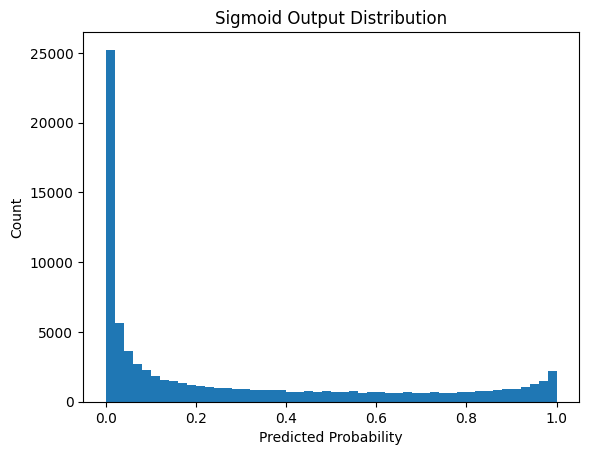

[Eval] Avg loss=0.4181 | F1_micro=0.4348 | Best_F1=0.4348 @ thr=0.30 | Avg labels/sample=17.82


 96%|█████████▌| 96/100 [17:34<00:43, 10.95s/it]

Round 96/100 | Avg Local Loss: 0.6304 | Global Val Loss: 0.4181 | F1_micro: 0.4348 | Best_F1: 0.4348 (thr=0.30)
[Eval Debug] Logit range: -18.90 to 13.13 | Sigmoid mean=0.284, std=0.332


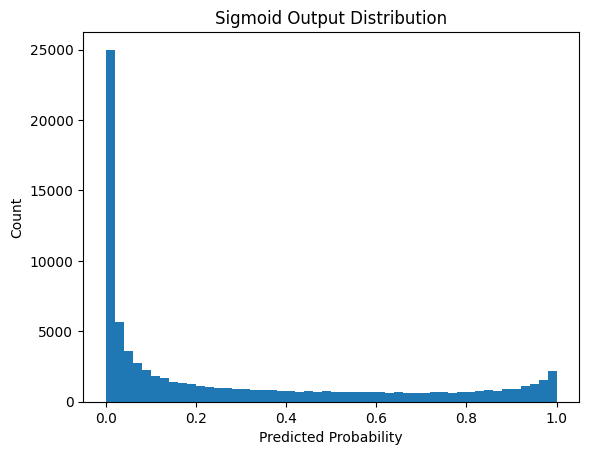

[Eval] Avg loss=0.4201 | F1_micro=0.4339 | Best_F1=0.4339 @ thr=0.30 | Avg labels/sample=17.93


 97%|█████████▋| 97/100 [17:45<00:32, 10.99s/it]

Round 97/100 | Avg Local Loss: 0.7560 | Global Val Loss: 0.4201 | F1_micro: 0.4339 | Best_F1: 0.4339 (thr=0.30)
[Eval Debug] Logit range: -19.87 to 12.99 | Sigmoid mean=0.284, std=0.332


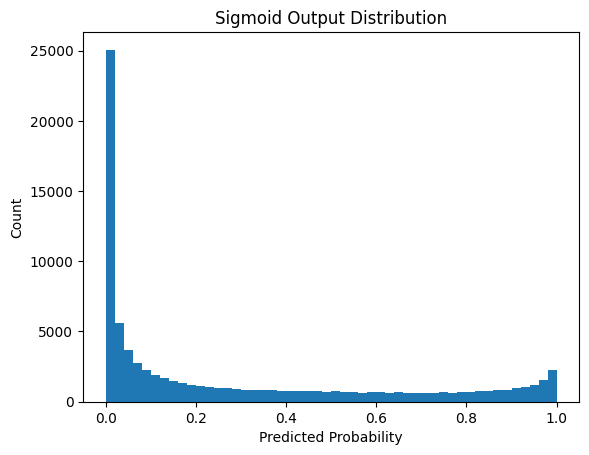

[Eval] Avg loss=0.4185 | F1_micro=0.4359 | Best_F1=0.4359 @ thr=0.30 | Avg labels/sample=17.84


 98%|█████████▊| 98/100 [17:56<00:21, 10.99s/it]

Round 98/100 | Avg Local Loss: 0.6646 | Global Val Loss: 0.4185 | F1_micro: 0.4359 | Best_F1: 0.4359 (thr=0.30)
[Eval Debug] Logit range: -19.69 to 12.58 | Sigmoid mean=0.280, std=0.330


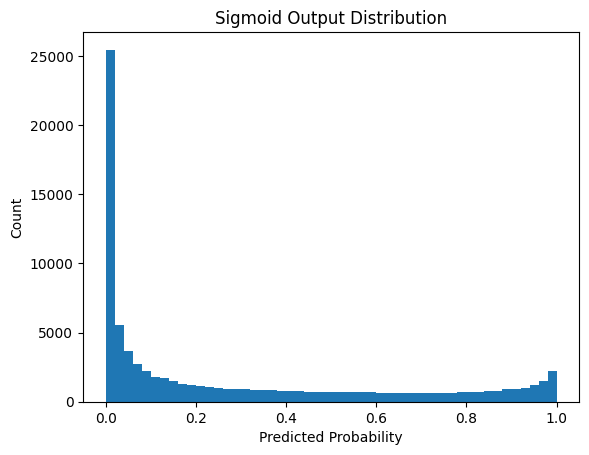

[Eval] Avg loss=0.4147 | F1_micro=0.4361 | Best_F1=0.4361 @ thr=0.30 | Avg labels/sample=17.69


 99%|█████████▉| 99/100 [18:06<00:10, 10.93s/it]

Round 99/100 | Avg Local Loss: 0.7212 | Global Val Loss: 0.4147 | F1_micro: 0.4361 | Best_F1: 0.4361 (thr=0.30)
[Eval Debug] Logit range: -19.50 to 12.97 | Sigmoid mean=0.285, std=0.333


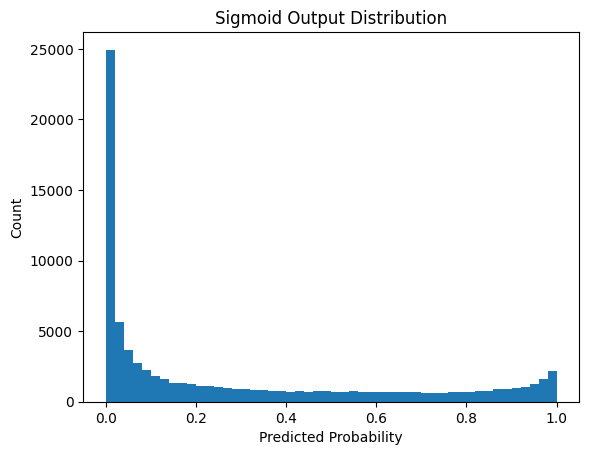

[Eval] Avg loss=0.4221 | F1_micro=0.4344 | Best_F1=0.4344 @ thr=0.30 | Avg labels/sample=17.93


100%|██████████| 100/100 [18:17<00:00, 10.98s/it]

Round 100/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.4344 | Best_F1: 0.4344 (thr=0.30)
Federated training complete!


Best threshold on validation set: 0.3 (F1=0.4344)


In [17]:
# Federated training loop 

config["rounds"] = 100  # important for testing time
target_evals = 100
eval_interval = max(1, round(config["rounds"] / target_evals))

for rnd in tqdm(range(config["rounds"]), colour="blue"):
    client_params = []
    total_local_loss = 0.0  # for averaging client losses

    # ---- Local training on each client ----
    for c_idx, loader in enumerate(c_loaders):
        client.load_state_dict(Global_Model.state_dict())

        local_loss, c_param = client_update(
            model=client,
            train_loader=loader,
            epochs=config["epochs"],
            lr=config["lr"],
            device=device
        )

        client_params.append(c_param)
        history["local_loss"][c_idx].append(local_loss)
        total_local_loss += local_loss

    avg_local_loss = total_local_loss / len(c_loaders)

    # ---- Aggregation step ----
    new_param = FedAvg(Global_Model.state_dict(), client_params)
    Global_Model.load_state_dict(new_param)

    # ---- Evaluation phase (same as centralized) ----
    if (rnd + 1) % eval_interval == 0 or rnd == config["rounds"] - 1:
        g_loss, metrics = eval_model(Global_Model, device, val_loader)
        history["global_loss"].append(g_loss)
        history["global_metrics"].append(metrics)

        # ---- Save checkpoints ----
        save_json(history, "../History/logs/metric_history.json")
        torch.save(Global_Model.state_dict(), "../History/logs/latest_model.pt")

        # Track best-performing models
        if metrics["auc_macro"] > max_auc_macro:
            max_auc_macro = metrics["auc_macro"]
            torch.save(Global_Model.state_dict(), "../History/logs/max_auc.pt")

        if metrics["f1_micro"] > max_f1_micro:
            max_f1_micro = metrics["f1_micro"]
            torch.save(Global_Model.state_dict(), "../History/logs/max_f1_micro.pt")

        # Print progress
        print(f"Round {rnd+1}/{config['rounds']} | "
            f"Avg Local Loss: {avg_local_loss:.4f} | "
            f"Global Val Loss: {g_loss:.4f} | "
            f"F1_micro: {metrics['f1_micro']:.4f} | "
            f"Best_F1: {metrics['best_f1_micro']:.4f} (thr={metrics['best_thr']:.2f})")

print("Federated training complete!")

best_f1, best_thr = find_best_threshold(Global_Model, val_loader, device)
print(f"Best threshold on validation set: {best_thr} (F1={best_f1:.4f})")


### Federated Training Results Visualization

This section loads the saved federated training history (`metric_history.json`) and visualizes:

1. **Global Loss** progression across rounds.  
2. **Local Client Losses** for each client.  
3. **Validation Metrics** (AUC, F1, etc.) of the global model over time.

The plots help assess:
- Training stability across clients  
- Convergence of global loss  
- Improvements in evaluation metrics

In [18]:
# Load training history

history = load_json(filepath="../History/logs/metric_history.json")
print(f"Total Global Rounds Logged: {len(history['global_loss'])}")

Total Global Rounds Logged: 100


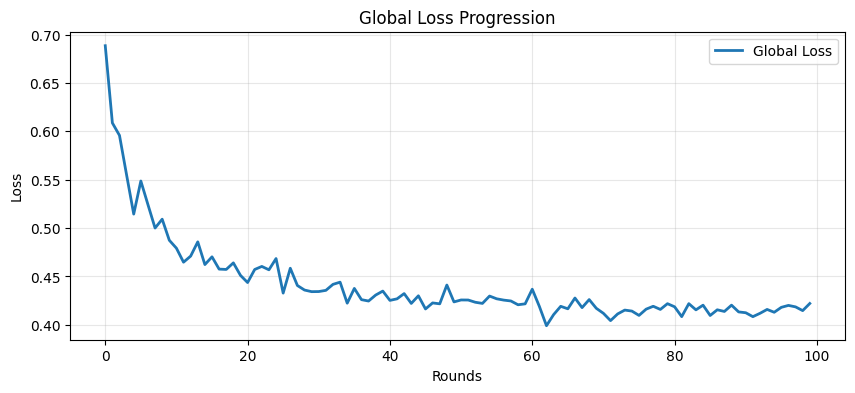

In [19]:
#Global loss progression 

plt.figure(figsize=(10, 4))
plt.plot(history["global_loss"], label="Global Loss", linewidth=2)
plt.title("Global Loss Progression")
plt.xlabel("Rounds")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

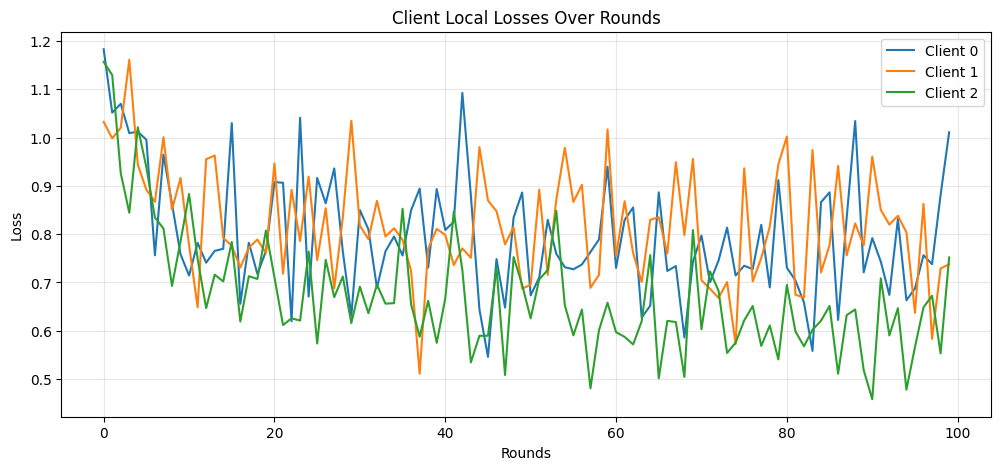

In [20]:
# Client local losses

plt.figure(figsize=(12, 5))
for c_idx in range(3):
    plt.plot(history["local_loss"][str(c_idx)], label=f"Client {c_idx}")
plt.title("Client Local Losses Over Rounds")
plt.xlabel("Rounds")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

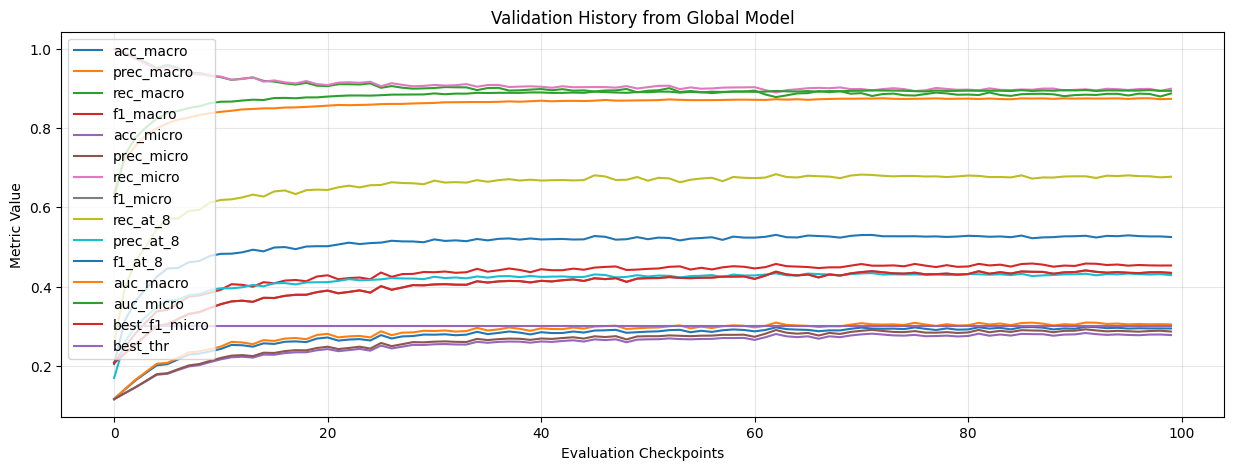

In [21]:
# Global validation metric overview

plt.figure(figsize=(15, 5))
plt.title("Validation History from Global Model")

# Plot each metric individually
for key in history["global_metrics"][0].keys():
    plt.plot([v[key] for v in history["global_metrics"]], label=key)

plt.xlabel("Evaluation Checkpoints")
plt.ylabel("Metric Value")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

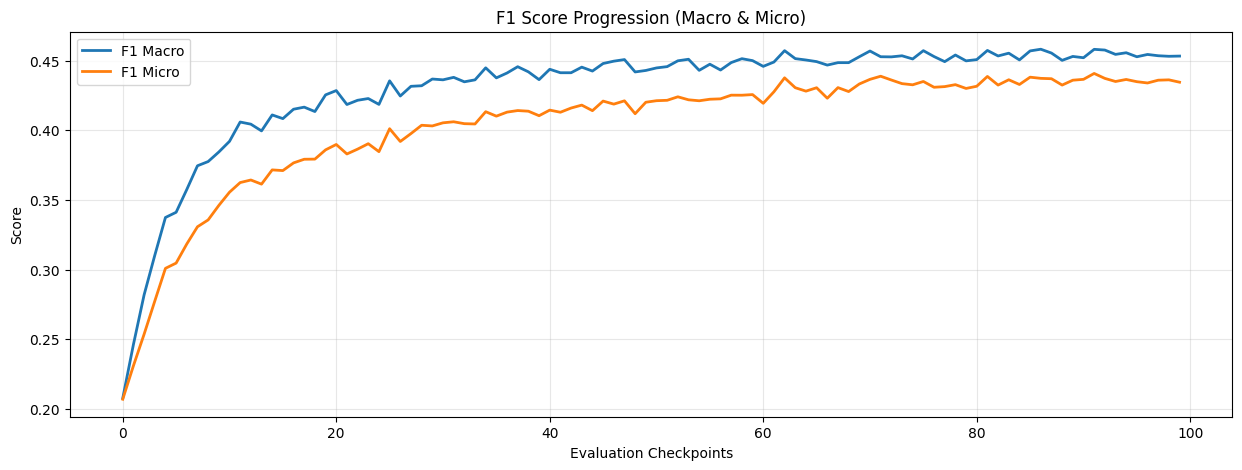

In [22]:
# F1 Score trends

plt.figure(figsize=(15, 5))
plt.title("F1 Score Progression (Macro & Micro)")
plt.plot([v["f1_macro"] for v in history["global_metrics"]], label="F1 Macro", linewidth=2)
plt.plot([v["f1_micro"] for v in history["global_metrics"]], label="F1 Micro", linewidth=2)
plt.xlabel("Evaluation Checkpoints")
plt.ylabel("Score")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


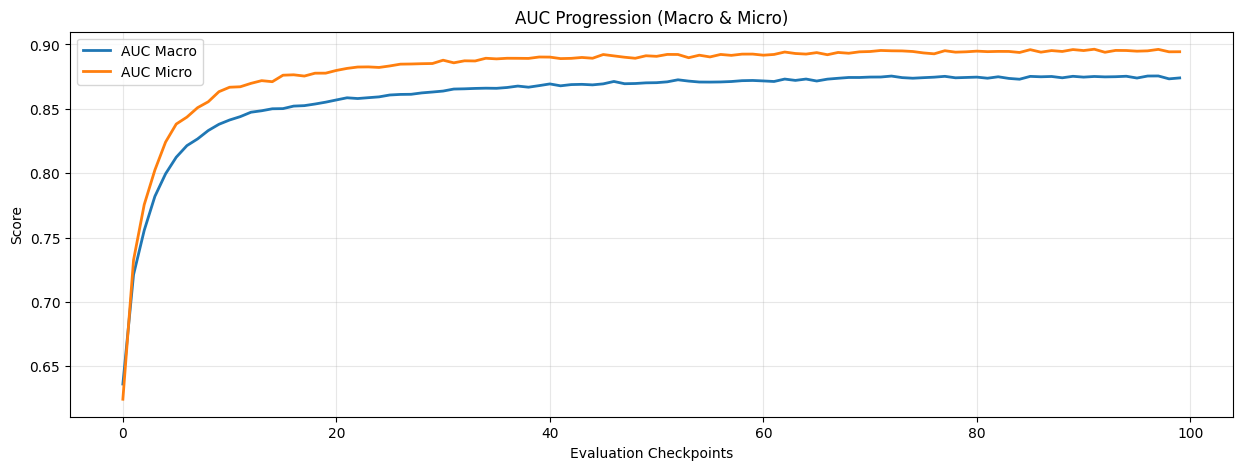

In [23]:
# AUC trends 

plt.figure(figsize=(15, 5))
plt.title("AUC Progression (Macro & Micro)")
plt.plot([v["auc_macro"] for v in history["global_metrics"]], label="AUC Macro", linewidth=2)
plt.plot([v["auc_micro"] for v in history["global_metrics"]], label="AUC Micro", linewidth=2)
plt.xlabel("Evaluation Checkpoints")
plt.ylabel("Score")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Centralized Training (Baseline)

This section trains a **single centralized model** on all data combined,
using the **same configuration, metrics, and visualization pipeline** as the federated setup.

The centralized model acts as an upper performance bound for comparison.

In [24]:
# Config - same as FL

central_config = config.copy()  # same parameters as FL
print(central_config)

{'batch_size': 32, 'lr': 0.002, 'n_filters': 21, 'window_size': 6, 'epochs': 3, 'rounds': 100}


In [25]:
# Centralized model initialization

central_model = GenerateModel(
    table_path=os.path.join("..", "Model", "processed_full.w2v"),
    num_of_filters=central_config["n_filters"],
    kernel_size=central_config["window_size"]
)

central_model.to(device)
val_loader = load_data(split="val")
train_loader = load_data(split="train")

# ---- Optional but recommended: bias init for fairness ----
n_labels = val_loader.dataset[0][1].shape[0]
pos_weight = compute_pos_weight(train_loader, n_labels).to(device)

with torch.no_grad():
    p = pos_weight / (pos_weight + 1.0)
    prior_logit = torch.log(p / (1 - p))
    central_model.final.bias.copy_(prior_logit.clamp(-10, 10))

print("Centralized model and data ready.")


Centralized model and data ready.


In [26]:
# Centralized training history set up

central_history = {
    "train_loss": [],
    "val_loss": [],
    "metrics": []
}

cent_max_auc_macro = 0.0
cent_max_f1_micro = 0.0

  0%|          | 0/100 [00:00<?, ?it/s]

[Eval Debug] Logit range: -1.27 to 1.36 | Sigmoid mean=0.494, std=0.066


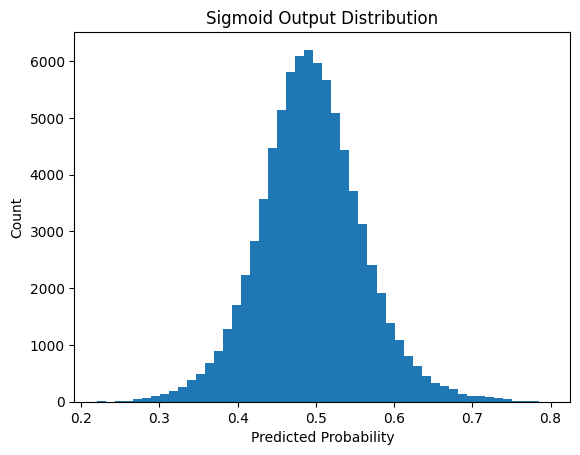

[Eval] Avg loss=0.6806 | F1_micro=0.2055 | Best_F1=0.2055 @ thr=0.30 | Avg labels/sample=49.84


  1%|          | 1/100 [00:04<07:25,  4.50s/it]

Round 1/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.2055 | Best_F1: 0.2055 (thr=0.30)
[Eval Debug] Logit range: -3.65 to 3.20 | Sigmoid mean=0.456, std=0.158


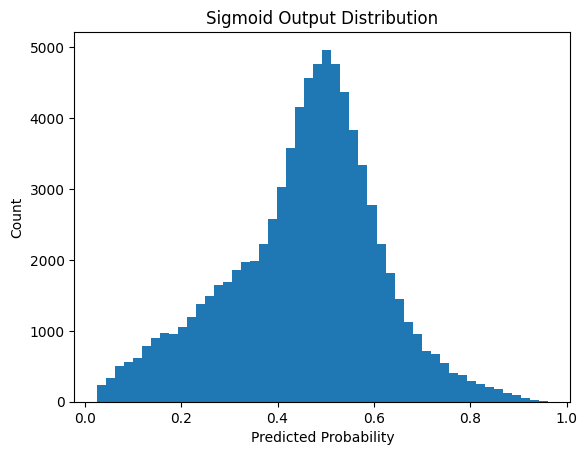

[Eval] Avg loss=0.6114 | F1_micro=0.2391 | Best_F1=0.2391 @ thr=0.30 | Avg labels/sample=41.46


  2%|▏         | 2/100 [00:08<07:13,  4.42s/it]

Round 2/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.2391 | Best_F1: 0.2391 (thr=0.30)
[Eval Debug] Logit range: -5.66 to 4.82 | Sigmoid mean=0.436, std=0.223


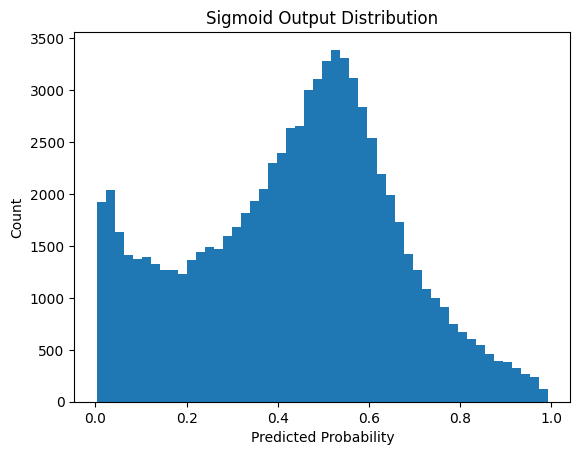

[Eval] Avg loss=0.5899 | F1_micro=0.2644 | Best_F1=0.2644 @ thr=0.30 | Avg labels/sample=36.22


  3%|▎         | 3/100 [00:13<07:06,  4.40s/it]

Round 3/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.2644 | Best_F1: 0.2644 (thr=0.30)
[Eval Debug] Logit range: -6.69 to 5.16 | Sigmoid mean=0.416, std=0.248


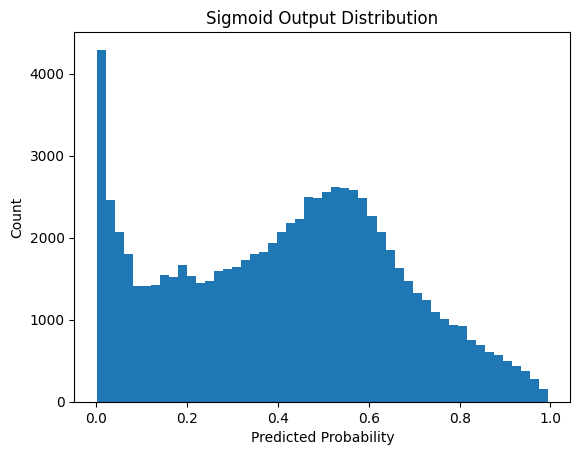

[Eval] Avg loss=0.5632 | F1_micro=0.2832 | Best_F1=0.2832 @ thr=0.30 | Avg labels/sample=33.06


  4%|▍         | 4/100 [00:17<07:01,  4.39s/it]

Round 4/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.2832 | Best_F1: 0.2832 (thr=0.30)
[Eval Debug] Logit range: -7.59 to 5.90 | Sigmoid mean=0.400, std=0.267


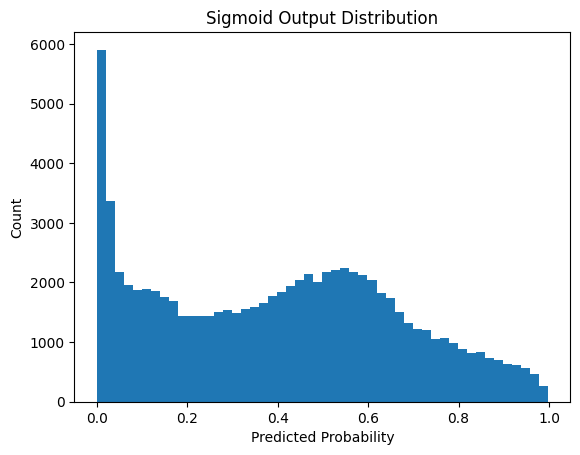

[Eval] Avg loss=0.5425 | F1_micro=0.3008 | Best_F1=0.3008 @ thr=0.30 | Avg labels/sample=30.61


  5%|▌         | 5/100 [00:21<06:55,  4.37s/it]

Round 5/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.3008 | Best_F1: 0.3008 (thr=0.30)
[Eval Debug] Logit range: -8.53 to 6.49 | Sigmoid mean=0.396, std=0.282


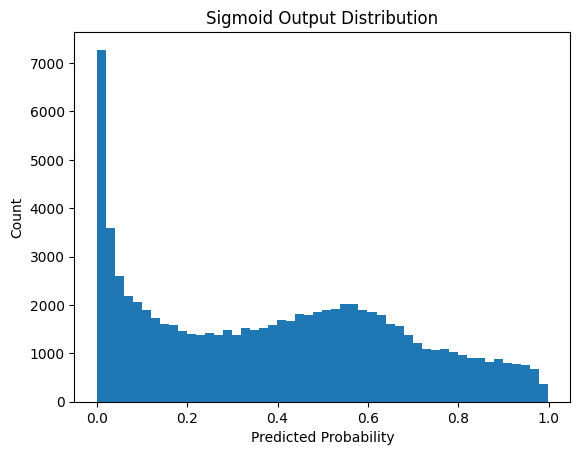

[Eval] Avg loss=0.5423 | F1_micro=0.3099 | Best_F1=0.3099 @ thr=0.30 | Avg labels/sample=29.49


  6%|▌         | 6/100 [00:26<06:50,  4.37s/it]

Round 6/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.3099 | Best_F1: 0.3099 (thr=0.30)
[Eval Debug] Logit range: -9.61 to 7.35 | Sigmoid mean=0.382, std=0.292


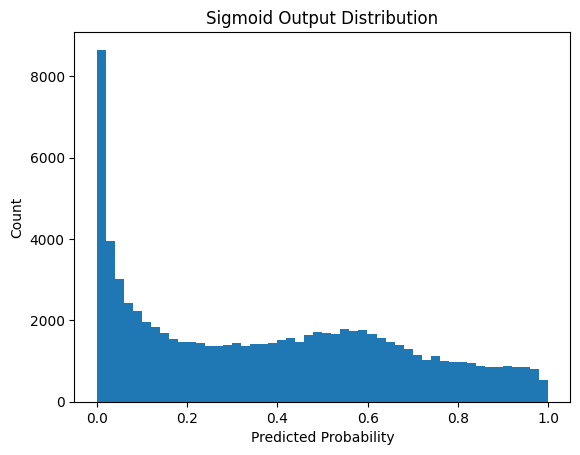

[Eval] Avg loss=0.5242 | F1_micro=0.3245 | Best_F1=0.3245 @ thr=0.30 | Avg labels/sample=27.75


  7%|▋         | 7/100 [00:30<06:45,  4.36s/it]

Round 7/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.3245 | Best_F1: 0.3245 (thr=0.30)
[Eval Debug] Logit range: -9.82 to 7.55 | Sigmoid mean=0.376, std=0.299


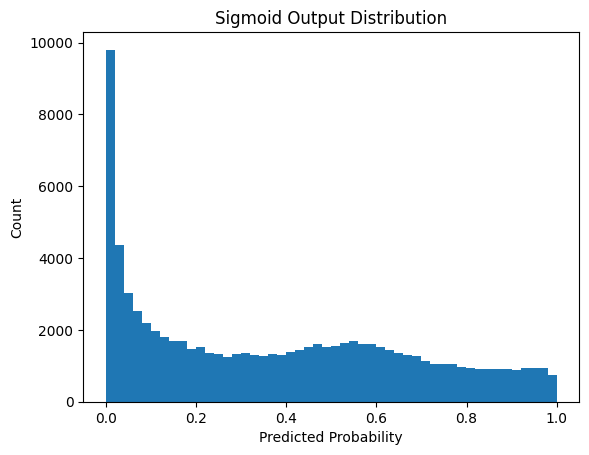

[Eval] Avg loss=0.5184 | F1_micro=0.3335 | Best_F1=0.3335 @ thr=0.30 | Avg labels/sample=26.88


  8%|▊         | 8/100 [00:35<06:41,  4.37s/it]

Round 8/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.3335 | Best_F1: 0.3335 (thr=0.30)
[Eval Debug] Logit range: -10.03 to 8.10 | Sigmoid mean=0.368, std=0.302


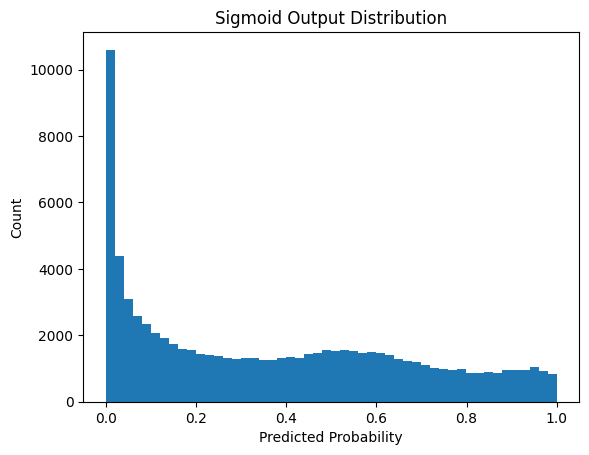

[Eval] Avg loss=0.5065 | F1_micro=0.3408 | Best_F1=0.3408 @ thr=0.30 | Avg labels/sample=25.99


  9%|▉         | 9/100 [00:40<06:56,  4.57s/it]

Round 9/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.3408 | Best_F1: 0.3408 (thr=0.30)
[Eval Debug] Logit range: -11.16 to 8.02 | Sigmoid mean=0.362, std=0.307


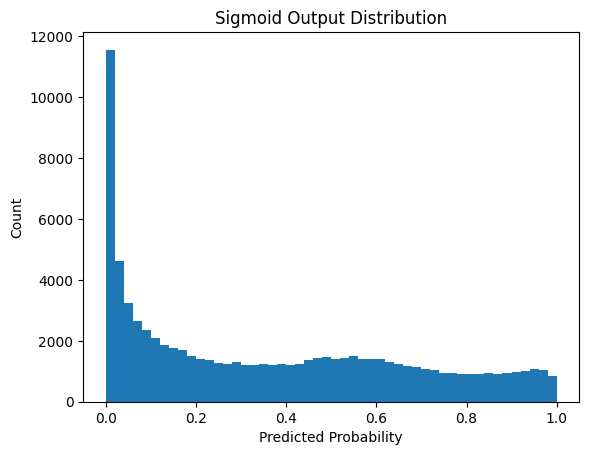

[Eval] Avg loss=0.4986 | F1_micro=0.3486 | Best_F1=0.3486 @ thr=0.30 | Avg labels/sample=25.24


 10%|█         | 10/100 [00:44<06:45,  4.51s/it]

Round 10/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.3486 | Best_F1: 0.3486 (thr=0.30)
[Eval Debug] Logit range: -10.73 to 9.55 | Sigmoid mean=0.360, std=0.311


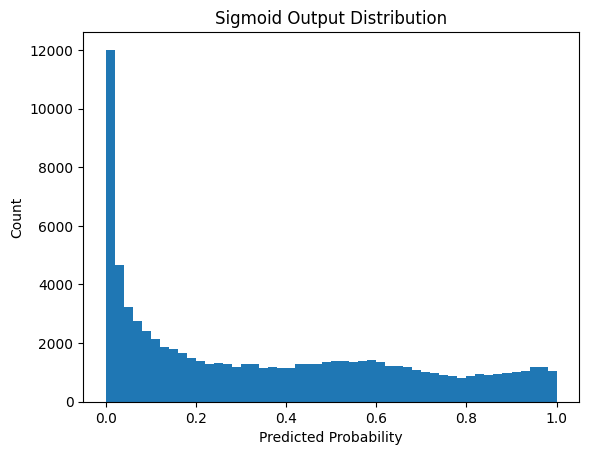

[Eval] Avg loss=0.5007 | F1_micro=0.3517 | Best_F1=0.3517 @ thr=0.30 | Avg labels/sample=24.91


 11%|█         | 11/100 [00:48<06:36,  4.46s/it]

Round 11/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.3517 | Best_F1: 0.3517 (thr=0.30)
[Eval Debug] Logit range: -11.29 to 8.67 | Sigmoid mean=0.355, std=0.313


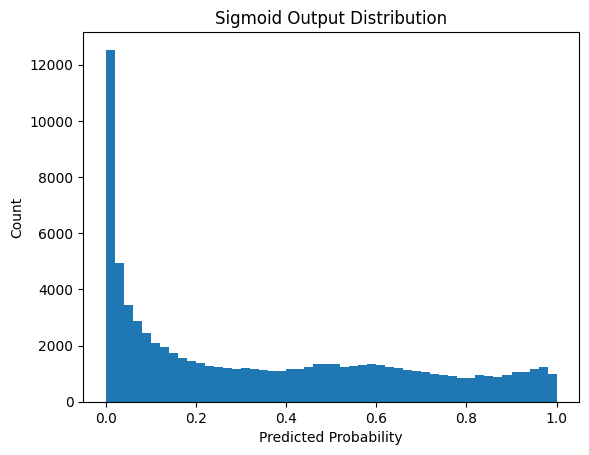

[Eval] Avg loss=0.4913 | F1_micro=0.3584 | Best_F1=0.3584 @ thr=0.30 | Avg labels/sample=24.35


 12%|█▏        | 12/100 [00:53<06:28,  4.41s/it]

Round 12/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.3584 | Best_F1: 0.3584 (thr=0.30)
[Eval Debug] Logit range: -12.44 to 9.04 | Sigmoid mean=0.351, std=0.312


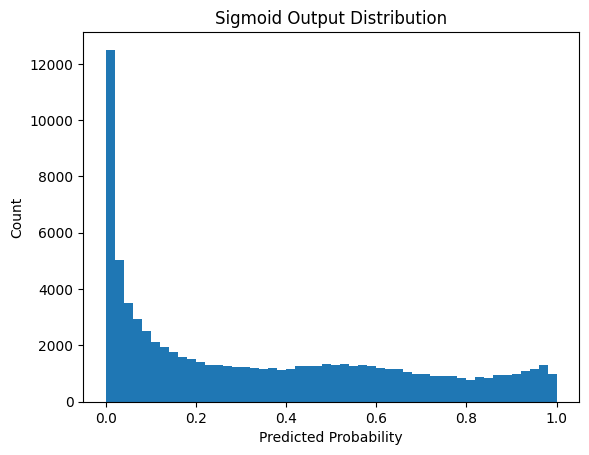

[Eval] Avg loss=0.4836 | F1_micro=0.3623 | Best_F1=0.3623 @ thr=0.30 | Avg labels/sample=24.01


 13%|█▎        | 13/100 [00:58<06:38,  4.59s/it]

Round 13/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.3623 | Best_F1: 0.3623 (thr=0.30)
[Eval Debug] Logit range: -11.51 to 9.55 | Sigmoid mean=0.349, std=0.313


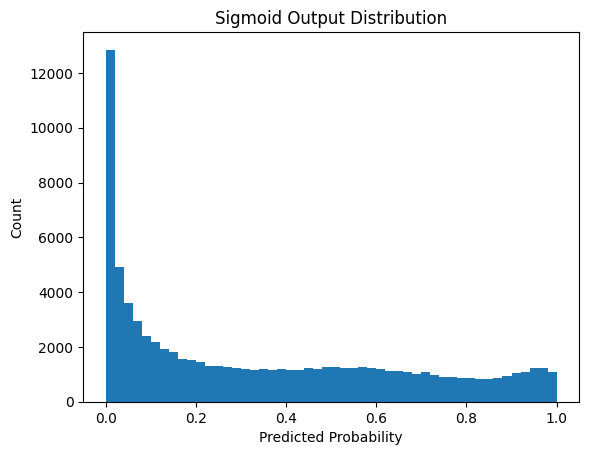

[Eval] Avg loss=0.4808 | F1_micro=0.3643 | Best_F1=0.3643 @ thr=0.30 | Avg labels/sample=23.77


 14%|█▍        | 14/100 [01:02<06:27,  4.50s/it]

Round 14/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.3643 | Best_F1: 0.3643 (thr=0.30)
[Eval Debug] Logit range: -11.95 to 8.75 | Sigmoid mean=0.348, std=0.317


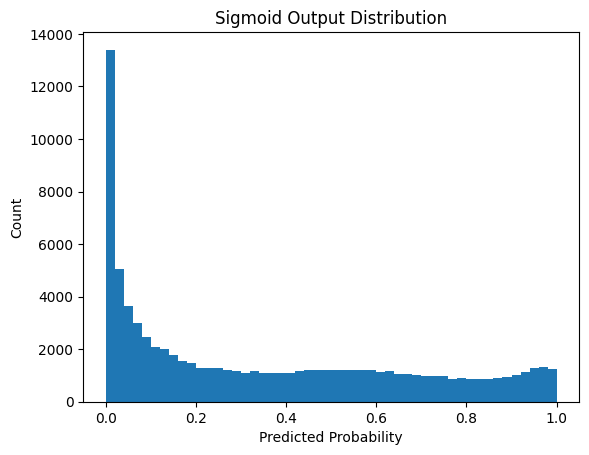

[Eval] Avg loss=0.4840 | F1_micro=0.3669 | Best_F1=0.3669 @ thr=0.30 | Avg labels/sample=23.54


 15%|█▌        | 15/100 [01:06<06:18,  4.45s/it]

Round 15/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.3669 | Best_F1: 0.3669 (thr=0.30)
[Eval Debug] Logit range: -12.21 to 9.12 | Sigmoid mean=0.349, std=0.314


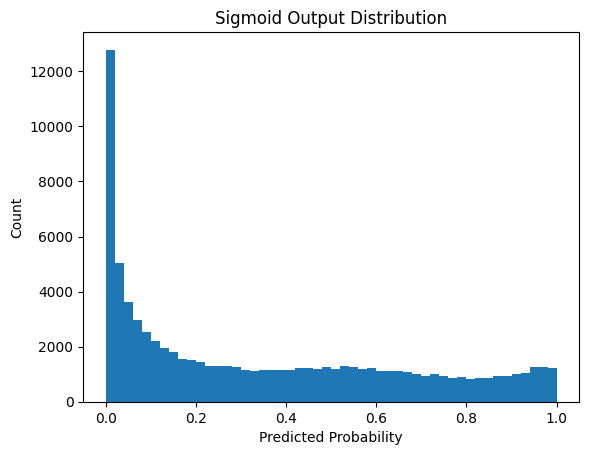

 16%|█▌        | 16/100 [01:10<06:08,  4.39s/it]

[Eval] Avg loss=0.4822 | F1_micro=0.3660 | Best_F1=0.3660 @ thr=0.30 | Avg labels/sample=23.65
Round 16/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.3660 | Best_F1: 0.3660 (thr=0.30)
[Eval Debug] Logit range: -12.66 to 9.82 | Sigmoid mean=0.345, std=0.318


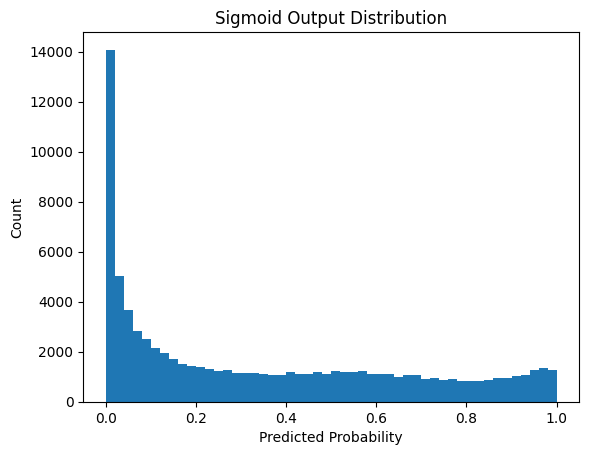

[Eval] Avg loss=0.4775 | F1_micro=0.3713 | Best_F1=0.3713 @ thr=0.30 | Avg labels/sample=23.22


 17%|█▋        | 17/100 [01:15<06:03,  4.39s/it]

Round 17/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.3713 | Best_F1: 0.3713 (thr=0.30)
[Eval Debug] Logit range: -11.91 to 9.55 | Sigmoid mean=0.341, std=0.318


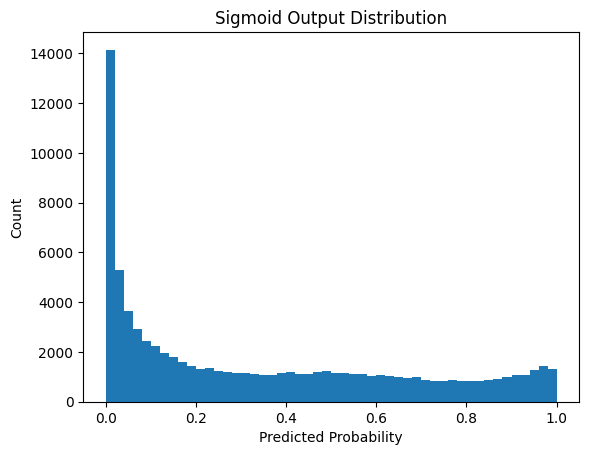

[Eval] Avg loss=0.4718 | F1_micro=0.3742 | Best_F1=0.3742 @ thr=0.30 | Avg labels/sample=22.88


 18%|█▊        | 18/100 [01:19<05:58,  4.38s/it]

Round 18/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.3742 | Best_F1: 0.3742 (thr=0.30)
[Eval Debug] Logit range: -12.44 to 9.53 | Sigmoid mean=0.338, std=0.318


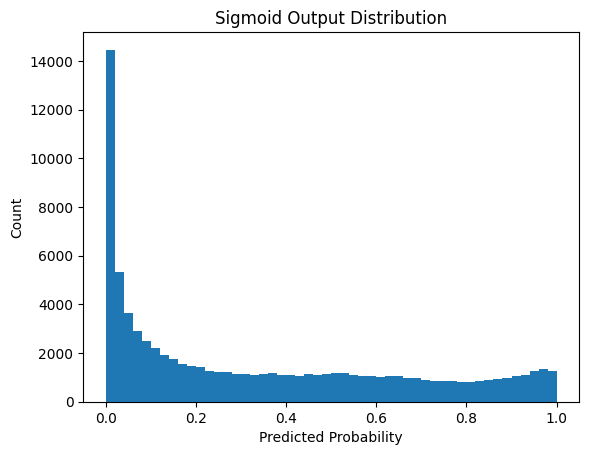

[Eval] Avg loss=0.4664 | F1_micro=0.3768 | Best_F1=0.3768 @ thr=0.30 | Avg labels/sample=22.68


 19%|█▉        | 19/100 [01:24<05:54,  4.38s/it]

Round 19/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.3768 | Best_F1: 0.3768 (thr=0.30)
[Eval Debug] Logit range: -12.55 to 8.74 | Sigmoid mean=0.339, std=0.320


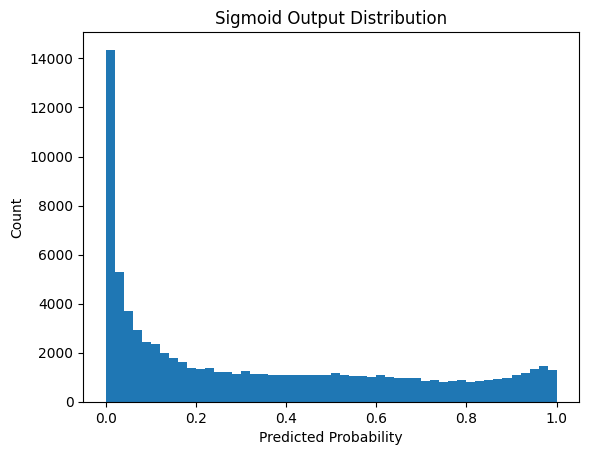

[Eval] Avg loss=0.4713 | F1_micro=0.3774 | Best_F1=0.3774 @ thr=0.30 | Avg labels/sample=22.67


 20%|██        | 20/100 [01:28<05:50,  4.38s/it]

Round 20/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.3774 | Best_F1: 0.3774 (thr=0.30)
[Eval Debug] Logit range: -13.15 to 9.21 | Sigmoid mean=0.335, std=0.321


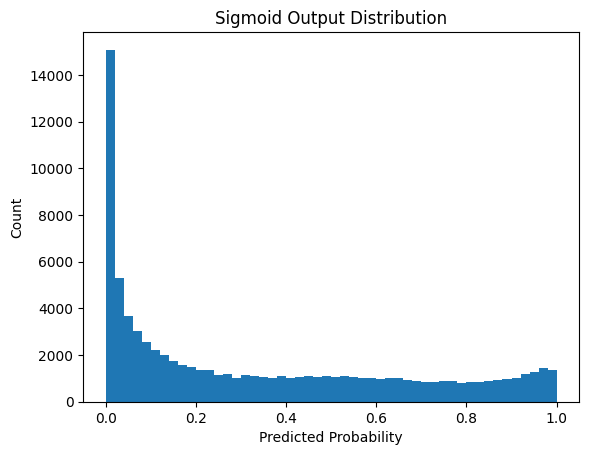

[Eval] Avg loss=0.4648 | F1_micro=0.3827 | Best_F1=0.3827 @ thr=0.30 | Avg labels/sample=22.24


 21%|██        | 21/100 [01:32<05:45,  4.37s/it]

Round 21/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.3827 | Best_F1: 0.3827 (thr=0.30)
[Eval Debug] Logit range: -13.48 to 8.68 | Sigmoid mean=0.325, std=0.318


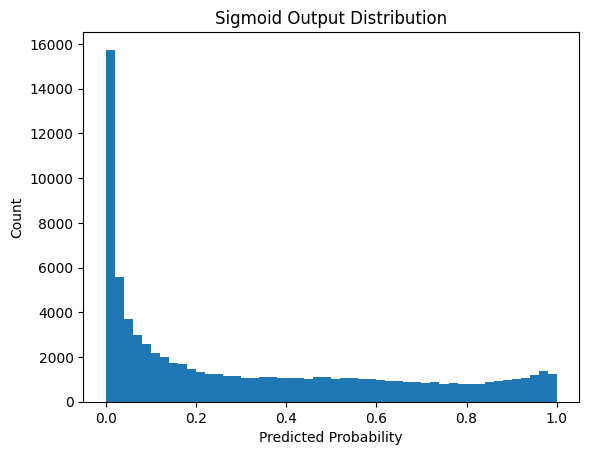

 22%|██▏       | 22/100 [01:37<05:41,  4.38s/it]

[Eval] Avg loss=0.4467 | F1_micro=0.3897 | Best_F1=0.3897 @ thr=0.30 | Avg labels/sample=21.58
Round 22/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.3897 | Best_F1: 0.3897 (thr=0.30)
[Eval Debug] Logit range: -12.57 to 10.16 | Sigmoid mean=0.331, std=0.322


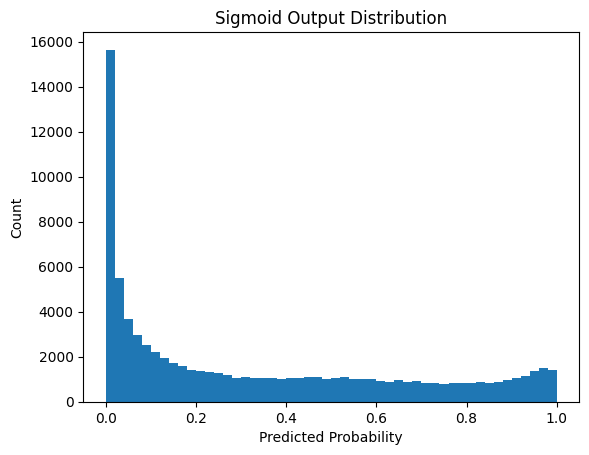

[Eval] Avg loss=0.4602 | F1_micro=0.3871 | Best_F1=0.3871 @ thr=0.30 | Avg labels/sample=21.87


 23%|██▎       | 23/100 [01:41<05:35,  4.35s/it]

Round 23/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.3871 | Best_F1: 0.3871 (thr=0.30)
[Eval Debug] Logit range: -13.37 to 9.58 | Sigmoid mean=0.326, std=0.322


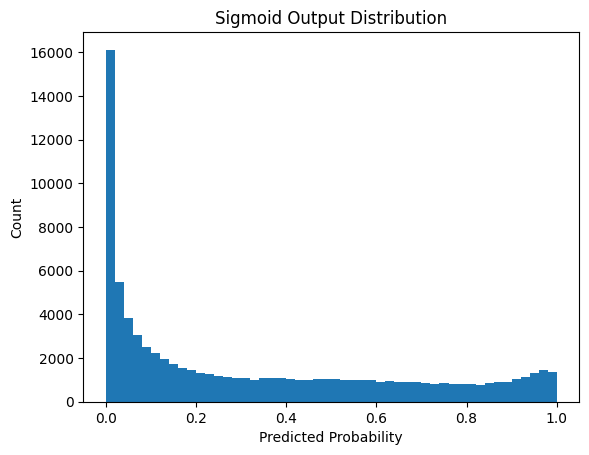

[Eval] Avg loss=0.4510 | F1_micro=0.3918 | Best_F1=0.3918 @ thr=0.30 | Avg labels/sample=21.49


 24%|██▍       | 24/100 [01:46<05:41,  4.49s/it]

Round 24/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.3918 | Best_F1: 0.3918 (thr=0.30)
[Eval Debug] Logit range: -13.13 to 9.43 | Sigmoid mean=0.323, std=0.321


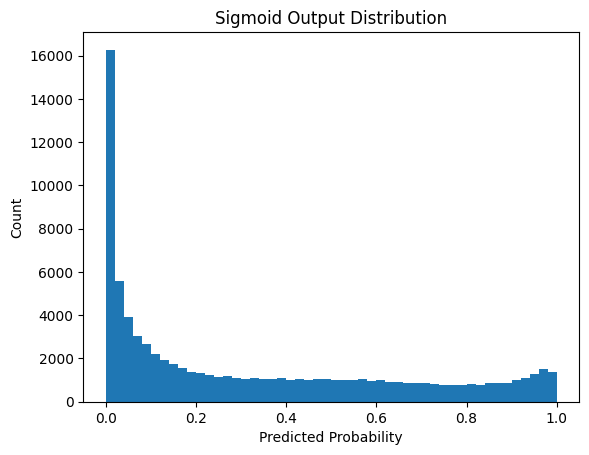

[Eval] Avg loss=0.4461 | F1_micro=0.3938 | Best_F1=0.3938 @ thr=0.30 | Avg labels/sample=21.37


 25%|██▌       | 25/100 [01:50<05:31,  4.42s/it]

Round 25/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.3938 | Best_F1: 0.3938 (thr=0.30)
[Eval Debug] Logit range: -14.59 to 10.10 | Sigmoid mean=0.324, std=0.322


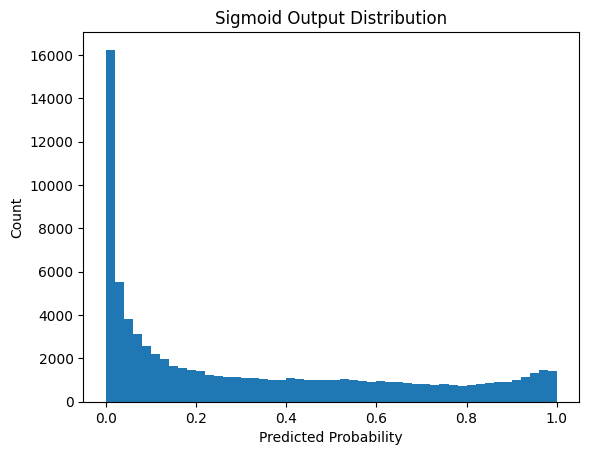

[Eval] Avg loss=0.4465 | F1_micro=0.3961 | Best_F1=0.3961 @ thr=0.30 | Avg labels/sample=21.29


 26%|██▌       | 26/100 [01:54<05:25,  4.40s/it]

Round 26/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.3961 | Best_F1: 0.3961 (thr=0.30)
[Eval Debug] Logit range: -13.73 to 10.57 | Sigmoid mean=0.323, std=0.321


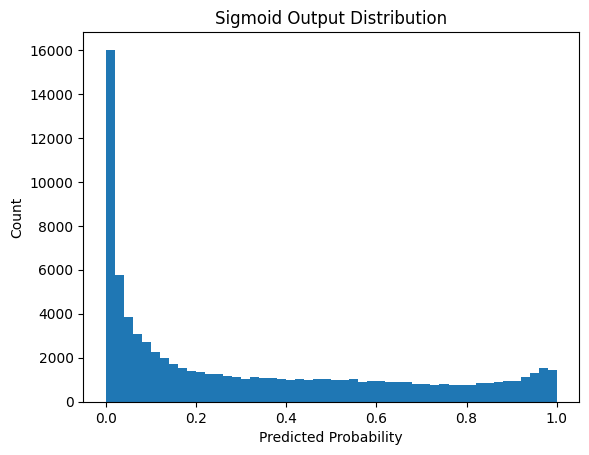

[Eval] Avg loss=0.4455 | F1_micro=0.3968 | Best_F1=0.3968 @ thr=0.30 | Avg labels/sample=21.20


 27%|██▋       | 27/100 [01:59<05:19,  4.37s/it]

Round 27/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.3968 | Best_F1: 0.3968 (thr=0.30)
[Eval Debug] Logit range: -14.01 to 10.05 | Sigmoid mean=0.320, std=0.323


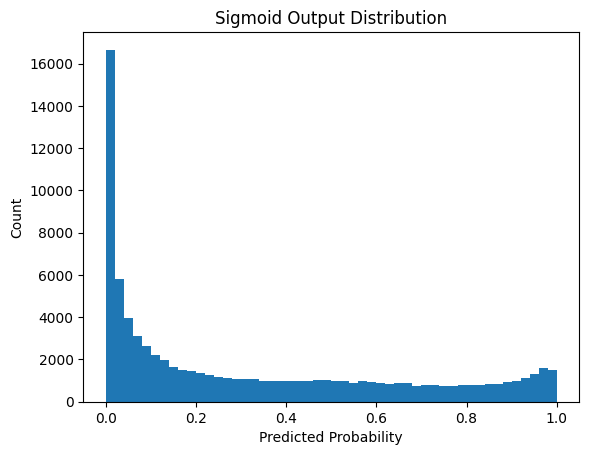

[Eval] Avg loss=0.4423 | F1_micro=0.3997 | Best_F1=0.3997 @ thr=0.30 | Avg labels/sample=20.89


 28%|██▊       | 28/100 [02:03<05:13,  4.35s/it]

Round 28/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.3997 | Best_F1: 0.3997 (thr=0.30)
[Eval Debug] Logit range: -14.43 to 10.57 | Sigmoid mean=0.315, std=0.321


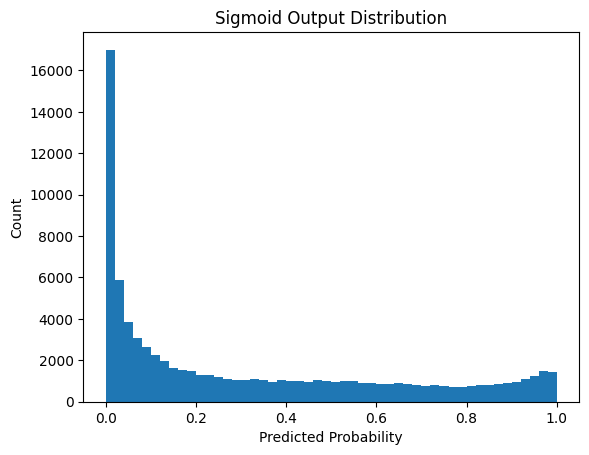

[Eval] Avg loss=0.4324 | F1_micro=0.4026 | Best_F1=0.4026 @ thr=0.30 | Avg labels/sample=20.70


 29%|██▉       | 29/100 [02:07<05:08,  4.34s/it]

Round 29/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.4026 | Best_F1: 0.4026 (thr=0.30)
[Eval Debug] Logit range: -13.79 to 10.23 | Sigmoid mean=0.318, std=0.322


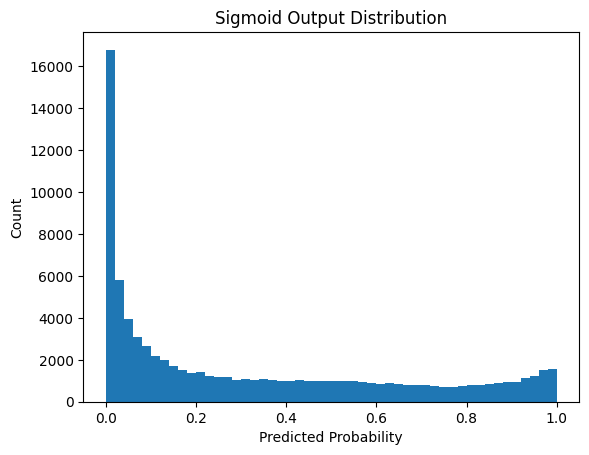

[Eval] Avg loss=0.4377 | F1_micro=0.4004 | Best_F1=0.4004 @ thr=0.30 | Avg labels/sample=20.84


 30%|███       | 30/100 [02:12<05:02,  4.31s/it]

Round 30/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.4004 | Best_F1: 0.4004 (thr=0.30)
[Eval Debug] Logit range: -13.44 to 10.64 | Sigmoid mean=0.318, std=0.323


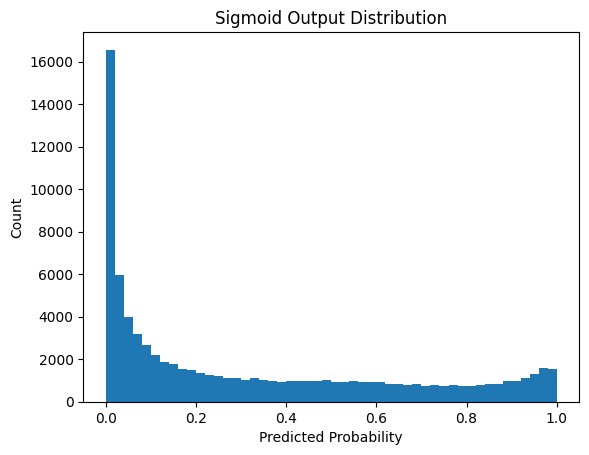

[Eval] Avg loss=0.4386 | F1_micro=0.4030 | Best_F1=0.4030 @ thr=0.30 | Avg labels/sample=20.68


 31%|███       | 31/100 [02:16<04:59,  4.33s/it]

Round 31/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.4030 | Best_F1: 0.4030 (thr=0.30)
[Eval Debug] Logit range: -13.13 to 10.98 | Sigmoid mean=0.315, std=0.323


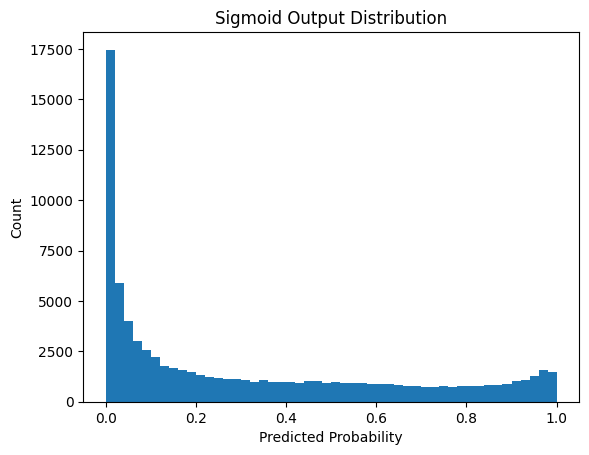

[Eval] Avg loss=0.4323 | F1_micro=0.4062 | Best_F1=0.4062 @ thr=0.30 | Avg labels/sample=20.50


 32%|███▏      | 32/100 [02:20<04:54,  4.34s/it]

Round 32/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.4062 | Best_F1: 0.4062 (thr=0.30)
[Eval Debug] Logit range: -13.76 to 10.99 | Sigmoid mean=0.315, std=0.324


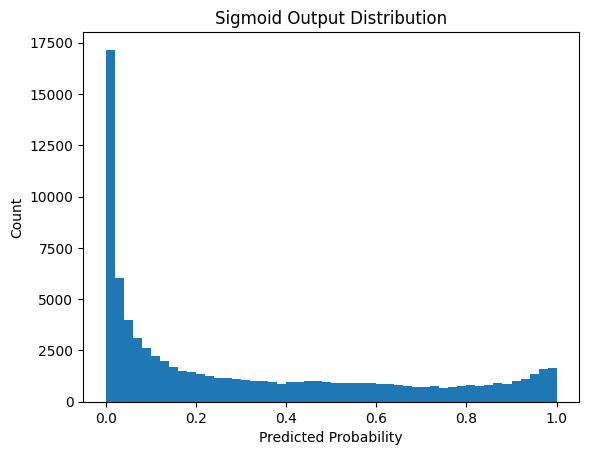

[Eval] Avg loss=0.4344 | F1_micro=0.4082 | Best_F1=0.4082 @ thr=0.30 | Avg labels/sample=20.37


 33%|███▎      | 33/100 [02:25<04:49,  4.32s/it]

Round 33/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.4082 | Best_F1: 0.4082 (thr=0.30)
[Eval Debug] Logit range: -13.34 to 10.34 | Sigmoid mean=0.316, std=0.324


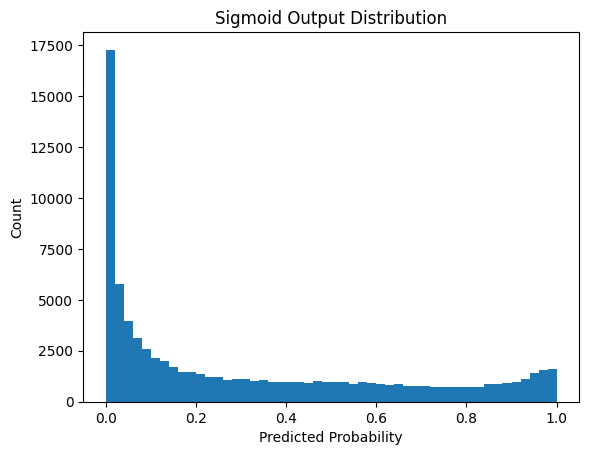

[Eval] Avg loss=0.4360 | F1_micro=0.4058 | Best_F1=0.4058 @ thr=0.30 | Avg labels/sample=20.56


 34%|███▍      | 34/100 [02:29<04:41,  4.27s/it]

Round 34/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.4058 | Best_F1: 0.4058 (thr=0.30)
[Eval Debug] Logit range: -13.76 to 10.44 | Sigmoid mean=0.314, std=0.323


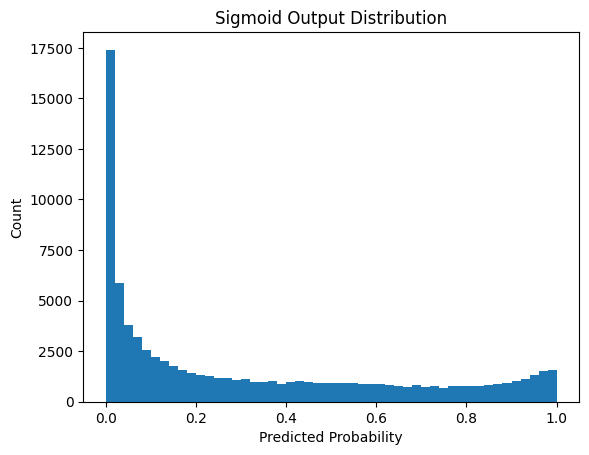

[Eval] Avg loss=0.4321 | F1_micro=0.4089 | Best_F1=0.4089 @ thr=0.30 | Avg labels/sample=20.33


 35%|███▌      | 35/100 [02:33<04:39,  4.30s/it]

Round 35/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.4089 | Best_F1: 0.4089 (thr=0.30)
[Eval Debug] Logit range: -14.42 to 11.28 | Sigmoid mean=0.313, std=0.323


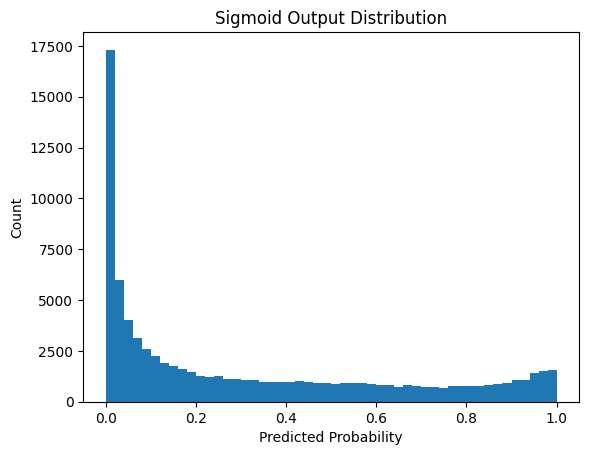

[Eval] Avg loss=0.4298 | F1_micro=0.4090 | Best_F1=0.4090 @ thr=0.30 | Avg labels/sample=20.25


 36%|███▌      | 36/100 [02:37<04:35,  4.31s/it]

Round 36/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.4090 | Best_F1: 0.4090 (thr=0.30)
[Eval Debug] Logit range: -14.39 to 10.09 | Sigmoid mean=0.311, std=0.324


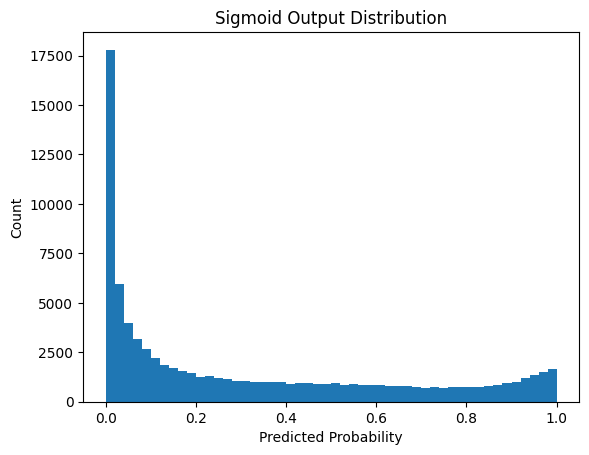

[Eval] Avg loss=0.4296 | F1_micro=0.4111 | Best_F1=0.4111 @ thr=0.30 | Avg labels/sample=20.08


 37%|███▋      | 37/100 [02:42<04:32,  4.32s/it]

Round 37/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.4111 | Best_F1: 0.4111 (thr=0.30)
[Eval Debug] Logit range: -14.15 to 10.60 | Sigmoid mean=0.310, std=0.324


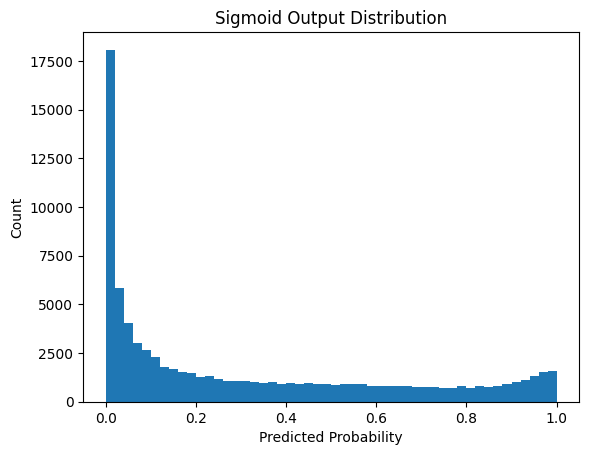

[Eval] Avg loss=0.4255 | F1_micro=0.4126 | Best_F1=0.4126 @ thr=0.30 | Avg labels/sample=20.05


 38%|███▊      | 38/100 [02:46<04:28,  4.32s/it]

Round 38/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.4126 | Best_F1: 0.4126 (thr=0.30)
[Eval Debug] Logit range: -15.07 to 10.68 | Sigmoid mean=0.307, std=0.322


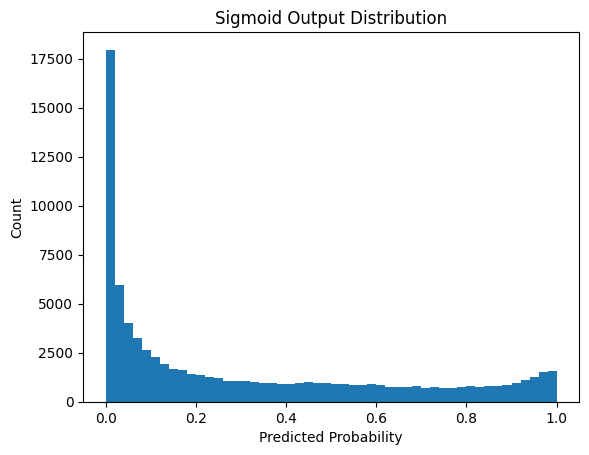

[Eval] Avg loss=0.4200 | F1_micro=0.4161 | Best_F1=0.4161 @ thr=0.30 | Avg labels/sample=19.80


 39%|███▉      | 39/100 [02:51<04:24,  4.34s/it]

Round 39/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.4161 | Best_F1: 0.4161 (thr=0.30)
[Eval Debug] Logit range: -15.26 to 11.37 | Sigmoid mean=0.310, std=0.324


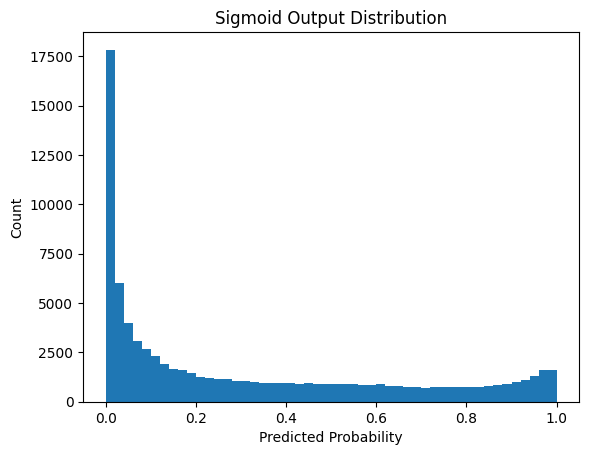

 40%|████      | 40/100 [02:55<04:19,  4.32s/it]

[Eval] Avg loss=0.4258 | F1_micro=0.4145 | Best_F1=0.4145 @ thr=0.30 | Avg labels/sample=20.00
Round 40/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.4145 | Best_F1: 0.4145 (thr=0.30)
[Eval Debug] Logit range: -14.62 to 11.29 | Sigmoid mean=0.309, std=0.324


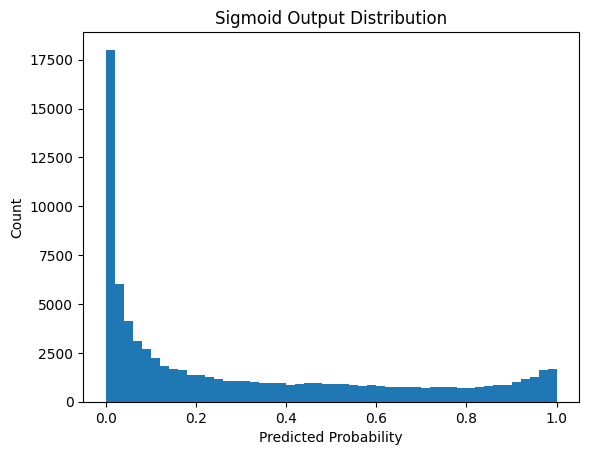

 41%|████      | 41/100 [02:59<04:15,  4.33s/it]

[Eval] Avg loss=0.4263 | F1_micro=0.4145 | Best_F1=0.4145 @ thr=0.30 | Avg labels/sample=19.89
Round 41/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.4145 | Best_F1: 0.4145 (thr=0.30)
[Eval Debug] Logit range: -14.09 to 12.75 | Sigmoid mean=0.307, std=0.324


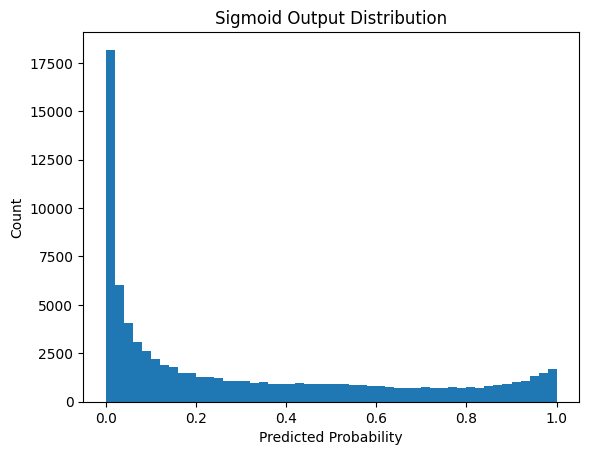

 42%|████▏     | 42/100 [03:03<04:09,  4.31s/it]

[Eval] Avg loss=0.4216 | F1_micro=0.4151 | Best_F1=0.4151 @ thr=0.30 | Avg labels/sample=19.75
Round 42/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.4151 | Best_F1: 0.4151 (thr=0.30)
[Eval Debug] Logit range: -14.51 to 10.92 | Sigmoid mean=0.307, std=0.324


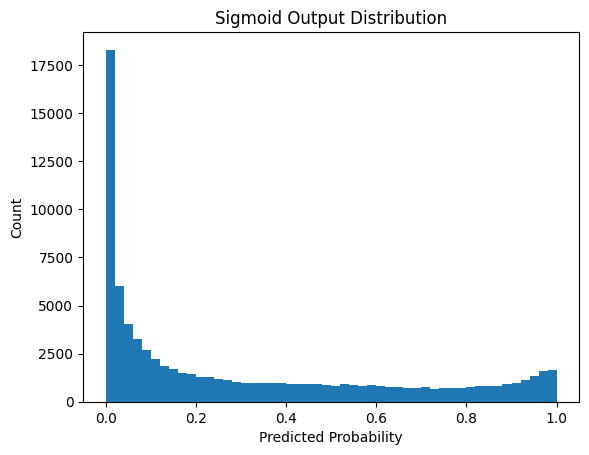

[Eval] Avg loss=0.4219 | F1_micro=0.4168 | Best_F1=0.4168 @ thr=0.30 | Avg labels/sample=19.67


 43%|████▎     | 43/100 [03:08<04:08,  4.35s/it]

Round 43/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.4168 | Best_F1: 0.4168 (thr=0.30)
[Eval Debug] Logit range: -14.75 to 11.05 | Sigmoid mean=0.306, std=0.324


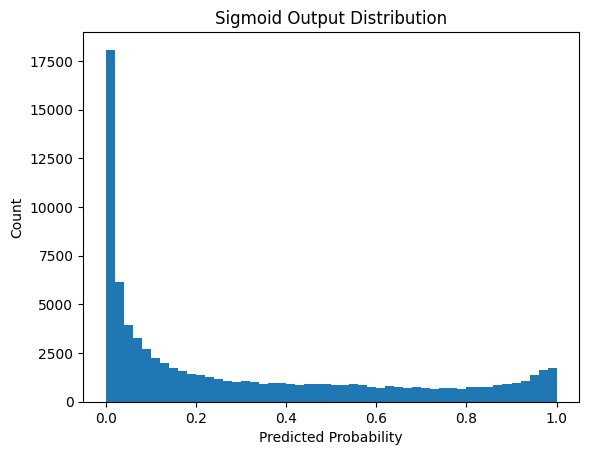

[Eval] Avg loss=0.4220 | F1_micro=0.4180 | Best_F1=0.4180 @ thr=0.30 | Avg labels/sample=19.62


 44%|████▍     | 44/100 [03:12<04:05,  4.39s/it]

Round 44/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.4180 | Best_F1: 0.4180 (thr=0.30)
[Eval Debug] Logit range: -14.88 to 11.49 | Sigmoid mean=0.305, std=0.325


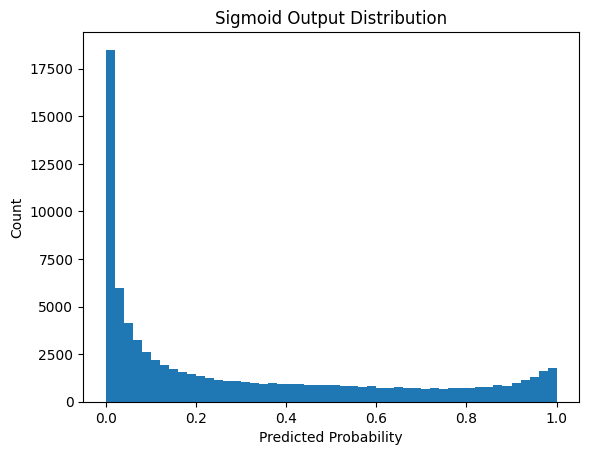

[Eval] Avg loss=0.4202 | F1_micro=0.4197 | Best_F1=0.4197 @ thr=0.30 | Avg labels/sample=19.50


 45%|████▌     | 45/100 [03:17<04:04,  4.45s/it]

Round 45/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.4197 | Best_F1: 0.4197 (thr=0.30)
[Eval Debug] Logit range: -14.95 to 13.09 | Sigmoid mean=0.308, std=0.326


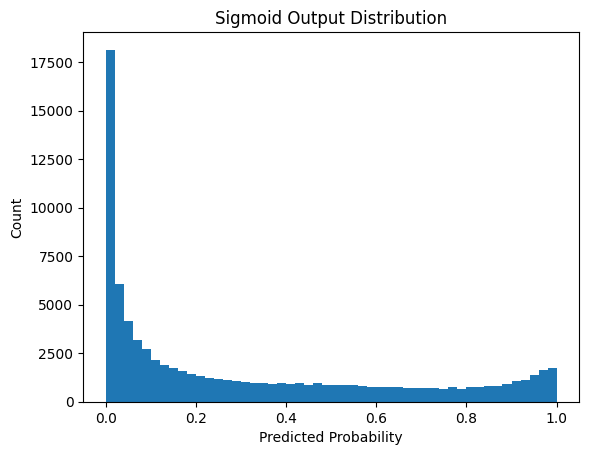

 46%|████▌     | 46/100 [03:21<03:56,  4.39s/it]

[Eval] Avg loss=0.4256 | F1_micro=0.4186 | Best_F1=0.4186 @ thr=0.30 | Avg labels/sample=19.66
Round 46/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.4186 | Best_F1: 0.4186 (thr=0.30)
[Eval Debug] Logit range: -14.65 to 12.02 | Sigmoid mean=0.301, std=0.323


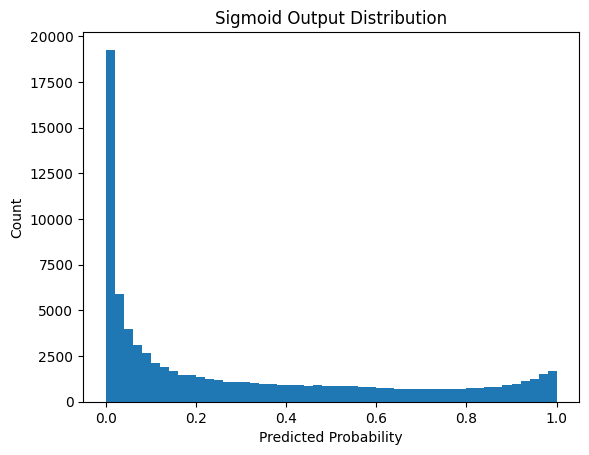

[Eval] Avg loss=0.4107 | F1_micro=0.4234 | Best_F1=0.4234 @ thr=0.30 | Avg labels/sample=19.30


 47%|████▋     | 47/100 [03:26<03:53,  4.40s/it]

Round 47/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.4234 | Best_F1: 0.4234 (thr=0.30)
[Eval Debug] Logit range: -14.83 to 11.85 | Sigmoid mean=0.303, std=0.325


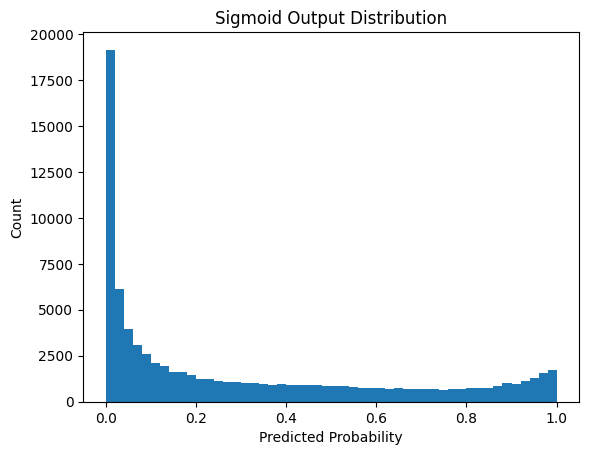

 48%|████▊     | 48/100 [03:30<03:48,  4.39s/it]

[Eval] Avg loss=0.4164 | F1_micro=0.4226 | Best_F1=0.4226 @ thr=0.30 | Avg labels/sample=19.37
Round 48/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.4226 | Best_F1: 0.4226 (thr=0.30)
[Eval Debug] Logit range: -14.64 to 12.79 | Sigmoid mean=0.303, std=0.325


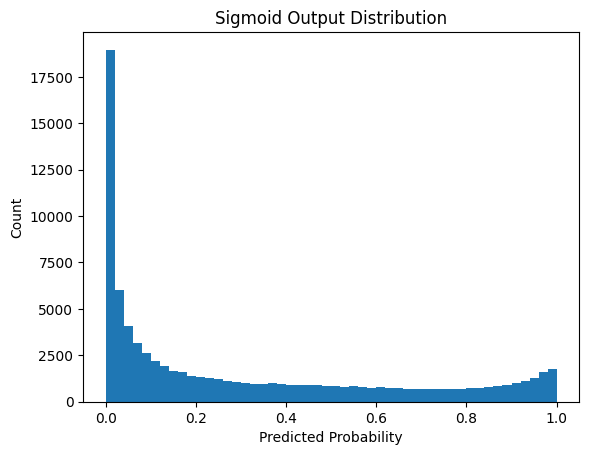

 49%|████▉     | 49/100 [03:34<03:42,  4.37s/it]

[Eval] Avg loss=0.4159 | F1_micro=0.4232 | Best_F1=0.4232 @ thr=0.30 | Avg labels/sample=19.32
Round 49/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.4232 | Best_F1: 0.4232 (thr=0.30)
[Eval Debug] Logit range: -14.85 to 13.39 | Sigmoid mean=0.304, std=0.324


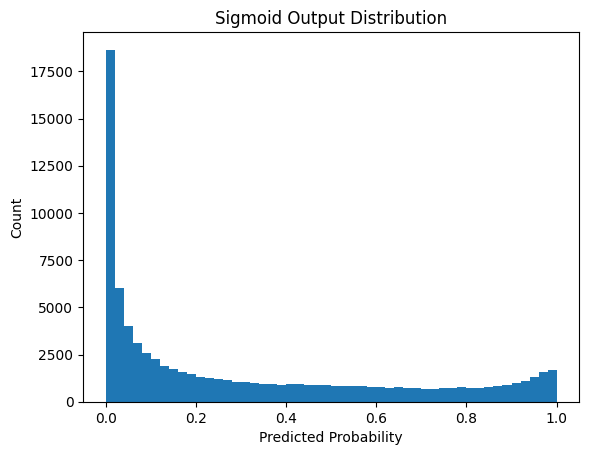

[Eval] Avg loss=0.4165 | F1_micro=0.4212 | Best_F1=0.4212 @ thr=0.30 | Avg labels/sample=19.44


 50%|█████     | 50/100 [03:39<03:38,  4.38s/it]

Round 50/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.4212 | Best_F1: 0.4212 (thr=0.30)
[Eval Debug] Logit range: -14.77 to 12.98 | Sigmoid mean=0.306, std=0.328


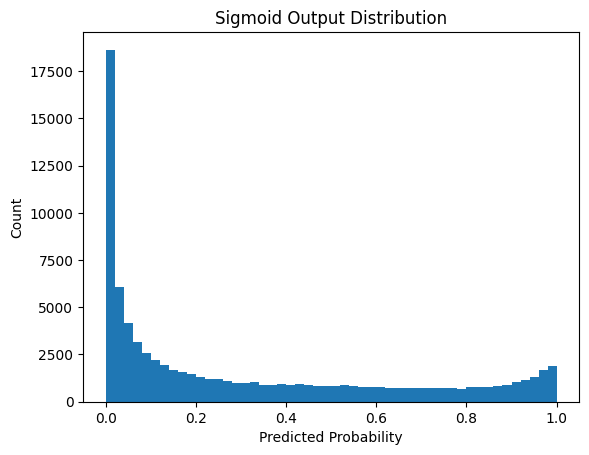

 51%|█████     | 51/100 [03:43<03:33,  4.37s/it]

[Eval] Avg loss=0.4236 | F1_micro=0.4220 | Best_F1=0.4220 @ thr=0.30 | Avg labels/sample=19.47
Round 51/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.4220 | Best_F1: 0.4220 (thr=0.30)
[Eval Debug] Logit range: -15.09 to 13.15 | Sigmoid mean=0.297, std=0.324


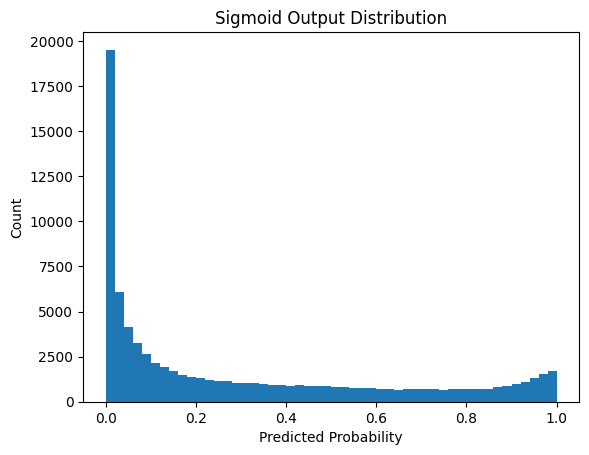

[Eval] Avg loss=0.4056 | F1_micro=0.4289 | Best_F1=0.4289 @ thr=0.30 | Avg labels/sample=18.97


 52%|█████▏    | 52/100 [03:48<03:31,  4.40s/it]

Round 52/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.4289 | Best_F1: 0.4289 (thr=0.30)
[Eval Debug] Logit range: -15.01 to 13.00 | Sigmoid mean=0.303, std=0.327


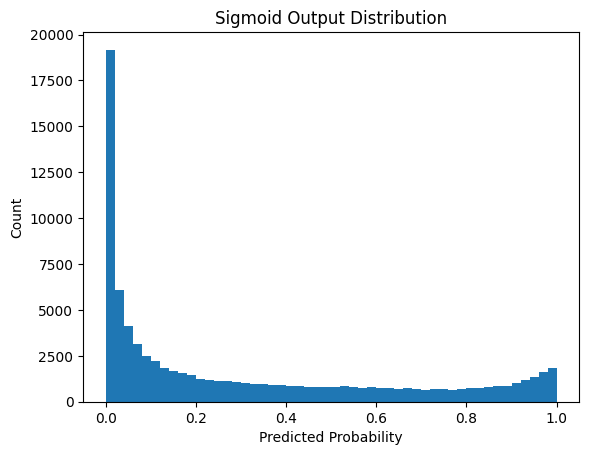

[Eval] Avg loss=0.4173 | F1_micro=0.4255 | Best_F1=0.4255 @ thr=0.30 | Avg labels/sample=19.25


 53%|█████▎    | 53/100 [03:52<03:27,  4.40s/it]

Round 53/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.4255 | Best_F1: 0.4255 (thr=0.30)
[Eval Debug] Logit range: -14.71 to 12.57 | Sigmoid mean=0.301, std=0.327


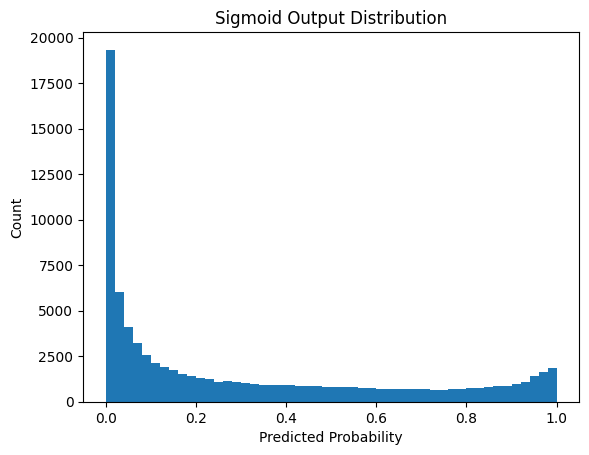

[Eval] Avg loss=0.4140 | F1_micro=0.4274 | Best_F1=0.4274 @ thr=0.30 | Avg labels/sample=19.10


 54%|█████▍    | 54/100 [03:56<03:22,  4.40s/it]

Round 54/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.4274 | Best_F1: 0.4274 (thr=0.30)
[Eval Debug] Logit range: -14.38 to 11.25 | Sigmoid mean=0.301, std=0.326


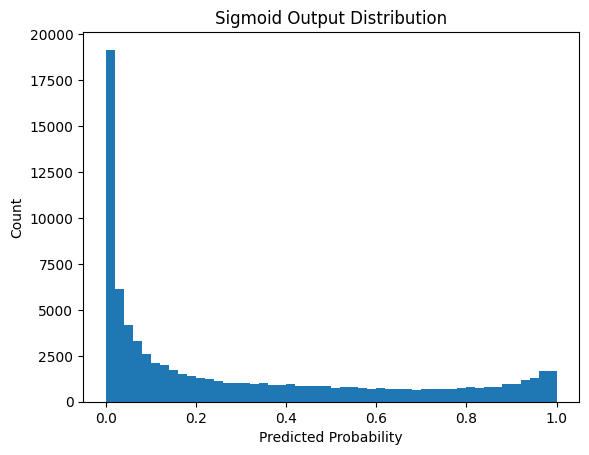

[Eval] Avg loss=0.4112 | F1_micro=0.4270 | Best_F1=0.4270 @ thr=0.30 | Avg labels/sample=19.13


 55%|█████▌    | 55/100 [04:01<03:18,  4.41s/it]

Round 55/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.4270 | Best_F1: 0.4270 (thr=0.30)
[Eval Debug] Logit range: -14.67 to 11.40 | Sigmoid mean=0.303, std=0.326


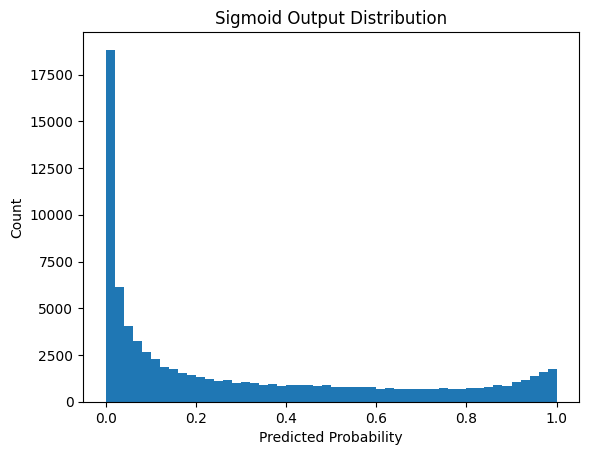

 56%|█████▌    | 56/100 [04:05<03:13,  4.40s/it]

[Eval] Avg loss=0.4152 | F1_micro=0.4249 | Best_F1=0.4249 @ thr=0.30 | Avg labels/sample=19.24
Round 56/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.4249 | Best_F1: 0.4249 (thr=0.30)
[Eval Debug] Logit range: -14.85 to 11.87 | Sigmoid mean=0.299, std=0.325


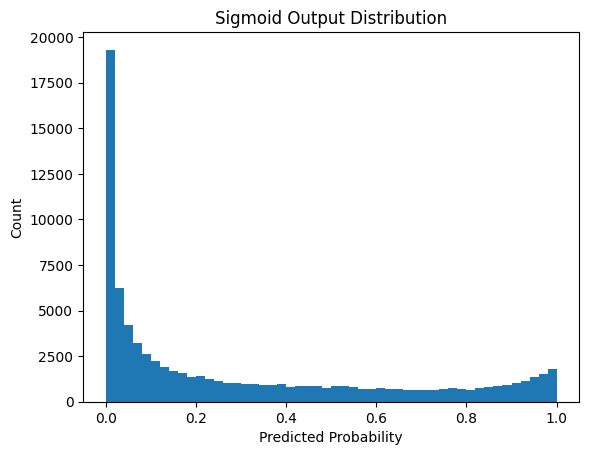

[Eval] Avg loss=0.4070 | F1_micro=0.4293 | Best_F1=0.4293 @ thr=0.30 | Avg labels/sample=18.93


 57%|█████▋    | 57/100 [04:10<03:10,  4.42s/it]

Round 57/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.4293 | Best_F1: 0.4293 (thr=0.30)
[Eval Debug] Logit range: -15.46 to 11.95 | Sigmoid mean=0.300, std=0.328


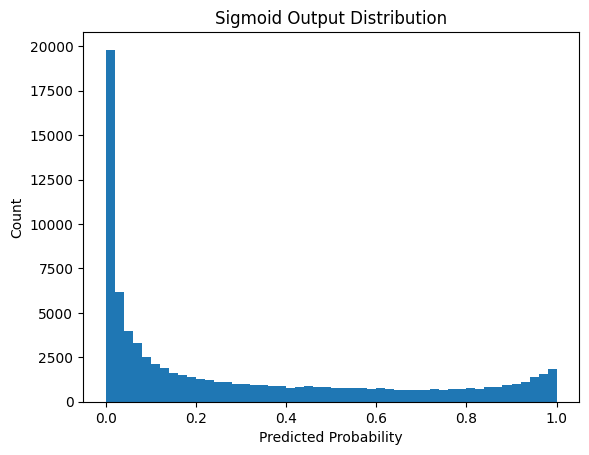

 58%|█████▊    | 58/100 [04:14<03:03,  4.36s/it]

[Eval] Avg loss=0.4133 | F1_micro=0.4286 | Best_F1=0.4286 @ thr=0.30 | Avg labels/sample=19.04
Round 58/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.4286 | Best_F1: 0.4286 (thr=0.30)
[Eval Debug] Logit range: -14.96 to 12.47 | Sigmoid mean=0.300, std=0.326


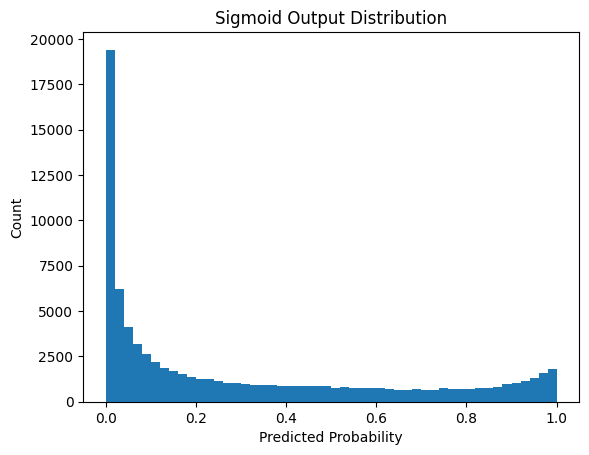

 59%|█████▉    | 59/100 [04:18<02:57,  4.33s/it]

[Eval] Avg loss=0.4101 | F1_micro=0.4287 | Best_F1=0.4287 @ thr=0.30 | Avg labels/sample=19.02
Round 59/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.4287 | Best_F1: 0.4287 (thr=0.30)
[Eval Debug] Logit range: -15.16 to 11.53 | Sigmoid mean=0.301, std=0.328


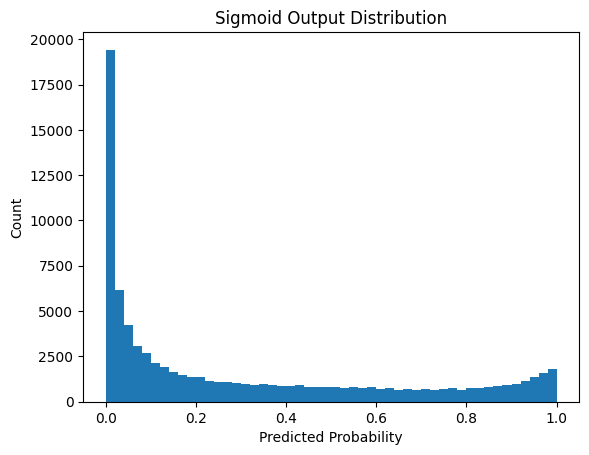

 60%|██████    | 60/100 [04:22<02:52,  4.30s/it]

[Eval] Avg loss=0.4146 | F1_micro=0.4269 | Best_F1=0.4269 @ thr=0.30 | Avg labels/sample=19.12
Round 60/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.4269 | Best_F1: 0.4269 (thr=0.30)
[Eval Debug] Logit range: -15.01 to 12.21 | Sigmoid mean=0.300, std=0.327


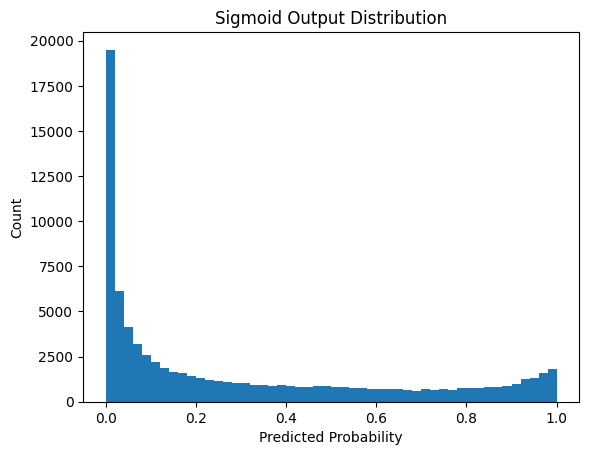

[Eval] Avg loss=0.4128 | F1_micro=0.4296 | Best_F1=0.4296 @ thr=0.30 | Avg labels/sample=18.98


 61%|██████    | 61/100 [04:27<02:49,  4.34s/it]

Round 61/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.4296 | Best_F1: 0.4296 (thr=0.30)
[Eval Debug] Logit range: -15.21 to 11.25 | Sigmoid mean=0.299, std=0.327


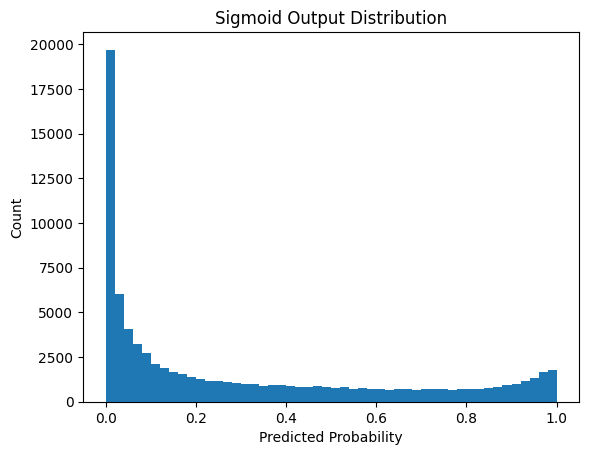

[Eval] Avg loss=0.4103 | F1_micro=0.4303 | Best_F1=0.4303 @ thr=0.30 | Avg labels/sample=18.94


 62%|██████▏   | 62/100 [04:31<02:46,  4.37s/it]

Round 62/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.4303 | Best_F1: 0.4303 (thr=0.30)
[Eval Debug] Logit range: -14.81 to 13.40 | Sigmoid mean=0.298, std=0.327


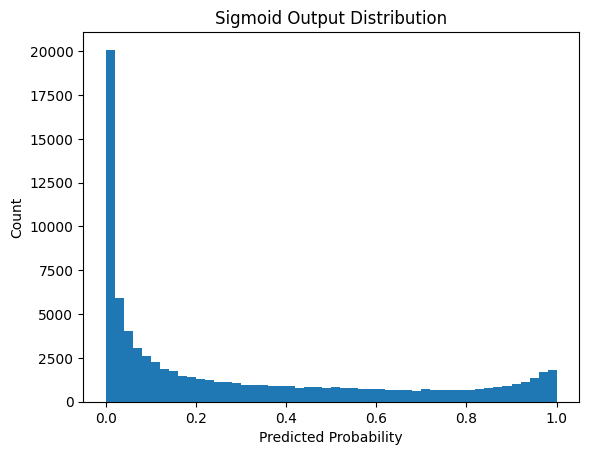

[Eval] Avg loss=0.4090 | F1_micro=0.4318 | Best_F1=0.4318 @ thr=0.30 | Avg labels/sample=18.79


 63%|██████▎   | 63/100 [04:36<02:44,  4.44s/it]

Round 63/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.4318 | Best_F1: 0.4318 (thr=0.30)
[Eval Debug] Logit range: -15.48 to 12.11 | Sigmoid mean=0.299, std=0.328


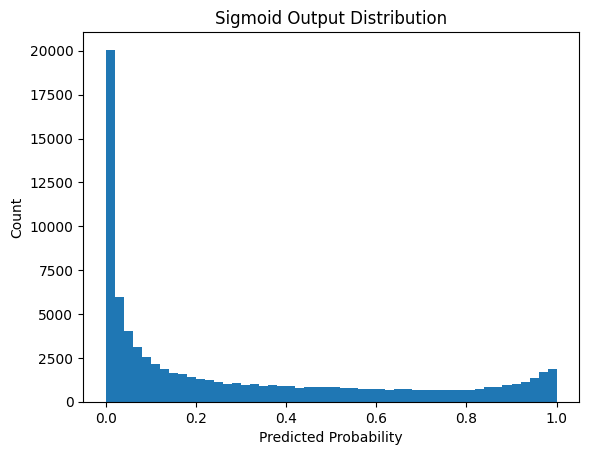

[Eval] Avg loss=0.4114 | F1_micro=0.4306 | Best_F1=0.4306 @ thr=0.30 | Avg labels/sample=18.94


 64%|██████▍   | 64/100 [04:40<02:39,  4.43s/it]

Round 64/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.4306 | Best_F1: 0.4306 (thr=0.30)
[Eval Debug] Logit range: -15.58 to 11.18 | Sigmoid mean=0.298, std=0.326


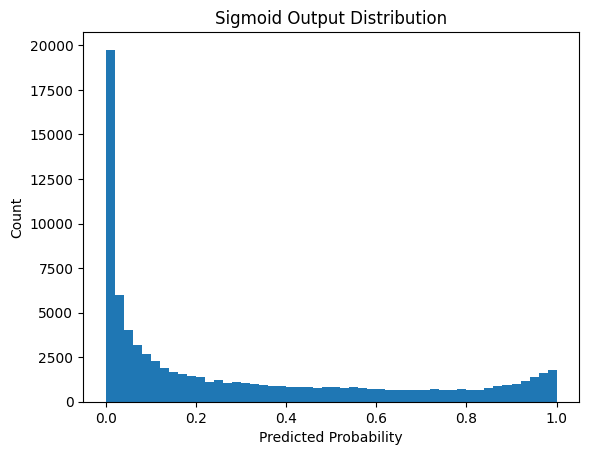

[Eval] Avg loss=0.4081 | F1_micro=0.4308 | Best_F1=0.4308 @ thr=0.30 | Avg labels/sample=18.83


 65%|██████▌   | 65/100 [04:45<02:34,  4.42s/it]

Round 65/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.4308 | Best_F1: 0.4308 (thr=0.30)
[Eval Debug] Logit range: -16.53 to 12.71 | Sigmoid mean=0.300, std=0.329


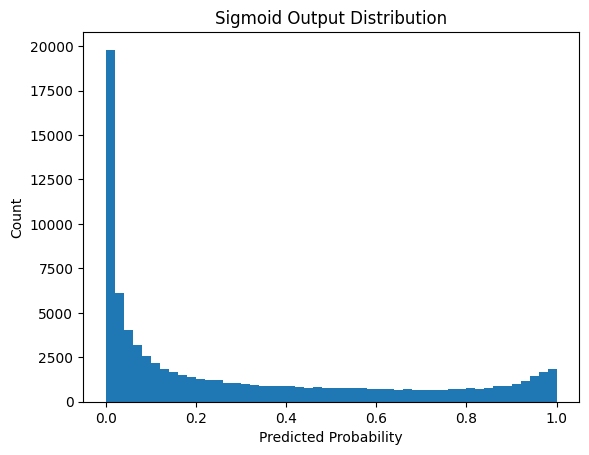

 66%|██████▌   | 66/100 [04:49<02:28,  4.38s/it]

[Eval] Avg loss=0.4149 | F1_micro=0.4305 | Best_F1=0.4305 @ thr=0.30 | Avg labels/sample=18.92
Round 66/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.4305 | Best_F1: 0.4305 (thr=0.30)
[Eval Debug] Logit range: -15.09 to 12.42 | Sigmoid mean=0.302, std=0.329


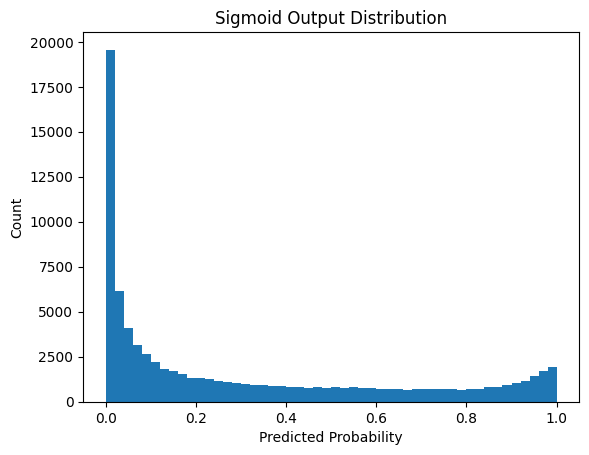

[Eval] Avg loss=0.4185 | F1_micro=0.4286 | Best_F1=0.4286 @ thr=0.30 | Avg labels/sample=19.02


 67%|██████▋   | 67/100 [04:53<02:24,  4.39s/it]

Round 67/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.4286 | Best_F1: 0.4286 (thr=0.30)
[Eval Debug] Logit range: -15.48 to 10.94 | Sigmoid mean=0.297, std=0.327


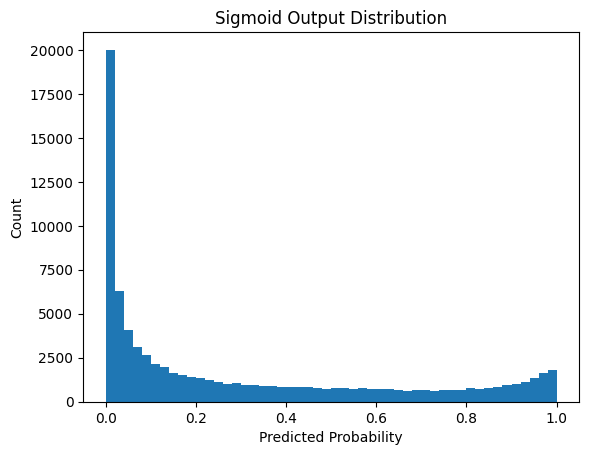

[Eval] Avg loss=0.4073 | F1_micro=0.4337 | Best_F1=0.4337 @ thr=0.30 | Avg labels/sample=18.68


 68%|██████▊   | 68/100 [04:58<02:20,  4.40s/it]

Round 68/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.4337 | Best_F1: 0.4337 (thr=0.30)
[Eval Debug] Logit range: -15.87 to 12.46 | Sigmoid mean=0.296, std=0.329


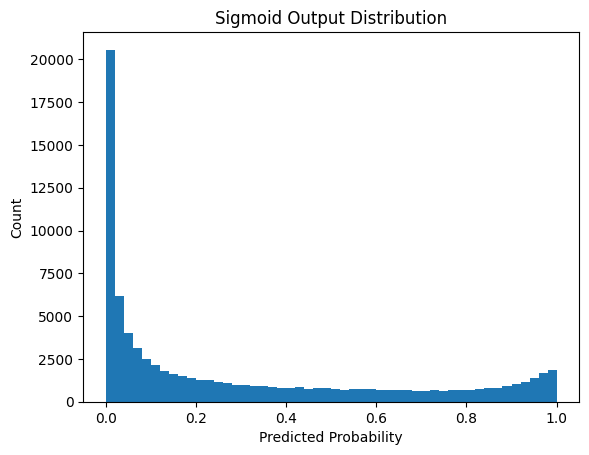

[Eval] Avg loss=0.4084 | F1_micro=0.4358 | Best_F1=0.4358 @ thr=0.30 | Avg labels/sample=18.61


 69%|██████▉   | 69/100 [05:02<02:16,  4.41s/it]

Round 69/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.4358 | Best_F1: 0.4358 (thr=0.30)
[Eval Debug] Logit range: -15.35 to 11.35 | Sigmoid mean=0.297, std=0.328


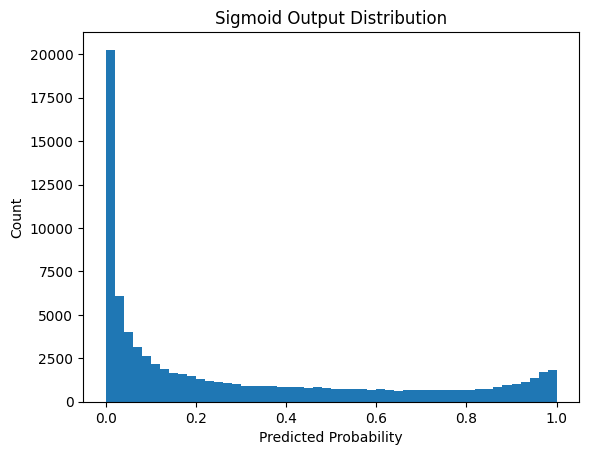

 70%|███████   | 70/100 [05:07<02:11,  4.39s/it]

[Eval] Avg loss=0.4081 | F1_micro=0.4353 | Best_F1=0.4353 @ thr=0.30 | Avg labels/sample=18.62
Round 70/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.4353 | Best_F1: 0.4353 (thr=0.30)
[Eval Debug] Logit range: -16.13 to 12.22 | Sigmoid mean=0.300, std=0.329


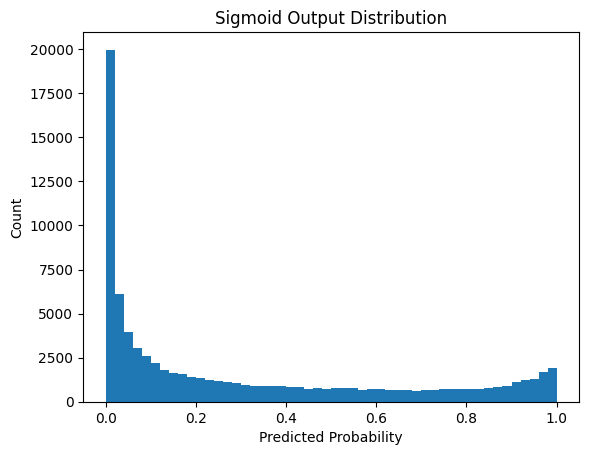

 71%|███████   | 71/100 [05:11<02:07,  4.38s/it]

[Eval] Avg loss=0.4144 | F1_micro=0.4329 | Best_F1=0.4329 @ thr=0.30 | Avg labels/sample=18.81
Round 71/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.4329 | Best_F1: 0.4329 (thr=0.30)
[Eval Debug] Logit range: -15.49 to 13.27 | Sigmoid mean=0.297, std=0.329


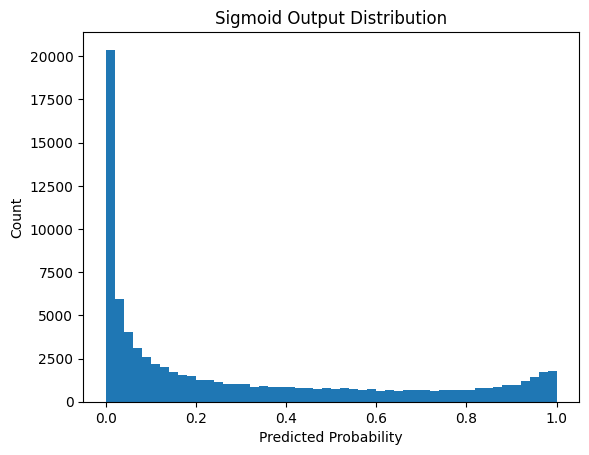

[Eval] Avg loss=0.4075 | F1_micro=0.4366 | Best_F1=0.4366 @ thr=0.30 | Avg labels/sample=18.55


 72%|███████▏  | 72/100 [05:15<02:03,  4.41s/it]

Round 72/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.4366 | Best_F1: 0.4366 (thr=0.30)
[Eval Debug] Logit range: -15.73 to 13.33 | Sigmoid mean=0.297, std=0.329


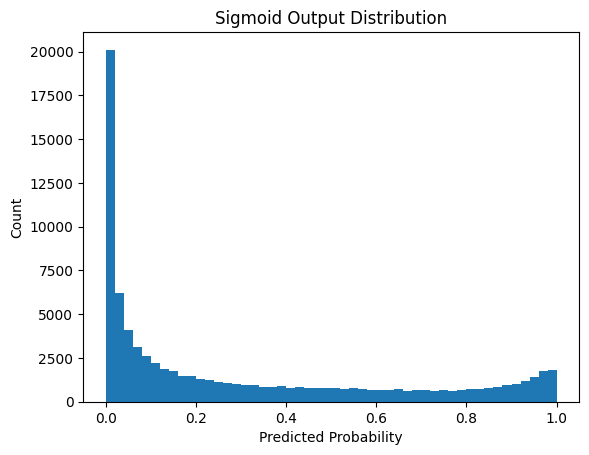

[Eval] Avg loss=0.4070 | F1_micro=0.4372 | Best_F1=0.4372 @ thr=0.30 | Avg labels/sample=18.55


 73%|███████▎  | 73/100 [05:20<01:59,  4.42s/it]

Round 73/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.4372 | Best_F1: 0.4372 (thr=0.30)
[Eval Debug] Logit range: -15.42 to 13.25 | Sigmoid mean=0.293, std=0.327


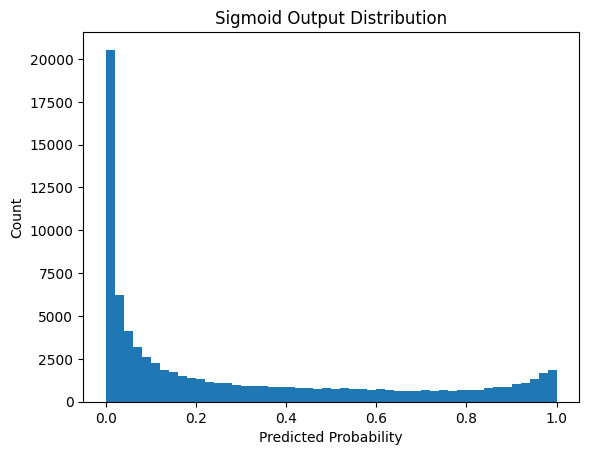

[Eval] Avg loss=0.4009 | F1_micro=0.4386 | Best_F1=0.4386 @ thr=0.30 | Avg labels/sample=18.39


 74%|███████▍  | 74/100 [05:24<01:54,  4.41s/it]

Round 74/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.4386 | Best_F1: 0.4386 (thr=0.30)
[Eval Debug] Logit range: -16.18 to 12.51 | Sigmoid mean=0.290, std=0.327


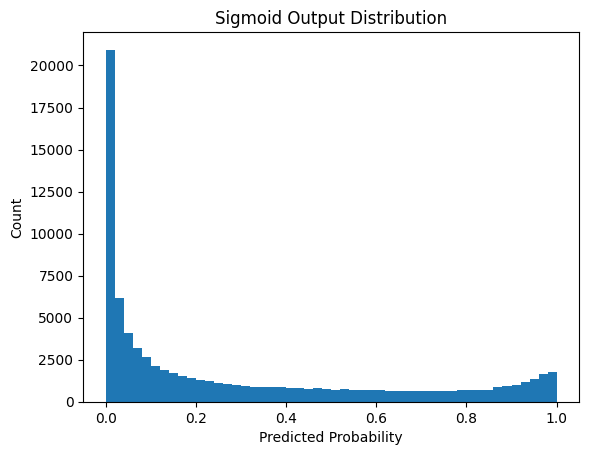

[Eval] Avg loss=0.3960 | F1_micro=0.4446 | Best_F1=0.4446 @ thr=0.30 | Avg labels/sample=18.11


 75%|███████▌  | 75/100 [05:29<01:51,  4.47s/it]

Round 75/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.4446 | Best_F1: 0.4446 (thr=0.30)
[Eval Debug] Logit range: -15.44 to 13.79 | Sigmoid mean=0.295, std=0.329


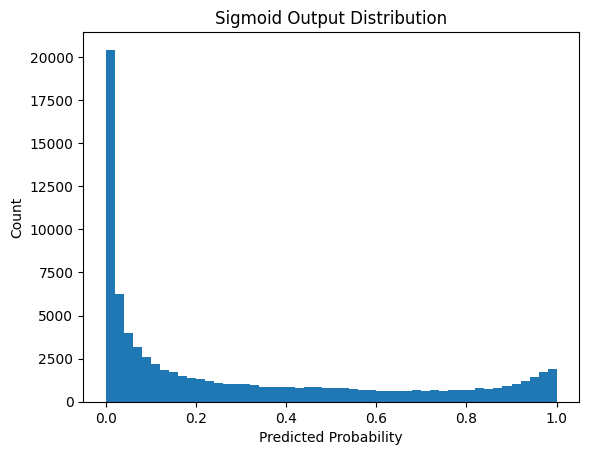

[Eval] Avg loss=0.4068 | F1_micro=0.4369 | Best_F1=0.4369 @ thr=0.30 | Avg labels/sample=18.55


 76%|███████▌  | 76/100 [05:33<01:47,  4.47s/it]

Round 76/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.4369 | Best_F1: 0.4369 (thr=0.30)
[Eval Debug] Logit range: -15.95 to 14.80 | Sigmoid mean=0.293, std=0.327


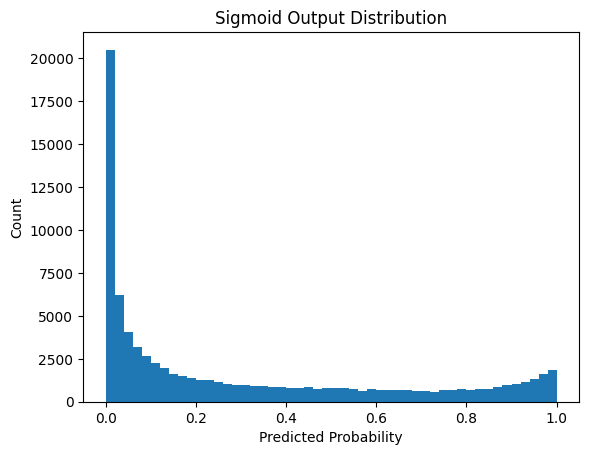

 77%|███████▋  | 77/100 [05:38<01:41,  4.43s/it]

[Eval] Avg loss=0.4004 | F1_micro=0.4394 | Best_F1=0.4394 @ thr=0.30 | Avg labels/sample=18.36
Round 77/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.4394 | Best_F1: 0.4394 (thr=0.30)
[Eval Debug] Logit range: -16.00 to 13.67 | Sigmoid mean=0.294, std=0.328


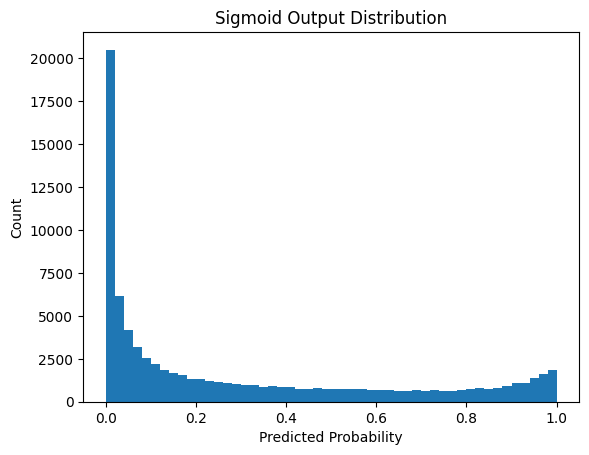

 78%|███████▊  | 78/100 [05:42<01:36,  4.39s/it]

[Eval] Avg loss=0.4012 | F1_micro=0.4395 | Best_F1=0.4395 @ thr=0.30 | Avg labels/sample=18.40
Round 78/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.4395 | Best_F1: 0.4395 (thr=0.30)
[Eval Debug] Logit range: -15.56 to 12.91 | Sigmoid mean=0.294, std=0.327


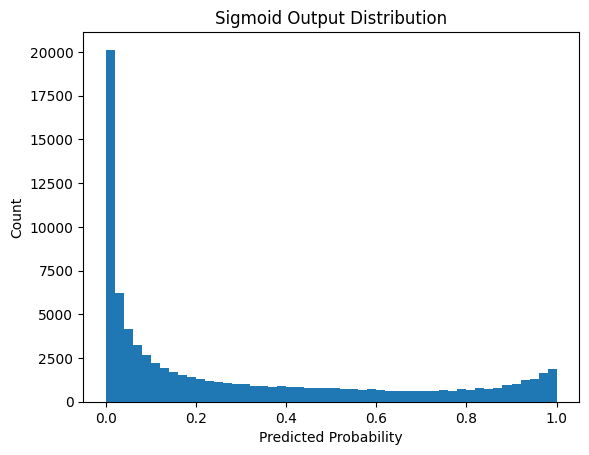

 79%|███████▉  | 79/100 [05:46<01:32,  4.42s/it]

[Eval] Avg loss=0.4013 | F1_micro=0.4401 | Best_F1=0.4401 @ thr=0.30 | Avg labels/sample=18.38
Round 79/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.4401 | Best_F1: 0.4401 (thr=0.30)
[Eval Debug] Logit range: -15.29 to 13.42 | Sigmoid mean=0.292, std=0.328


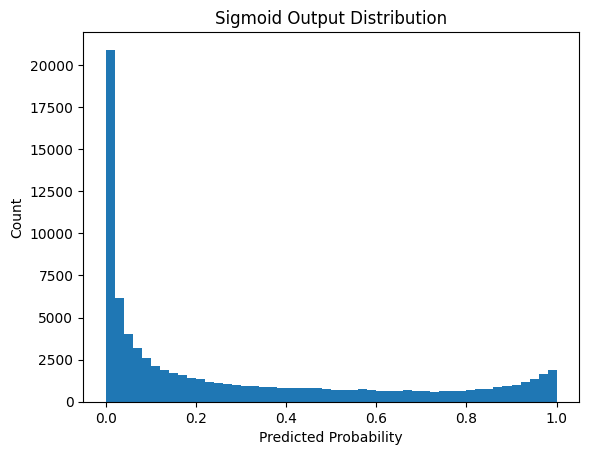

 80%|████████  | 80/100 [05:51<01:27,  4.38s/it]

[Eval] Avg loss=0.4000 | F1_micro=0.4421 | Best_F1=0.4421 @ thr=0.30 | Avg labels/sample=18.25
Round 80/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.4421 | Best_F1: 0.4421 (thr=0.30)
[Eval Debug] Logit range: -15.21 to 11.90 | Sigmoid mean=0.291, std=0.328


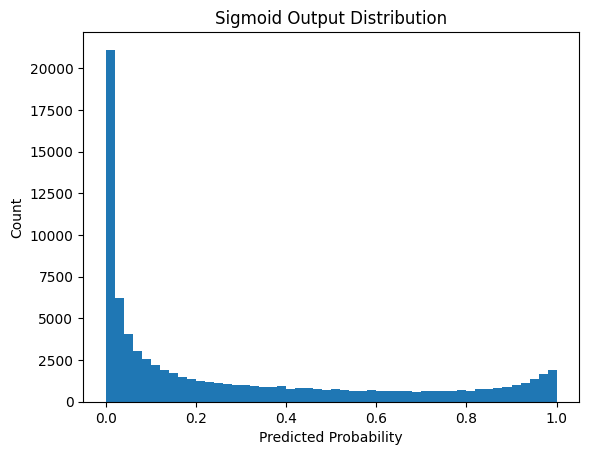

 81%|████████  | 81/100 [05:55<01:22,  4.35s/it]

[Eval] Avg loss=0.3989 | F1_micro=0.4423 | Best_F1=0.4423 @ thr=0.30 | Avg labels/sample=18.19
Round 81/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.4423 | Best_F1: 0.4423 (thr=0.30)
[Eval Debug] Logit range: -15.59 to 11.52 | Sigmoid mean=0.293, std=0.329


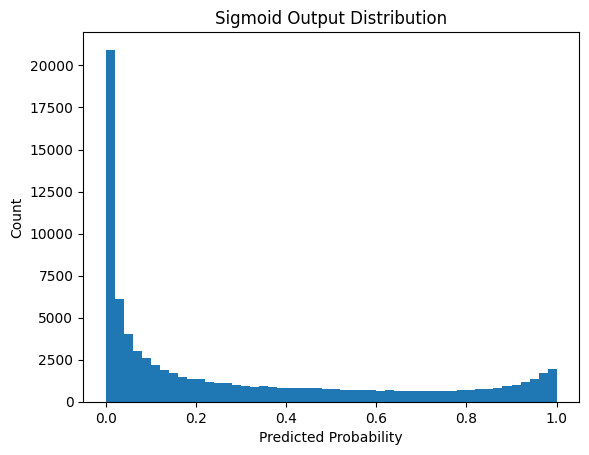

[Eval] Avg loss=0.4016 | F1_micro=0.4408 | Best_F1=0.4408 @ thr=0.30 | Avg labels/sample=18.33


 82%|████████▏ | 82/100 [05:59<01:18,  4.37s/it]

Round 82/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.4408 | Best_F1: 0.4408 (thr=0.30)
[Eval Debug] Logit range: -15.50 to 12.55 | Sigmoid mean=0.292, std=0.328


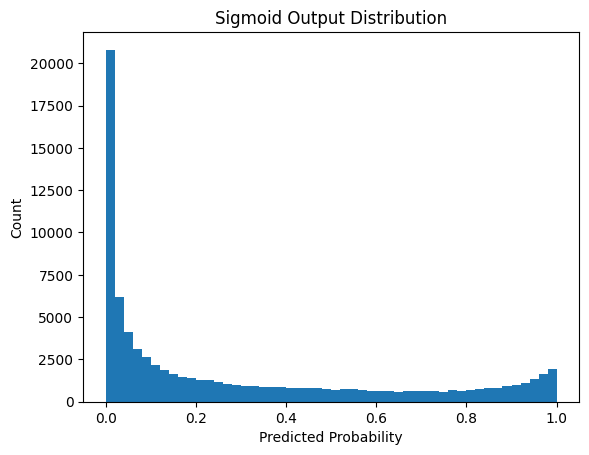

 83%|████████▎ | 83/100 [06:04<01:13,  4.35s/it]

[Eval] Avg loss=0.4003 | F1_micro=0.4418 | Best_F1=0.4418 @ thr=0.30 | Avg labels/sample=18.26
Round 83/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.4418 | Best_F1: 0.4418 (thr=0.30)
[Eval Debug] Logit range: -15.63 to 12.15 | Sigmoid mean=0.293, std=0.329


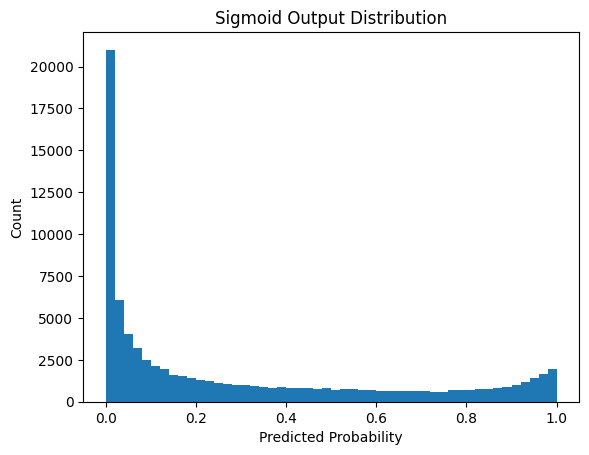

 84%|████████▍ | 84/100 [06:08<01:09,  4.33s/it]

[Eval] Avg loss=0.4035 | F1_micro=0.4407 | Best_F1=0.4407 @ thr=0.30 | Avg labels/sample=18.32
Round 84/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.4407 | Best_F1: 0.4407 (thr=0.30)
[Eval Debug] Logit range: -16.07 to 12.75 | Sigmoid mean=0.291, std=0.327


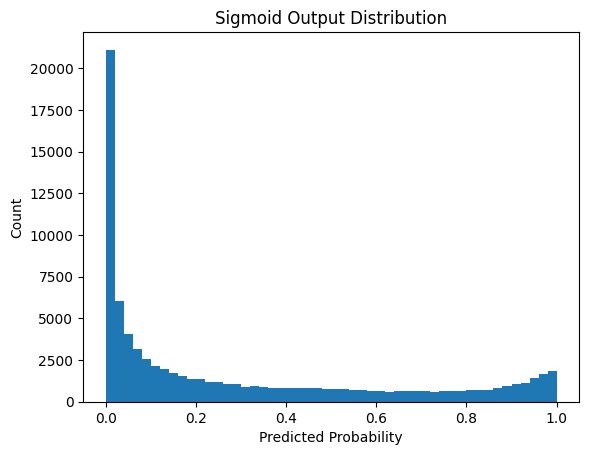

 85%|████████▌ | 85/100 [06:12<01:04,  4.31s/it]

[Eval] Avg loss=0.3970 | F1_micro=0.4436 | Best_F1=0.4436 @ thr=0.30 | Avg labels/sample=18.13
Round 85/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.4436 | Best_F1: 0.4436 (thr=0.30)
[Eval Debug] Logit range: -15.93 to 12.98 | Sigmoid mean=0.286, std=0.326


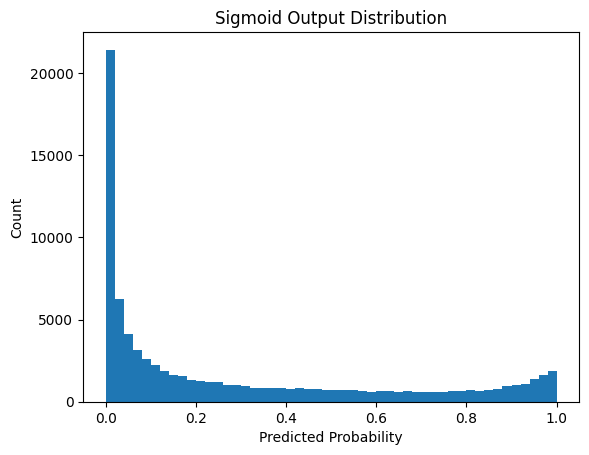

[Eval] Avg loss=0.3902 | F1_micro=0.4482 | Best_F1=0.4482 @ thr=0.30 | Avg labels/sample=17.79


 86%|████████▌ | 86/100 [06:17<01:01,  4.37s/it]

Round 86/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.4482 | Best_F1: 0.4482 (thr=0.30)
[Eval Debug] Logit range: -16.14 to 12.98 | Sigmoid mean=0.292, std=0.327


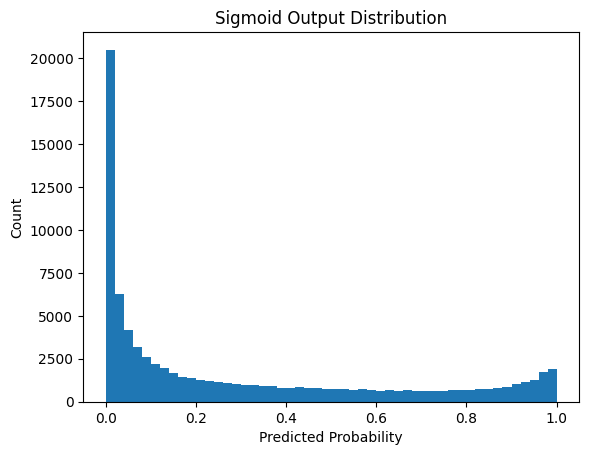

 87%|████████▋ | 87/100 [06:21<00:56,  4.33s/it]

[Eval] Avg loss=0.3996 | F1_micro=0.4403 | Best_F1=0.4403 @ thr=0.30 | Avg labels/sample=18.28
Round 87/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.4403 | Best_F1: 0.4403 (thr=0.30)
[Eval Debug] Logit range: -15.84 to 12.84 | Sigmoid mean=0.290, std=0.329


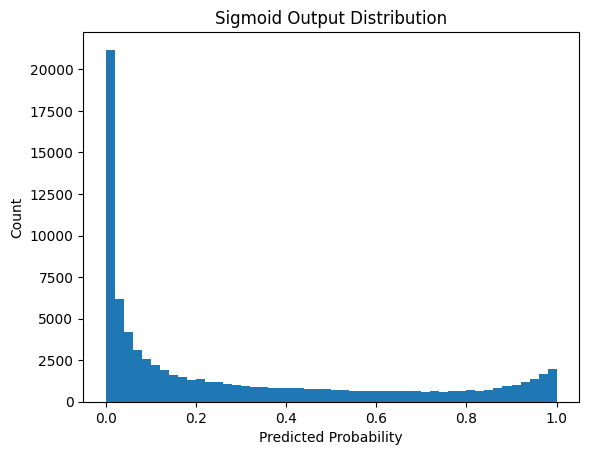

[Eval] Avg loss=0.3960 | F1_micro=0.4465 | Best_F1=0.4465 @ thr=0.30 | Avg labels/sample=18.00


 88%|████████▊ | 88/100 [06:25<00:52,  4.35s/it]

Round 88/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.4465 | Best_F1: 0.4465 (thr=0.30)
[Eval Debug] Logit range: -16.56 to 12.52 | Sigmoid mean=0.288, std=0.328


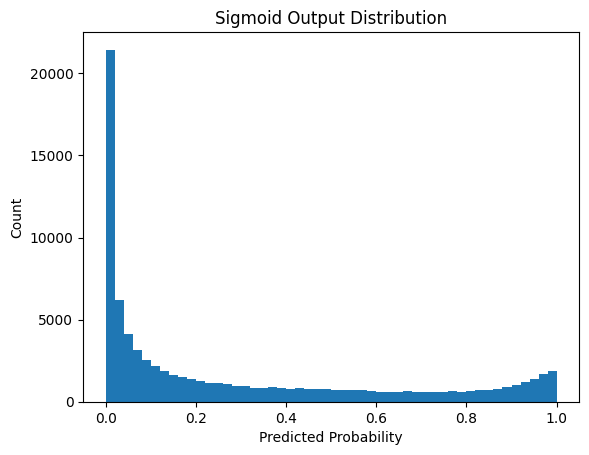

[Eval] Avg loss=0.3934 | F1_micro=0.4482 | Best_F1=0.4482 @ thr=0.30 | Avg labels/sample=17.93


 89%|████████▉ | 89/100 [06:30<00:47,  4.34s/it]

Round 89/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.4482 | Best_F1: 0.4482 (thr=0.30)
[Eval Debug] Logit range: -15.76 to 13.72 | Sigmoid mean=0.290, std=0.329


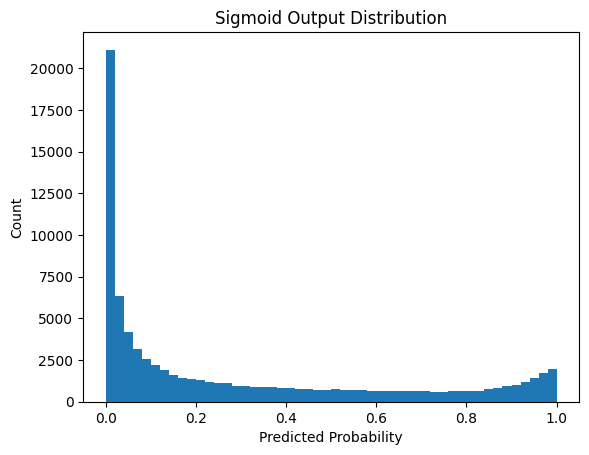

 90%|█████████ | 90/100 [06:34<00:43,  4.32s/it]

[Eval] Avg loss=0.3983 | F1_micro=0.4457 | Best_F1=0.4457 @ thr=0.30 | Avg labels/sample=18.04
Round 90/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.4457 | Best_F1: 0.4457 (thr=0.30)
[Eval Debug] Logit range: -15.71 to 13.56 | Sigmoid mean=0.291, std=0.329


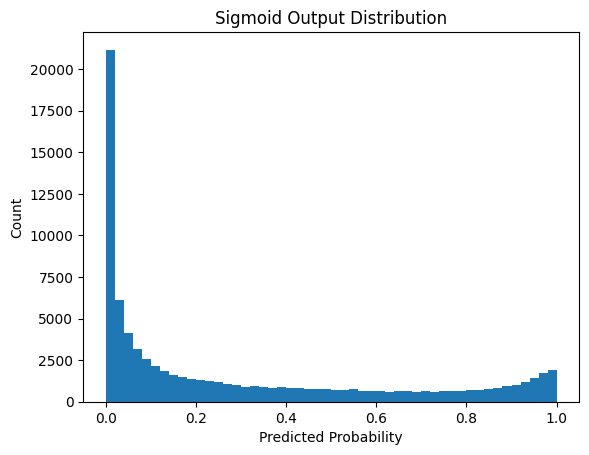

 91%|█████████ | 91/100 [06:38<00:38,  4.30s/it]

[Eval] Avg loss=0.3998 | F1_micro=0.4453 | Best_F1=0.4453 @ thr=0.30 | Avg labels/sample=18.12
Round 91/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.4453 | Best_F1: 0.4453 (thr=0.30)
[Eval Debug] Logit range: -15.61 to 12.67 | Sigmoid mean=0.294, std=0.330


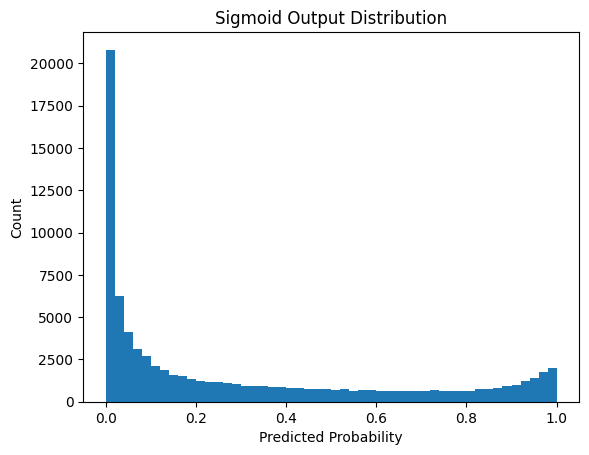

 92%|█████████▏| 92/100 [06:42<00:34,  4.29s/it]

[Eval] Avg loss=0.4043 | F1_micro=0.4422 | Best_F1=0.4422 @ thr=0.30 | Avg labels/sample=18.31
Round 92/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.4422 | Best_F1: 0.4422 (thr=0.30)
[Eval Debug] Logit range: -15.57 to 13.08 | Sigmoid mean=0.292, std=0.329


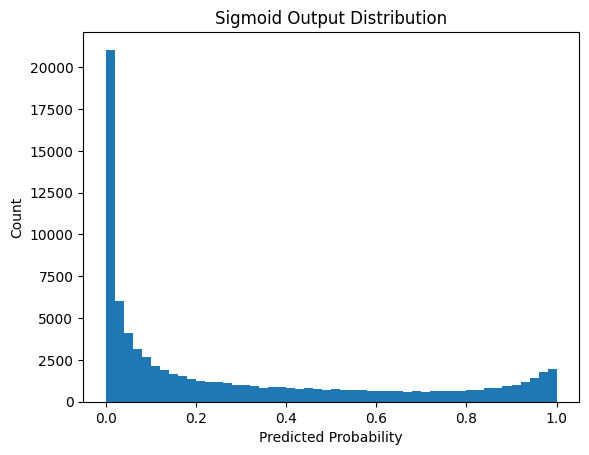

 93%|█████████▎| 93/100 [06:47<00:30,  4.29s/it]

[Eval] Avg loss=0.4023 | F1_micro=0.4449 | Best_F1=0.4449 @ thr=0.30 | Avg labels/sample=18.21
Round 93/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.4449 | Best_F1: 0.4449 (thr=0.30)
[Eval Debug] Logit range: -15.36 to 13.15 | Sigmoid mean=0.293, std=0.330


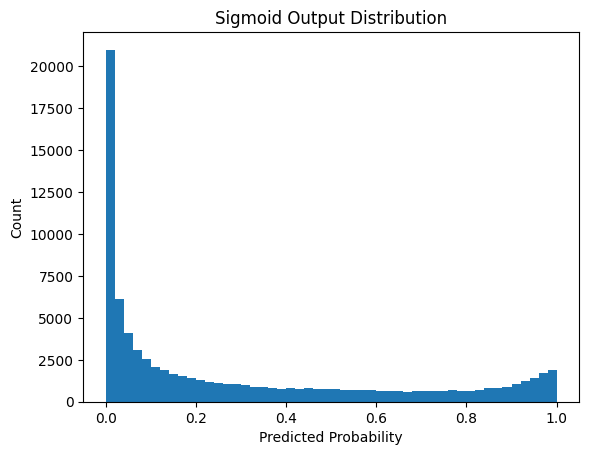

 94%|█████████▍| 94/100 [06:51<00:25,  4.29s/it]

[Eval] Avg loss=0.4038 | F1_micro=0.4428 | Best_F1=0.4428 @ thr=0.30 | Avg labels/sample=18.28
Round 94/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.4428 | Best_F1: 0.4428 (thr=0.30)
[Eval Debug] Logit range: -16.10 to 13.98 | Sigmoid mean=0.294, std=0.330


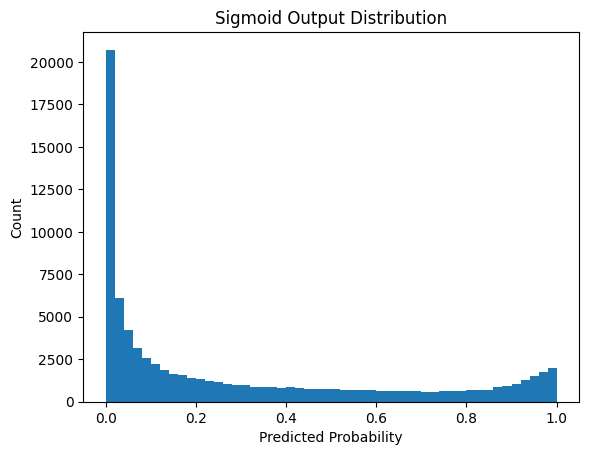

 95%|█████████▌| 95/100 [06:55<00:21,  4.29s/it]

[Eval] Avg loss=0.4047 | F1_micro=0.4435 | Best_F1=0.4435 @ thr=0.30 | Avg labels/sample=18.24
Round 95/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.4435 | Best_F1: 0.4435 (thr=0.30)
[Eval Debug] Logit range: -14.88 to 13.94 | Sigmoid mean=0.293, std=0.330


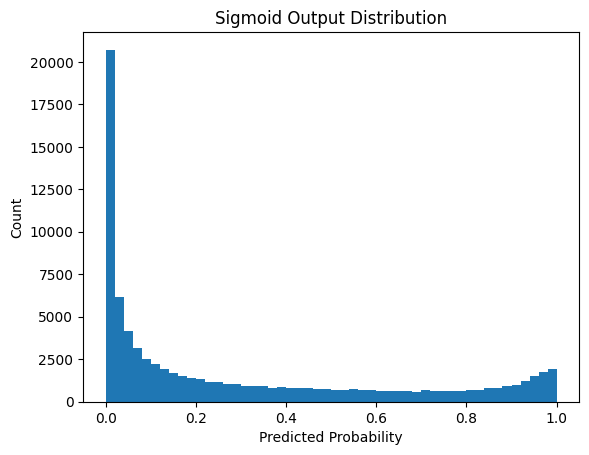

 96%|█████████▌| 96/100 [07:00<00:17,  4.34s/it]

[Eval] Avg loss=0.4040 | F1_micro=0.4441 | Best_F1=0.4441 @ thr=0.30 | Avg labels/sample=18.23
Round 96/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.4441 | Best_F1: 0.4441 (thr=0.30)
[Eval Debug] Logit range: -16.80 to 14.34 | Sigmoid mean=0.290, std=0.329


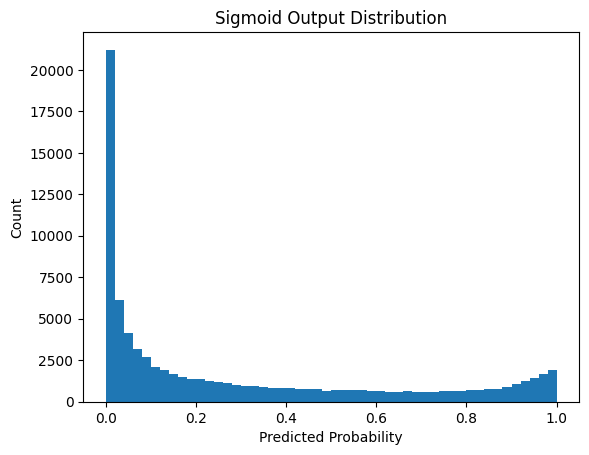

[Eval] Avg loss=0.3974 | F1_micro=0.4484 | Best_F1=0.4484 @ thr=0.30 | Avg labels/sample=17.95


 97%|█████████▋| 97/100 [07:04<00:13,  4.36s/it]

Round 97/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.4484 | Best_F1: 0.4484 (thr=0.30)
[Eval Debug] Logit range: -16.52 to 14.45 | Sigmoid mean=0.286, std=0.328


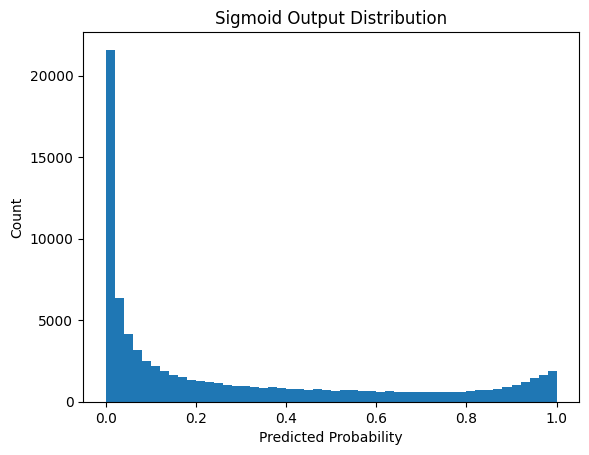

[Eval] Avg loss=0.3899 | F1_micro=0.4506 | Best_F1=0.4506 @ thr=0.30 | Avg labels/sample=17.77


 98%|█████████▊| 98/100 [07:09<00:08,  4.41s/it]

Round 98/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.4506 | Best_F1: 0.4506 (thr=0.30)
[Eval Debug] Logit range: -15.58 to 13.95 | Sigmoid mean=0.287, std=0.329


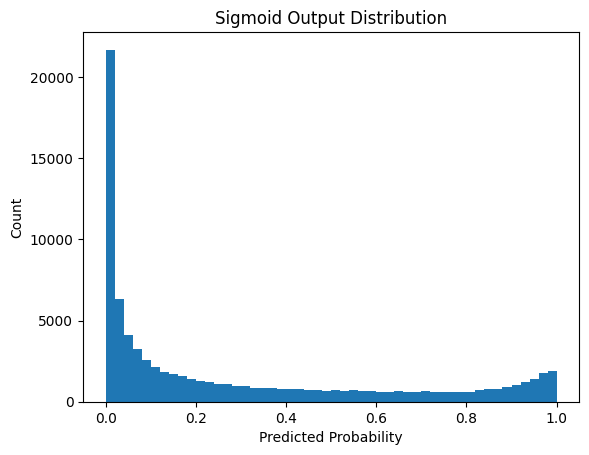

[Eval] Avg loss=0.3915 | F1_micro=0.4522 | Best_F1=0.4522 @ thr=0.30 | Avg labels/sample=17.72


 99%|█████████▉| 99/100 [07:13<00:04,  4.44s/it]

Round 99/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.4522 | Best_F1: 0.4522 (thr=0.30)
[Eval Debug] Logit range: -15.25 to 12.36 | Sigmoid mean=0.288, std=0.329


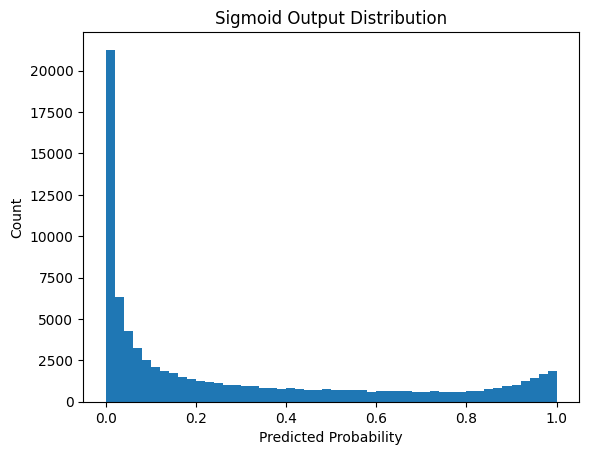

100%|██████████| 100/100 [07:18<00:00,  4.38s/it]

[Eval] Avg loss=0.3929 | F1_micro=0.4503 | Best_F1=0.4503 @ thr=0.30 | Avg labels/sample=17.83
Round 100/100 | Avg Local Loss: 0.8336 | Global Val Loss: 0.4221 | F1_micro: 0.4503 | Best_F1: 0.4503 (thr=0.30)
Centralized training complete!


Best threshold on validation set: 0.3 (F1=0.4503)


In [27]:
# Centralized Training Loop

# ---- Initialize optimizer and loss ----
optimizer = torch.optim.Adam(central_model.parameters(), lr=central_config["lr"], betas=(0.9, 0.99))
loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# ---- Centralized training loop ----
central_config["rounds"] = 100
target_evals = 100
eval_interval = max(1, round(central_config["rounds"] / target_evals))

for rnd in tqdm(range(central_config["rounds"]), colour="green"):
    central_model.train()
    total_loss = 0.0

    # ---- Training phase ----
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        preds, _ = central_model(X_batch)
        loss = loss_fn(preds, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)
    central_history["train_loss"].append(avg_train_loss)

    # ---- Evaluation + saving ----
    if (rnd + 1) % eval_interval == 0 or rnd == central_config["rounds"] - 1:
        # Evaluate model
        val_loss, metrics = eval_model(central_model, device, val_loader)
        central_history["val_loss"].append(val_loss)
        central_history["metrics"].append(metrics)

        # Save checkpoints and logs
        save_json(central_history, "../History/logs/central_metric_history.json")
        torch.save(central_model.state_dict(), "../History/logs/latest_central_model.pt")

        # Track best-performing centralized models
        if metrics["auc_macro"] > cent_max_auc_macro:
            cent_max_auc_macro = metrics["auc_macro"]
            torch.save(central_model.state_dict(), "../History/logs/max_central_auc.pt")

        if metrics["f1_micro"] > cent_max_f1_micro:
            cent_max_f1_micro = metrics["f1_micro"]
            torch.save(central_model.state_dict(), "../History/logs/max_central_f1.pt")

        # Print progress
        print(f"Round {rnd+1}/{config['rounds']} | "
            f"Avg Local Loss: {avg_local_loss:.4f} | "
            f"Global Val Loss: {g_loss:.4f} | "
            f"F1_micro: {metrics['f1_micro']:.4f} | "
            f"Best_F1: {metrics['best_f1_micro']:.4f} (thr={metrics['best_thr']:.2f})")

print("Centralized training complete!")

best_f1, best_thr = find_best_threshold(central_model, val_loader, device)
print(f"Best threshold on validation set: {best_thr} (F1={best_f1:.4f})")


### Centralized Training Results Visualization

Plots below mirror the federated section for one-to-one comparison:
1. Training & validation loss  
2. Validation metrics overview  
3. F1 score trends  
4. AUC trends


In [28]:
# Load centralized history

central_history = load_json(filepath="../History/logs/central_metric_history.json")
print(f"Total Rounds Logged: {len(central_history['val_loss'])}")

Total Rounds Logged: 100


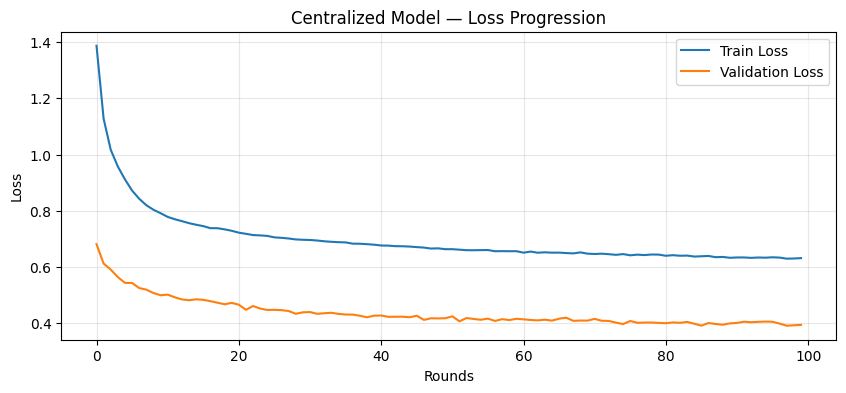

In [29]:
# Train and validation loss

plt.figure(figsize=(10, 4))
plt.plot(central_history["train_loss"], label="Train Loss")
plt.plot(central_history["val_loss"], label="Validation Loss")
plt.title("Centralized Model — Loss Progression")
plt.xlabel("Rounds")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [30]:
for X_batch, y_batch in train_loader:
    print("Pred shape:", model(X_batch)[0].shape)
    print("Label shape:", y_batch.shape)
    print("Unique label values:", torch.unique(y_batch))
    break


Pred shape: torch.Size([32, 50])
Label shape: torch.Size([32, 50])
Unique label values: tensor([0., 1.], dtype=torch.float64)


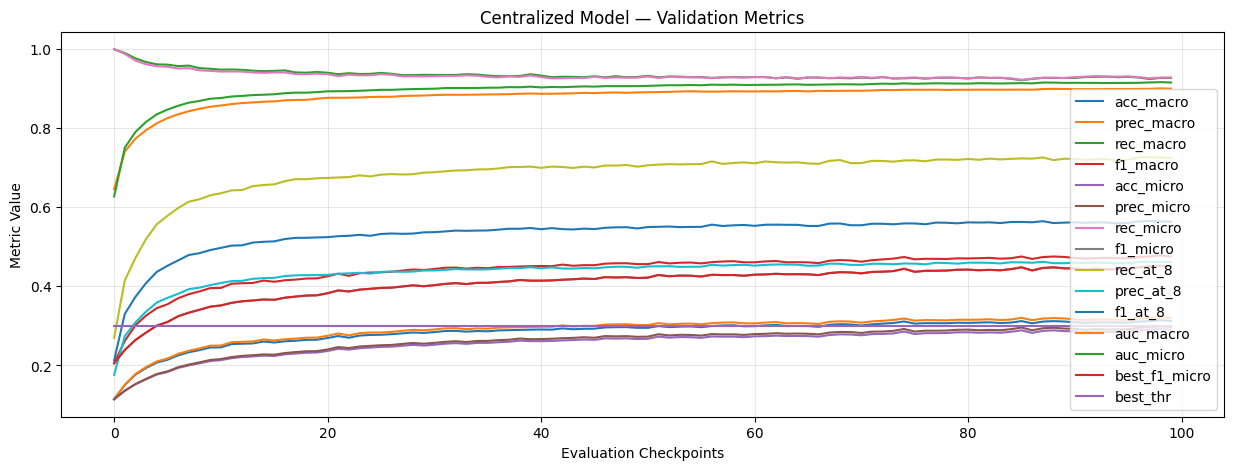

In [31]:
# Validaton Metrics Overview

plt.figure(figsize=(15, 5))
plt.title("Centralized Model — Validation Metrics")

for key in central_history["metrics"][0].keys():
    plt.plot([v[key] for v in central_history["metrics"]], label=key)

plt.xlabel("Evaluation Checkpoints")
plt.ylabel("Metric Value")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

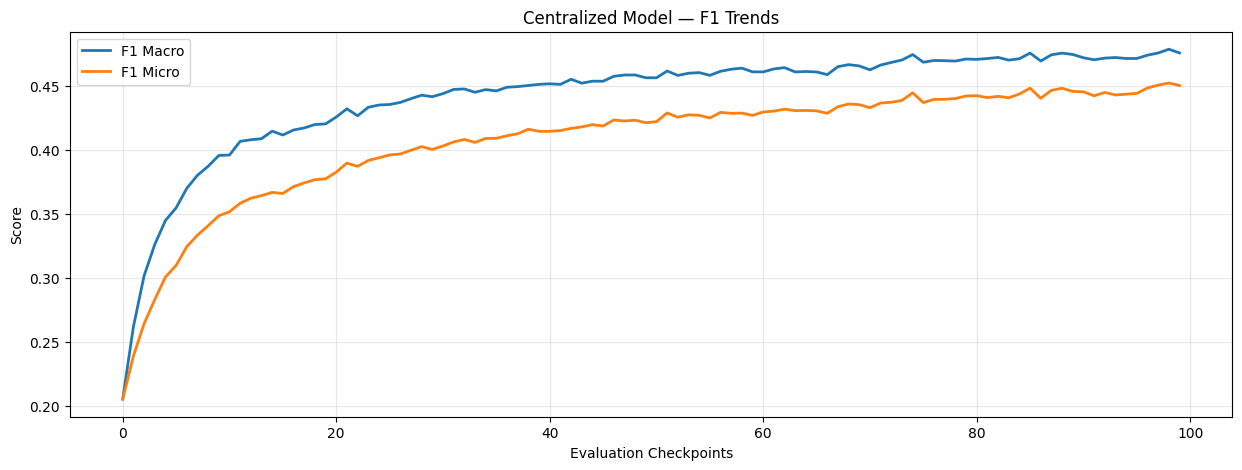

In [32]:
# F1 Score Trends

plt.figure(figsize=(15, 5))
plt.title("Centralized Model — F1 Trends")
plt.plot([v["f1_macro"] for v in central_history["metrics"]], label="F1 Macro", linewidth=2)
plt.plot([v["f1_micro"] for v in central_history["metrics"]], label="F1 Micro", linewidth=2)
plt.xlabel("Evaluation Checkpoints")
plt.ylabel("Score")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

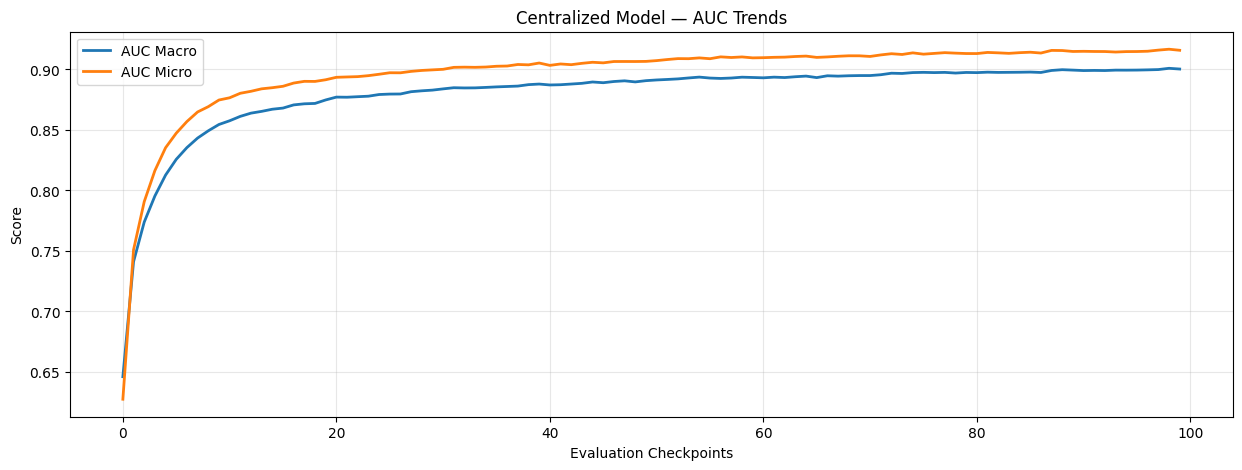

In [33]:
# AUC trends

plt.figure(figsize=(15, 5))
plt.title("Centralized Model — AUC Trends")
plt.plot([v["auc_macro"] for v in central_history["metrics"]], label="AUC Macro", linewidth=2)
plt.plot([v["auc_micro"] for v in central_history["metrics"]], label="AUC Micro", linewidth=2)
plt.xlabel("Evaluation Checkpoints")
plt.ylabel("Score")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Federated vs Centralized Comparison

This section compares the **Federated Learning (FL)** and **Centralized Training (CL)** experiments:

- Overlayed loss curves
- Validation metric trends
- Best-performing metrics summary (F1, AUC, etc.)

The goal is to analyze the trade-offs between distributed vs. centralized optimization.


In [34]:
# Load Both Training Histories

fed_history = load_json(filepath="../History/logs/metric_history.json")
central_history = load_json(filepath="../History/logs/central_metric_history.json")

print(f"FL rounds logged: {len(fed_history['global_loss'])}")
print(f"CL rounds logged: {len(central_history['val_loss'])}")


FL rounds logged: 100
CL rounds logged: 100


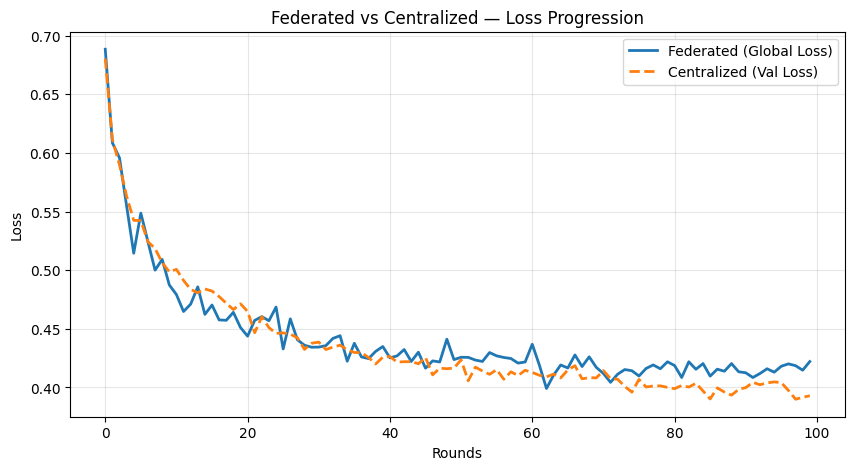

In [35]:
# FL vs Certralized - Loss Comparison

plt.figure(figsize=(10, 5))
plt.plot(fed_history["global_loss"], label="Federated (Global Loss)", linewidth=2)
plt.plot(central_history["val_loss"], label="Centralized (Val Loss)", linewidth=2, linestyle="--")
plt.title("Federated vs Centralized — Loss Progression")
plt.xlabel("Rounds")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


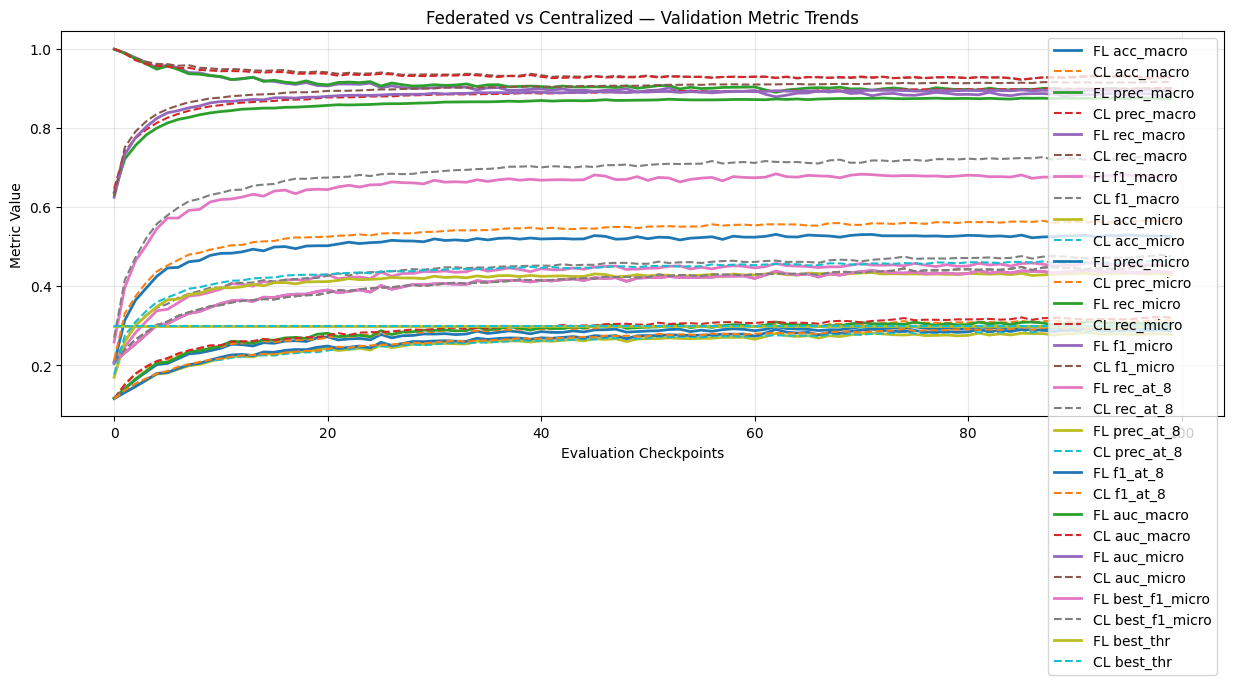

In [36]:

# Federated vs Centralized — Validation Metric Trends

plt.figure(figsize=(15, 5))
plt.title("Federated vs Centralized — Validation Metric Trends")

fed_keys = fed_history["global_metrics"][0].keys()
cent_keys = central_history["metrics"][0].keys()

# Only plot overlapping metrics
shared_metrics = [k for k in fed_keys if k in cent_keys]

for key in shared_metrics:
    plt.plot([m[key] for m in fed_history["global_metrics"]],
             label=f"FL {key}", linewidth=2)
    plt.plot([m[key] for m in central_history["metrics"]],
             label=f"CL {key}", linestyle="--")

plt.xlabel("Evaluation Checkpoints")
plt.ylabel("Metric Value")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


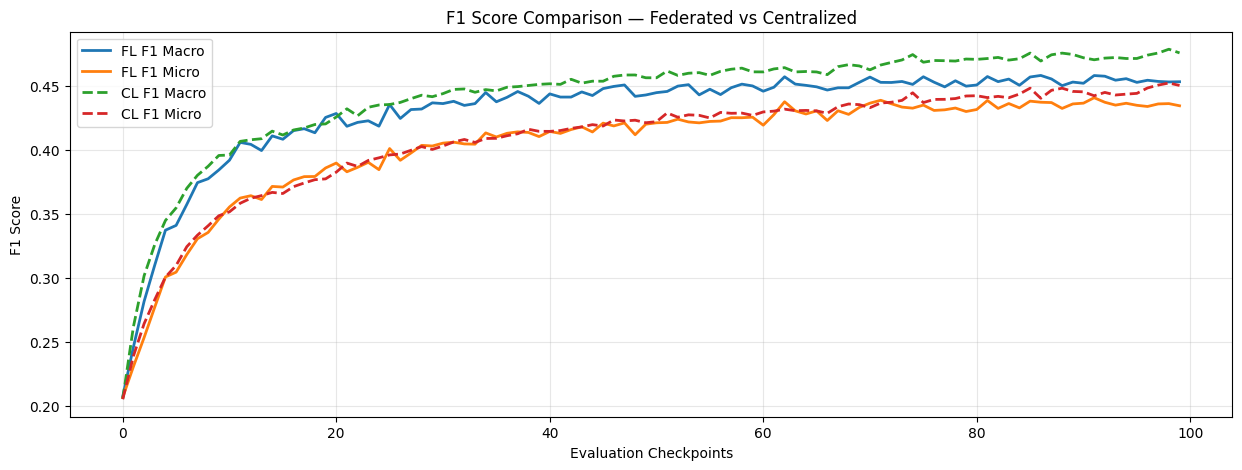

In [37]:
# F1 Comparison (Macro & Micro)

plt.figure(figsize=(15, 5))
plt.title("F1 Score Comparison — Federated vs Centralized")

plt.plot([v["f1_macro"] for v in fed_history["global_metrics"]], label="FL F1 Macro", linewidth=2)
plt.plot([v["f1_micro"] for v in fed_history["global_metrics"]], label="FL F1 Micro", linewidth=2)
plt.plot([v["f1_macro"] for v in central_history["metrics"]], label="CL F1 Macro", linestyle="--", linewidth=2)
plt.plot([v["f1_micro"] for v in central_history["metrics"]], label="CL F1 Micro", linestyle="--", linewidth=2)

plt.xlabel("Evaluation Checkpoints")
plt.ylabel("F1 Score")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

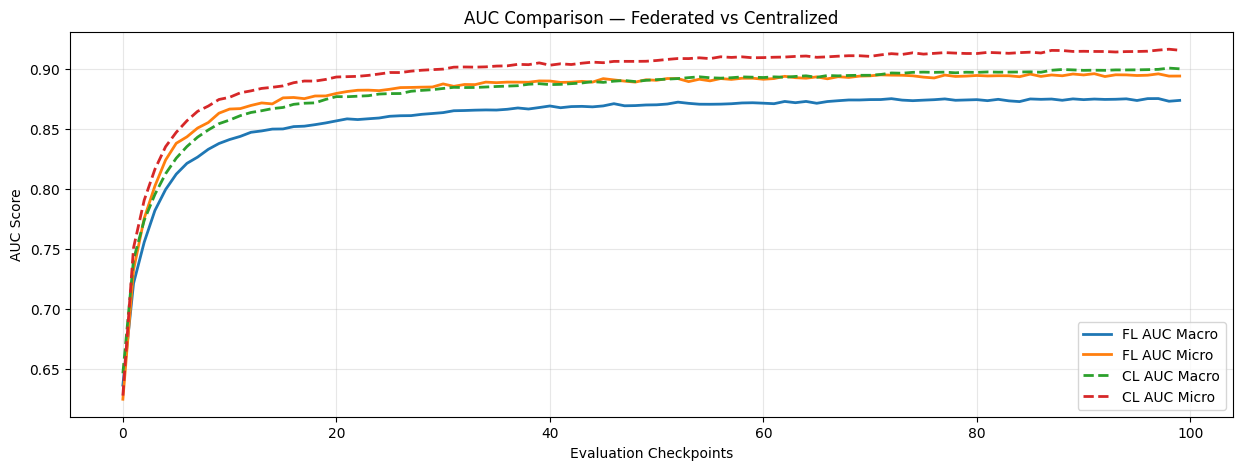

In [38]:
# AUC Comparison (Macro & Micro)

plt.figure(figsize=(15, 5))
plt.title("AUC Comparison — Federated vs Centralized")

plt.plot([v["auc_macro"] for v in fed_history["global_metrics"]], label="FL AUC Macro", linewidth=2)
plt.plot([v["auc_micro"] for v in fed_history["global_metrics"]], label="FL AUC Micro", linewidth=2)
plt.plot([v["auc_macro"] for v in central_history["metrics"]], label="CL AUC Macro", linestyle="--", linewidth=2)
plt.plot([v["auc_micro"] for v in central_history["metrics"]], label="CL AUC Micro", linestyle="--", linewidth=2)

plt.xlabel("Evaluation Checkpoints")
plt.ylabel("AUC Score")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [39]:
# Quantitative Comparison — Best Scores

fed_best_f1 = max([m["f1_micro"] for m in fed_history["global_metrics"]])
fed_best_auc = max([m["auc_macro"] for m in fed_history["global_metrics"]])

cent_best_f1 = max([m["f1_micro"] for m in central_history["metrics"]])
cent_best_auc = max([m["auc_macro"] for m in central_history["metrics"]])

print("Federated vs Centralized Results Summary")
print(f"Federated  → Best F1 (micro): {fed_best_f1:.4f} | Best AUC (macro): {fed_best_auc:.4f}")
print(f"Centralized → Best F1 (micro): {cent_best_f1:.4f} | Best AUC (macro): {cent_best_auc:.4f}")


Federated vs Centralized Results Summary
Federated  → Best F1 (micro): 0.4407 | Best AUC (macro): 0.8755
Centralized → Best F1 (micro): 0.4522 | Best AUC (macro): 0.9009


In [40]:
print(history["global_metrics"][-3:])
print(central_history["metrics"][-3:])

[{'acc_macro': 0.29427777224394586, 'prec_macro': 0.3046486441673031, 'rec_macro': 0.8862885248336646, 'f1_macro': 0.45343550350034567, 'acc_micro': 0.27868300565580395, 'prec_micro': 0.2876602842547868, 'rec_micro': 0.8992938620315046, 'f1_micro': 0.4358906850613449, 'rec_at_8': 0.6784086981016342, 'prec_at_8': 0.43033168009919404, 'f1_at_8': 0.5266169801116477, 'auc_macro': 0.8755020647465355, 'auc_micro': 0.8961413787376432, 'best_f1_micro': 0.4358906850613449, 'best_thr': 0.3}, {'acc_macro': 0.2942757218768757, 'prec_macro': 0.305036156352199, 'rec_macro': 0.8800347676329477, 'f1_macro': 0.453040265425362, 'acc_micro': 0.27888297692073066, 'prec_micro': 0.2884231187129789, 'rec_micro': 0.8939706681151548, 'f1_micro': 0.43613525545897824, 'rec_at_8': 0.6758144965959185, 'prec_at_8': 0.43126162430254183, 'f1_at_8': 0.5265272225231062, 'auc_macro': 0.8732599549718756, 'auc_micro': 0.8942561051262392, 'best_f1_micro': 0.43613525545897824, 'best_thr': 0.3}, {'acc_macro': 0.2940348616968

[Eval Debug] Logit range: -15.25 to 12.36 | Sigmoid mean=0.288, std=0.329


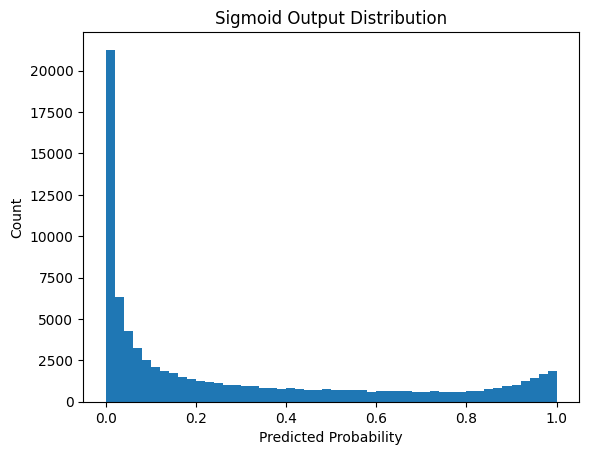

[Eval] Avg loss=0.3929 | F1_micro=0.4503 | Best_F1=0.4503 @ thr=0.30 | Avg labels/sample=17.83


In [ ]:
val_loss, metrics = eval_model(central_model, device, val_loader, tune_threshold=False, fixed_thr=0.3, sigmoid=True)
